---
# Converter test

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from calinet.logger import init_logging
init_logging()

<RootLogger root (INFO)>

In [3]:
import logging
logger = logging.getLogger(__name__)

In [4]:
import os
import re
import bioread
import numpy as np
import pandas as pd
from pathlib import Path
from calinet.imports import biopac
from lazyfmri import plotting

## Austin tests

In [23]:
from calinet.utils import find_sub_dirs
raw_data_dir = "Z:\\CALINET2\\sourcedata\\austin"

subject_dirs = find_sub_dirs(raw_data_dir)
raw_dir = subject_dirs[10]
raw_dir

'Z:\\CALINET2\\sourcedata\\austin\\data\\sub-CALINET013'

### Check TTLs

In [24]:
from calinet.sites.austin import find_physio_acq_file, read_raw_physio_file

dfs = []
for raw_dir in subject_dirs:
    scr_files = find_physio_acq_file(raw_dir, os.path.basename(raw_dir))
    physio_df, sr, chan_info = read_raw_physio_file(scr_files)

    ttl_var = float(np.var(physio_df["TTL"].to_numpy()))
    physio_df["subject"] = os.path.basename(raw_dir)
    dfs.append(physio_df)
    if ttl_var<5:
        logger.error(f"{os.path.basename(raw_dir)}: TTL variance {round(ttl_var, 2)}< 5, this may indicate an empty channel")

physio_df = pd.concat(dfs)

[2026-03-16 11:27:49] [INFO] calinet.sites.austin - Found 2 files:
[2026-03-16 11:27:49] [INFO] calinet.sites.austin -  Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET001\sub-CALINET001_ses-1_task-acq_scr.acq
[2026-03-16 11:27:49] [INFO] calinet.sites.austin -  Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET001\sub-CALINET001_ses-1_task-ext_scr.acq
[2026-03-16 11:27:49] [INFO] calinet.sites.austin - Reading .acq files
[2026-03-16 11:27:49] [INFO] calinet.sites.austin - Loading Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET001\sub-CALINET001_ses-1_task-acq_scr.acq
[2026-03-16 11:27:49] [INFO] calinet.imports.biopac - Idx=-1, assuming last channel (=3)
[2026-03-16 11:27:49] [INFO] calinet.sites.austin - Loading Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET001\sub-CALINET001_ses-1_task-ext_scr.acq
[2026-03-16 11:27:49] [INFO] calinet.imports.biopac - Idx=-1, assuming last channel (=3)
[2026-03-16 11:27:49] [INFO] calinet.sites.austin 

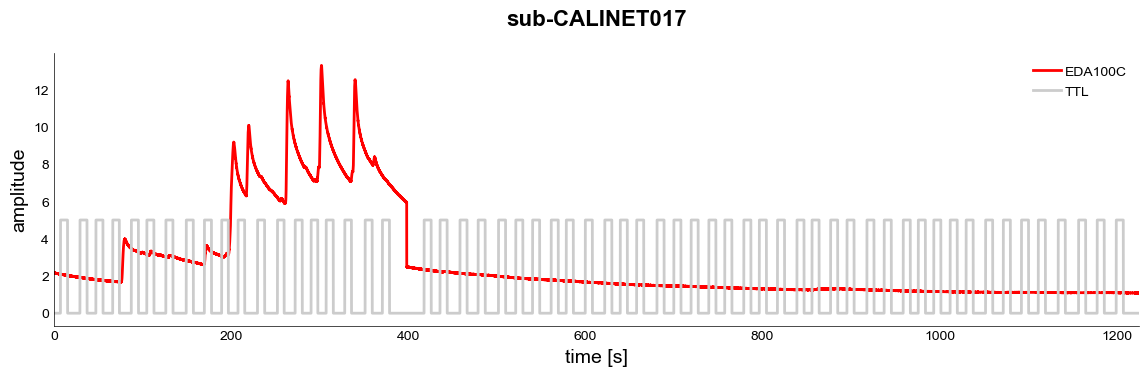

In [26]:
plot_sub = "sub-CALINET017"
df = physio_df.loc[physio_df["subject"] == plot_sub].copy()
pl = plotting.LazyLine(
    [df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, df.shape[0])/sr,
    line_width=2,
    color=["r", "#cccccc"],
    fontname="Arial",
    figsize=(14, 3.54),
    x_label="time [s]",
    y_label="amplitude",
    labels=["EDA100C", "TTL"],
    title={
        "title": plot_sub,
        "fontweight": "bold"
    }
)

### Physio

Dunsmoor lab has acq-files split for task; so we need to combine for convenience

In [27]:
subject = "017"
raw_dir = [p for i, p in enumerate(subject_dirs) if Path(p).name == f"sub-CALINET{subject}"][0]

raw_dir

'Z:\\CALINET2\\sourcedata\\austin\\data\\sub-CALINET017'

In [28]:
from calinet.sites.austin import find_physio_acq_file
subj = os.path.basename(raw_dir)
scr_files = find_physio_acq_file(raw_dir, subj)
scr_files

[2026-03-16 11:33:53] [INFO] calinet.sites.austin - Found 2 files:
[2026-03-16 11:33:53] [INFO] calinet.sites.austin -  Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET017\sub-CALINET017_ses-1_task-acq_scr.acq
[2026-03-16 11:33:53] [INFO] calinet.sites.austin -  Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET017\sub-CALINET017_ses-1_task-ext_scr.acq


['Z:\\CALINET2\\sourcedata\\austin\\data\\scr\\processed\\sub-CALINET017\\sub-CALINET017_ses-1_task-acq_scr.acq',
 'Z:\\CALINET2\\sourcedata\\austin\\data\\scr\\processed\\sub-CALINET017\\sub-CALINET017_ses-1_task-ext_scr.acq']

In [29]:
biopac_file = scr_files[0]
assert os.path.exists(biopac_file)

bio = bioread.read_file(biopac_file)
bio.channels

[Channel CH3 + 10: 79665 samples, 200.0 samples/sec, loaded: True,
 Channel EDA100C: 79665 samples, 200.0 samples/sec, loaded: True,
 Channel Digital input: 79665 samples, 200.0 samples/sec, loaded: True,
 Channel Digital input: 79665 samples, 200.0 samples/sec, loaded: True]

In [36]:
res = biopac.read_acq_file(
    biopac_file,
    channels={
        "SCR": re.compile(r"EDA100C", re.I),
        "TTL": -1
    }
)

from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz,
    # min_off_ms=4000
)


[2026-03-16 11:35:32] [INFO] calinet.imports.biopac - Idx=-1, assuming last channel (=3)
[2026-03-16 11:35:32] [INFO] calinet.core.events - Extracting marker data [sr=200.0]
[2026-03-16 11:35:32] [INFO] calinet.core.events - typical_ioi≈19.750s | min_rise_interval_sec=9.875s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-16 11:35:32] [INFO] calinet.core.events - Largest gap between markers: 23.000s (between markers 6 and 7)
[2026-03-16 11:35:32] [INFO] calinet.core.events - Long gap threshold=98.75s (19.75*5.0)
[2026-03-16 11:35:32] [INFO] calinet.core.events - 19 markers found in a single cluster. No long gaps.


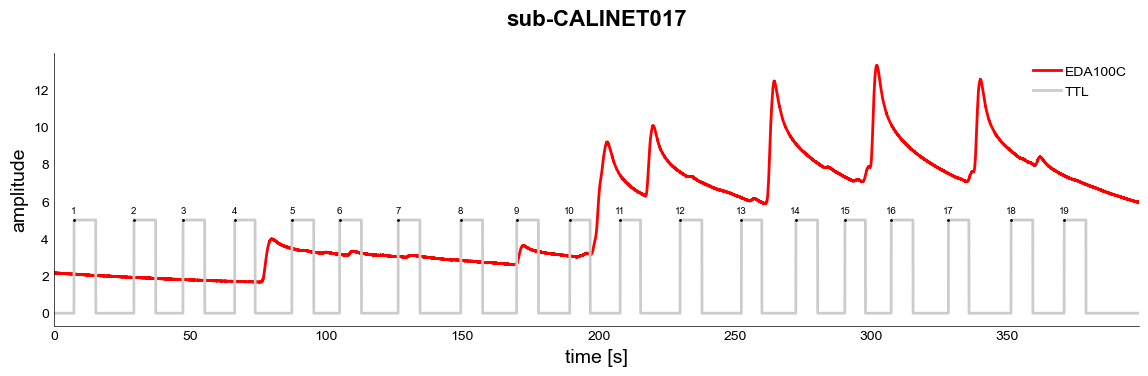

In [38]:
pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    color=["r", "#cccccc"],
    fontname="Arial",
    figsize=(14, 3.54),
    x_label="time [s]",
    y_label="amplitude",
    labels=["EDA100C", "TTL"],
    title={
        "title": plot_sub,
        "fontweight": "bold"
    }
)

for idx, i in enumerate(out, start=1):
    # marker
    pl.axs.plot(i, 5, marker=".", markersize=2,
                markerfacecolor="k", markeredgecolor="k")
    
    # number above marker
    pl.axs.text(
        i, 5.25, str(idx),           # slightly above the marker
        ha="center",
        va="bottom",
        fontsize=pl.label_size*0.7,
        color="k"
    )

In [9]:
# test combination
from calinet.sites.austin import read_raw_physio_file
physio_df, sr, chan_info = read_raw_physio_file(scr_files)

[2026-03-16 09:19:22] [INFO] calinet.sites.austin - Reading .acq files
[2026-03-16 09:19:22] [INFO] calinet.sites.austin - Loading Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET001\sub-CALINET001_ses-1_task-acq_scr.acq
[2026-03-16 09:19:22] [INFO] calinet.sites.austin - Loading Z:\CALINET2\sourcedata\austin\data\scr\processed\sub-CALINET001\sub-CALINET001_ses-1_task-ext_scr.acq
[2026-03-16 09:19:22] [INFO] calinet.sites.austin - Combining data from acq-files


In [12]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    physio_df,
    res.sampling_rate_hz,
    gap_factor=3
    # min_off_ms=4000
)

[2026-03-16 09:21:12] [INFO] calinet.core.events - Extracting marker data [sr=200.0]
[2026-03-16 09:21:12] [INFO] calinet.core.events - typical_ioi≈19.500s | min_rise_interval_sec=9.750s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-16 09:21:12] [INFO] calinet.core.events - Largest gap between markers: 66.140s (between markers 19 and 20)
[2026-03-16 09:21:12] [INFO] calinet.core.events - Long gap threshold=58.5s (19.5*3)
[2026-03-16 09:21:12] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-16 09:21:12] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-16 09:21:12] [INFO] calinet.core.events - Marker data successfully extracted


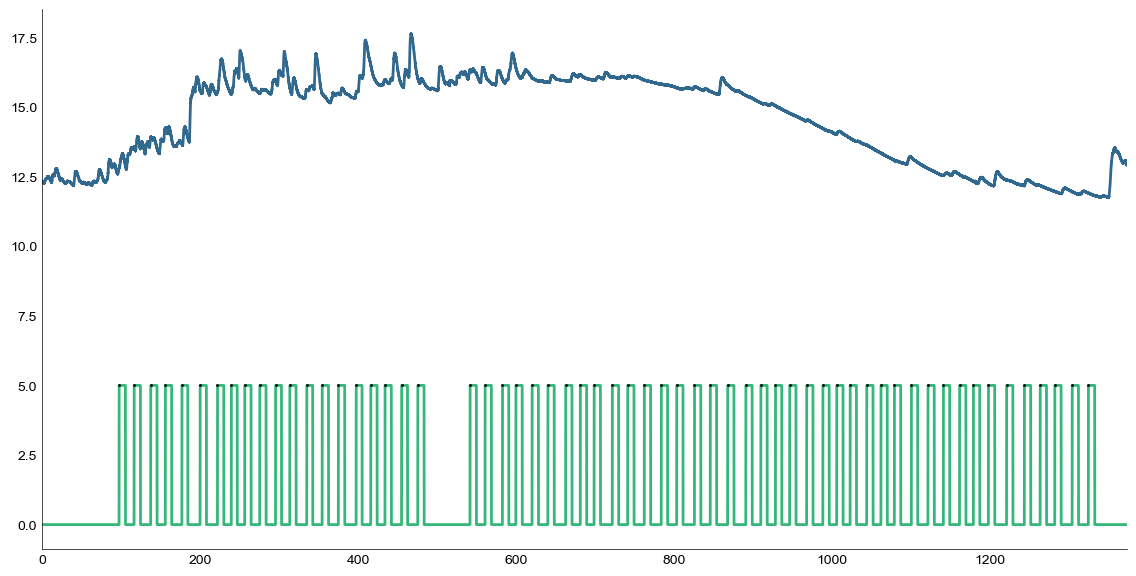

In [13]:
pl = plotting.LazyLine(
    [physio_df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, physio_df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 7.01)
)

for i in out:
    pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

### Phenotype

In [89]:
from calinet.sites.austin import parse_questionnaire_file, find_questionnaire_file

questionnaire_file = find_questionnaire_file(r'Z:\CALINET2\sourcedata\austin')

info_df, pheno_df = parse_questionnaire_file(questionnaire_file)

In [90]:
pheno_df.head()

,participant_id,redcap_event_name,redcap_survey_identifier,experiment_id,visit_date,cs_order,test_order,research_id_complete,recorded_at,age,...,dass21_13,dass21_14,dass21_15,dass21_16,dass21_17,dass21_18,dass21_19,dass21_20,dass21_21,dass21_complete
0,sub-001,info_arm_1,NaN,CALINET001,2025-03-20,1.0,1.0,2.0,2025-03-20 12:09:21,26.0,...,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0
1,sub-002,info_arm_1,NaN,CALINET002,2025-03-25,1.0,2.0,2.0,2025-03-25 10:07:00,48.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
2,sub-003,info_arm_1,NaN,CALINET003,2025-03-25,1.0,3.0,2.0,2025-03-25 13:17:14,29.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
3,sub-004,info_arm_1,NaN,CALINET004,2025-03-25,1.0,4.0,2.0,2025-03-25 15:40:55,19.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
4,sub-005,info_arm_1,NaN,CALINET005,2025-03-26,2.0,1.0,2.0,2025-03-26 08:13:13,31.0,...,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0


In [41]:
questionnaire_file = "Z:\\CALINET2\\sourcedata\\austin\\CALINET2_DATA_2026-03-03_1107.csv"
pheno_df = pd.read_csv(questionnaire_file, delimiter=",")

pheno_df = (
    pheno_df
    .groupby("record_id", as_index=False)
    .first()
)

pheno_df.columns = pheno_df.columns.str.strip().str.lower()
pheno_df.head()

,record_id,redcap_event_name,redcap_survey_identifier,experiment_id,visit_date,cs_order,test_order,research_id_complete,demographics_form_timestamp,age_213e53,...,dass21_13,dass21_14,dass21_15,dass21_16,dass21_17,dass21_18,dass21_19,dass21_20,dass21_21,dass21_complete
0,CALINET001,info_arm_1,NaN,CALINET001,2025-03-20,1.0,1.0,2.0,2025-03-20 12:09:21,26.0,...,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0
1,CALINET002,info_arm_1,NaN,CALINET002,2025-03-25,1.0,2.0,2.0,2025-03-25 10:07:00,48.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
2,CALINET003,info_arm_1,NaN,CALINET003,2025-03-25,1.0,3.0,2.0,2025-03-25 13:17:14,29.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
3,CALINET004,info_arm_1,NaN,CALINET004,2025-03-25,1.0,4.0,2.0,2025-03-25 15:40:55,19.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
4,CALINET005,info_arm_1,NaN,CALINET005,2025-03-26,2.0,1.0,2.0,2025-03-26 08:13:13,31.0,...,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0


In [50]:
from calinet.sites.austin import parse_questionnaire_file
info_df, pheno_df = parse_questionnaire_file(questionnaire_file)
pheno_df.head()


,participant_id,redcap_event_name,redcap_survey_identifier,experiment_id,visit_date,cs_order,test_order,research_id_complete,recorded_at,age,...,dass21_13,dass21_14,dass21_15,dass21_16,dass21_17,dass21_18,dass21_19,dass21_20,dass21_21,dass21_complete
0,sub-001,info_arm_1,NaN,CALINET001,2025-03-20,1.0,1.0,2.0,2025-03-20 12:09:21,26.0,...,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0
1,sub-002,info_arm_1,NaN,CALINET002,2025-03-25,1.0,2.0,2.0,2025-03-25 10:07:00,48.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
2,sub-003,info_arm_1,NaN,CALINET003,2025-03-25,1.0,3.0,2.0,2025-03-25 13:17:14,29.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
3,sub-004,info_arm_1,NaN,CALINET004,2025-03-25,1.0,4.0,2.0,2025-03-25 15:40:55,19.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
4,sub-005,info_arm_1,NaN,CALINET005,2025-03-26,2.0,1.0,2.0,2025-03-26 08:13:13,31.0,...,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0


In [54]:
from calinet.sites.austin import *
aggr_pheno_data(pheno_df, None)

,participant_id,recorded_at,room_temperature,humidity,age,sex,handedness
0,sub-001,2025-03-20T12:09:21,None,None,26.0,F,None
1,sub-002,2025-03-25T10:07:00,None,None,48.0,M,None
2,sub-003,2025-03-25T13:17:14,None,None,29.0,F,None
3,sub-004,2025-03-25T15:40:55,None,None,19.0,M,None
4,sub-005,2025-03-26T08:13:13,None,None,31.0,F,None
5,sub-006,2025-04-23T09:19:05,None,None,19.0,F,None
6,sub-007,2025-04-23T12:06:47,None,None,20.0,F,None
7,sub-008,2025-05-01T13:44:55,None,None,21.0,NaN,None
8,sub-009,2025-05-14T11:40:45,None,None,23.0,F,None
9,sub-010,2025-05-14T14:02:44,None,None,20.0,M,None


### Full conversion test

[2026-03-16 10:07:32] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\austin\sub-001\physio\sub-001_task-acquisition_recording-scr_physio.json
[2026-03-16 10:07:32] [INFO] calinet.plotting - SamplingFrequency=200.0
[2026-03-16 10:07:32] [INFO] calinet.plotting - Units for 'scr'=uS
[2026-03-16 10:07:32] [INFO] calinet.plotting - Read 'scr'/'acquisition' file: Z:\CALINET2\converted\austin\sub-001\physio\sub-001_task-acquisition_recording-scr_physio.tsv.gz
[2026-03-16 10:07:32] [INFO] calinet.plotting - 'scr' channel index: -1
[2026-03-16 10:07:32] [INFO] calinet.plotting - Add events
[2026-03-16 10:07:32] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\austin\sub-001\physio\sub-001_task-extinction_recording-scr_physio.json
[2026-03-16 10:07:32] [INFO] calinet.plotting - SamplingFrequency=200.0
[2026-03-16 10:07:32] [INFO] calinet.plotting - Units for 'scr'=uS
[2026-03-16 10:07:32] [INFO] calinet.plotting - Read 'scr'/'extinction' fi

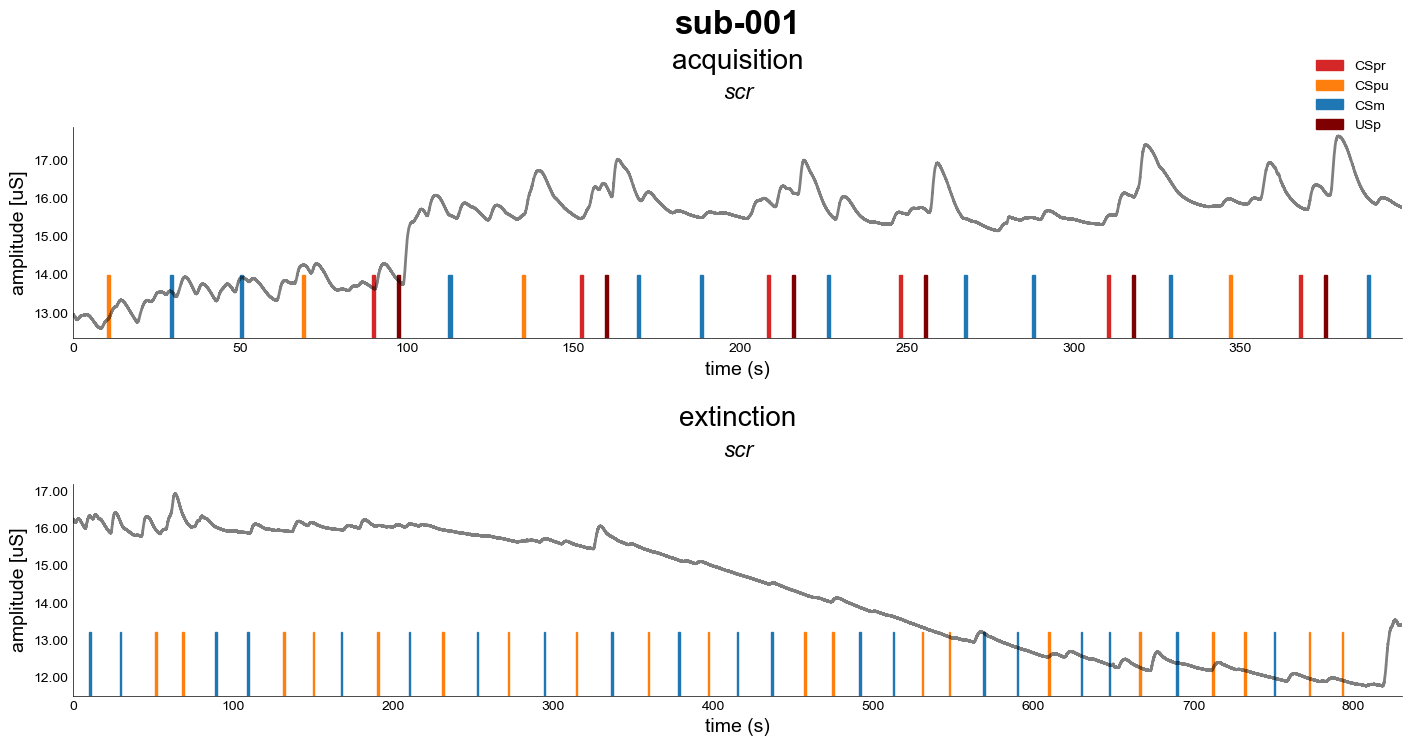

In [45]:
from calinet.plotting import plot_modalities_per_subject

lab_name = "austin"
subject = "sub-001"
f = plot_modalities_per_subject(
    lab_name,
    subject
)

## Bielefeld tests

### Physio

In [467]:
biopac_file = "Z:\\CALINET2\\sourcedata\\bielefeld\\physio\\001.acq"
assert os.path.exists(biopac_file)

In [468]:
bio = bioread.read_file(biopac_file)
bio.channels

[Channel event_marker - Custom, AMI / HLT - A 1: 2014448 samples, 1000.0 samples/sec, loaded: True,
 Channel SCR - EDA100C: 2014448 samples, 1000.0 samples/sec, loaded: True,
 Channel STM200 - STM200 - Reference Out, AMI / : 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 4028896 samples, 2000.0 s

In [477]:
res_bfeld = biopac.read_acq_file(
    biopac_file,
    channels={
        "SCR": re.compile(r"SCR - EDA100C", re.I),
        "TTL": re.compile(r"stim_marker", re.I)
    }
)

res_bfeld.df

,SCR,TTL
0,7.533264,0.0
1,7.534789,0.0
2,7.527160,0.0
3,7.533264,0.0
4,7.533264,0.0
...,...,...
2014443,0.025939,0.0
2014444,0.027465,0.0
2014445,0.022888,0.0
2014446,0.025939,0.0


In [478]:
res_bfeld.selected_channel_info

,index,name,units,samples_per_second,length,output_name
1,1,SCR - EDA100C,microsiemens,1000.0,2014448,SCR
20,20,stim_marker,Volts,1000.0,2014448,TTL


In [7]:
res_bfeld.selected_channel_info.set_index("output_name").at["SCR", "units"]

'microsiemens'

In [17]:
import numpy as np
np.unique(res_bfeld.df["TTL"].values)

array([0., 5.])

In [43]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res_bfeld.df,
    res_bfeld.sampling_rate_hz,
    # min_off_ms=4000
)

[2026-03-04 12:30:35] [INFO] calinet.core.events - Extracting marker data
[2026-03-04 12:30:35] [INFO] calinet.core.events - typical_ioi≈8.750s | min_rise_interval_sec=4.375s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-04 12:30:35] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-04 12:30:35] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-04 12:30:35] [INFO] calinet.core.events - Marker data successfully extracted


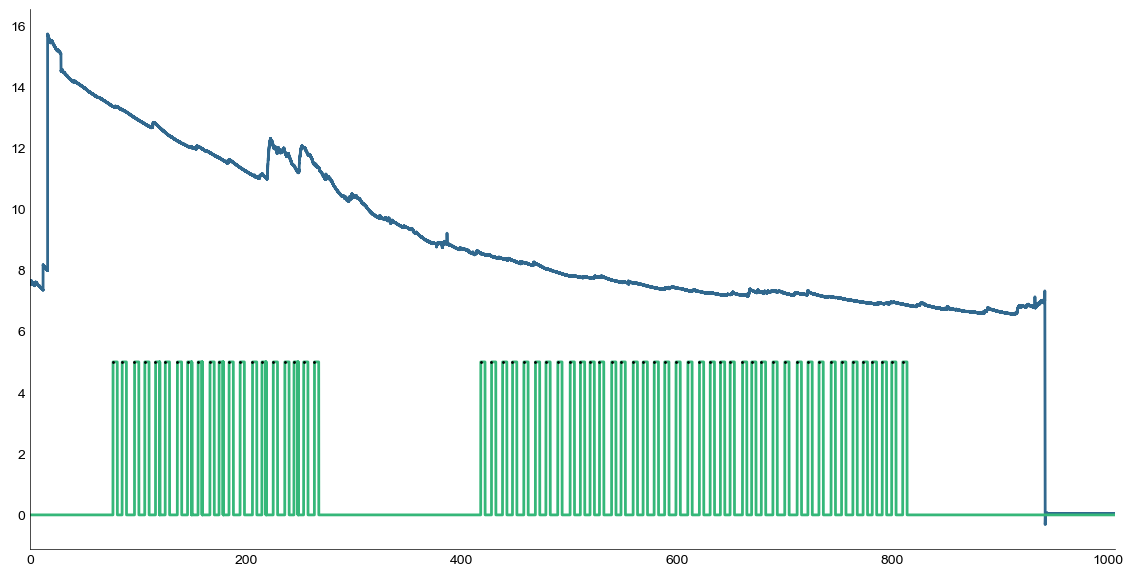

In [44]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res_bfeld.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res_bfeld.df.shape[0])/res_bfeld.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 7.01)
)

for i in out:
    pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

In [9]:
biopac_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-001\\CALINET_Template001.acq"
assert os.path.exists(biopac_file)

res_bonn = biopac.read_acq_file(
    biopac_file,
    channels={
        "scr": re.compile(r"(eda|gsr)", re.I),
        "ecg": re.compile(r"(ecg|ekg)", re.I),
        "resp": re.compile(r"(rsp|resp)", re.I),
        "ttl": re.compile(r"STP Input 0", re.I),
    }
)

res_bonn.df

,scr,ecg,resp,ttl
0,4.795837,1.125946,0.219727,0.0
1,4.795837,1.120148,0.219116,0.0
2,4.795837,1.114197,0.218506,0.0
3,4.794311,1.108551,0.217590,0.0
4,4.794311,1.102753,0.217285,0.0
...,...,...,...,...
6412780,0.035095,0.085449,0.056152,0.0
6412781,0.035095,0.085907,0.055847,0.0
6412782,0.039673,0.086212,0.055847,0.0
6412783,0.036621,0.086517,0.055542,0.0


In [10]:
from calinet.config import available_labs, import_modules
import_modules

{'amsterdam': 'calinet.sites.amsterdam',
 'austin': 'calinet.sites.austin',
 'bielefeld': 'calinet.sites.bielefeld',
 'bologna': 'calinet.sites.bologna',
 'bonn': 'calinet.sites.bonn',
 'leuven': 'calinet.sites.leuven',
 'newyork': 'calinet.sites.newyork',
 'reading': 'calinet.sites.reading',
 'southampton': 'calinet.sites.southampton',
 'stockholm': 'calinet.sites.stockholm',
 'wuerzburg': 'calinet.sites.wuerzburg'}

### Events

In [45]:
import os
from calinet.core.physio import handle_physio
# os.environ["CALINET_DEBUG"] = "1"

subject_raw_data_path = "Z:\\CALINET2\\sourcedata\\bielefeld\\sub-CALINET001"
subject_new_dir = "Z:\\CALINET2\\converted\\test_bids045\\sub-001"
subject_name = os.path.basename(subject_raw_data_path)
lab_name = "bielefeld"


evs = handle_physio(
    subject_raw_data_path,
    subject_new_dir,
    subject_name,
    lab_name
)

[2026-03-04 12:32:38] [INFO] calinet.sites.bielefeld - Physio-folder: Z:\CALINET2\sourcedata\bielefeld\physio
[2026-03-04 12:32:38] [INFO] calinet.sites.bielefeld - Reading .acq file: Z:\CALINET2\sourcedata\bielefeld\physio\001.acq
[2026-03-04 12:32:43] [INFO] calinet.sites.bielefeld - Loading acq-file successfull
[2026-03-04 12:32:43] [INFO] calinet.core.physio - Extracting marker data [SamplingRate=2000.0]
[2026-03-04 12:32:43] [INFO] calinet.core.events - Extracting marker data
[2026-03-04 12:32:43] [INFO] calinet.core.events - typical_ioi≈8.750s | min_rise_interval_sec=4.375s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-04 12:32:43] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-04 12:32:43] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-04 12:32:43] [INFO] calinet.core.events - Marker data successfully extracted
[2026-03-04 12:32:43] [INFO] calinet.core.physio - Find splitting point between acquisition/extinction ses

In [46]:
evs

{'acquisition': [76.6625,
  85.1625,
  96.662,
  106.162,
  116.1615,
  125.1615,
  136.4115,
  145.9115,
  155.661,
  166.661,
  175.161,
  184.4105,
  194.6605,
  206.1605,
  214.91,
  225.41,
  236.16,
  244.6595,
  253.6595,
  263.6595],
 'extinction': [148.185,
  158.185,
  168.435,
  177.6845,
  188.1845,
  198.9345,
  208.68400000000003,
  219.68400000000003,
  231.18400000000003,
  240.68400000000003,
  249.68350000000004,
  258.43350000000004,
  269.68350000000004,
  278.43350000000004,
  289.68300000000005,
  298.93300000000005,
  309.18300000000005,
  318.93249999999995,
  329.43249999999995,
  340.43249999999995,
  351.18199999999996,
  361.18199999999996,
  370.68199999999996,
  379.68149999999997,
  391.18149999999997,
  399.68149999999997,
  408.68149999999997,
  419.431,
  430.431,
  441.931,
  451.9305,
  462.1805,
  473.4305,
  483.18,
  493.68,
  503.18,
  511.6795,
  520.9295,
  529.6795,
  539.9295]}

In [89]:
from calinet.core.events import handle_events
from calinet.templates import EVENTS_JSON_TEMPLATE

task_ratings = handle_events(
    subject_raw_data_path,
    subject_new_dir,
    subject_name,
    evs,
    EVENTS_JSON_TEMPLATE,
)

task_ratings

[2026-03-04 14:21:57] [INFO] calinet.core.events - Processing events data
[2026-03-04 14:21:57] [INFO] calinet.core.events - Parsing events for task='acquisition'
[2026-03-04 14:21:57] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\bielefeld\sub-CALINET001\sub-CALINET001_ses-1_task-acquisition_2025-03-04_16h05.03.128.csv
[2026-03-04 14:21:57] [INFO] calinet.core.events - Adding 6 US trials to events
[2026-03-04 14:21:57] [INFO] calinet.core.events - Saved acquisition events to Z:\CALINET2\converted\test_bids045\sub-001\physio\sub-CALINET001_task-acquisition_events.tsv
[2026-03-04 14:21:57] [INFO] calinet.core.events - Created events data for sub-CALINET001, task-acquisition
[2026-03-04 14:21:57] [INFO] calinet.core.events - Parsing events for task='extinction'
[2026-03-04 14:21:57] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\bielefeld\sub-CALINET001\sub-CALINET001_ses-1_task-extinction_2025-03-04_16h17.40.107.csv
[2026-03-04 14:21:57

{'pre_acquisition_ratings': [6, 2, 2, 6, 2, 2],
 'post_acquisition_ratings': [6, 4, 3, 6, 3, 3],
 'post_extinction_ratings': [6, 3, 3, 5, 6, 3, 6, 5]}

In [90]:
from calinet.core.events import process_trial_data
import pandas as pd
df = pd.read_csv("Z:\\CALINET2\\converted\\test_bids045\\sub-001\\physio\\sub-CALINET001_task-acquisition_events.tsv", sep="\t")

df

,onset,duration,event_type,stimulus_name,HED,task_name
0,76.6625,8.000000,CSpu,square,"Sensory-event,Visual-presentation,Experimental...",habituation
1,84.1625,0.000000,USo,square,"Experimental-condition/CS-plus,Experimental-co...",habituation
2,85.1625,8.000000,CSm,diamond,"Sensory-event,Visual-presentation,Experimental...",habituation
3,92.6625,0.000000,USm,diamond,"Experimental-condition/CS-minus,Experimental-c...",habituation
4,96.6620,8.000000,CSm,diamond,"Sensory-event,Visual-presentation,Experimental...",habituation
5,104.1620,0.000000,USm,diamond,"Experimental-condition/CS-minus,Experimental-c...",habituation
6,106.1620,8.000000,CSpu,square,"Sensory-event,Visual-presentation,Experimental...",habituation
7,113.6620,0.000000,USo,square,"Experimental-condition/CS-plus,Experimental-co...",habituation
8,116.1615,8.000000,CSpr,square,"Sensory-event,Visual-presentation,Experimental...",acquisition
9,123.6615,0.435527,USp,shock,"Sensory-event,Somatosensory-stimulation,Aversi...",acquisition


In [77]:
us_rows = df.loc[df["us"] == 1.0].copy()
us_rows["duration"] = us_rows["shock_end"]-df["shock_begin"]
us_rows

,event_type,us,stimulus_name,duration,task_name,onset,shock_begin,shock_end,shock_duration
4,CS+,1.0,square,0.435527,acquisition,116.1615,103.016145,103.451672,0.435527
7,CS+,1.0,square,0.437130,acquisition,145.9115,162.516234,162.953365,0.437130
8,CS+,1.0,square,0.437669,acquisition,155.6610,182.016181,182.453850,0.437669
10,CS+,1.0,square,0.437358,acquisition,175.1610,221.015960,221.453318,0.437358
14,CS+,1.0,square,0.433888,acquisition,214.9100,300.516032,300.949920,0.433888
17,CS+,1.0,square,0.435838,acquisition,244.6595,360.015825,360.451663,0.435838


In [93]:
from calinet.templates import (
    PARTICIPANT_INFO_SPEC,
    BFI30_SPEC,
    BFI60_SPEC,
    GAD7_SPEC,
    IUS_SPEC,
    PHQ_SPEC,
    SOC_SPEC,
    STAI20_SPEC,
)

In [94]:
n_bfi = 30
BFI_SPEC = {
    30: BFI30_SPEC,
    60: BFI60_SPEC
}[n_bfi]
BFI_SPEC

{'MeasurementToolMetadata': {'Description': 'The Big Five Inventory-2 German Version',
  'TermURL': 'https://osf.io/k34rf/'},
 'participant_id': {'Description': 'Unique identifier for each participant'},
 'bfi30_1': {'Description': 'Ich gehe aus mir heraus, bin gesellig.',
  'Levels': {'1': '1', '2': '2', '3': '3', '4': '4', '5': '5'}},
 'bfi30_2': {'Description': 'Ich bin einfühlsam, warmherzig.',
  'Levels': {'1': '1', '2': '2', '3': '3', '4': '4', '5': '5'}},
 'bfi30_3_r': {'Description': 'Ich bin eher unordentlich.',
  'Levels': {'1': '1', '2': '2', '3': '3', '4': '4', '5': '5'}},
 'bfi30_4_r': {'Description': 'Ich bleibe auch in stressigen Situationen gelassen.',
  'Levels': {'1': '1', '2': '2', '3': '3', '4': '4', '5': '5'}},
 'bfi30_5_r': {'Description': 'Ich bin nicht sonderlich kunstinteressiert.',
  'Levels': {'1': '1', '2': '2', '3': '3', '4': '4', '5': '5'}},
 'bfi30_6': {'Description': 'Ich bin durchsetzungsfähig, energisch.',
  'Levels': {'1': '1', '2': '2', '3': '3', '4'

[2026-03-11 13:55:16] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\bielefeld\sub-CalinetBielefeld01\physio\sub-CalinetBielefeld01_task-acquisition_recording-scr_physio.json
[2026-03-11 13:55:16] [INFO] calinet.plotting - SamplingFrequency=1000.0
[2026-03-11 13:55:16] [INFO] calinet.plotting - Units for 'scr'=uS
[2026-03-11 13:55:16] [INFO] calinet.plotting - Read 'scr'/'acquisition' file: Z:\CALINET2\converted\bielefeld\sub-CalinetBielefeld01\physio\sub-CalinetBielefeld01_task-acquisition_recording-scr_physio.tsv.gz
[2026-03-11 13:55:16] [INFO] calinet.plotting - 'scr' channel index: -1
[2026-03-11 13:55:16] [INFO] calinet.plotting - Add events
[2026-03-11 13:55:16] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\bielefeld\sub-CalinetBielefeld01\physio\sub-CalinetBielefeld01_task-extinction_recording-scr_physio.json
[2026-03-11 13:55:16] [INFO] calinet.plotting - SamplingFrequency=1000.0
[2026-03-11 13:55:16] [INFO] calinet.plo

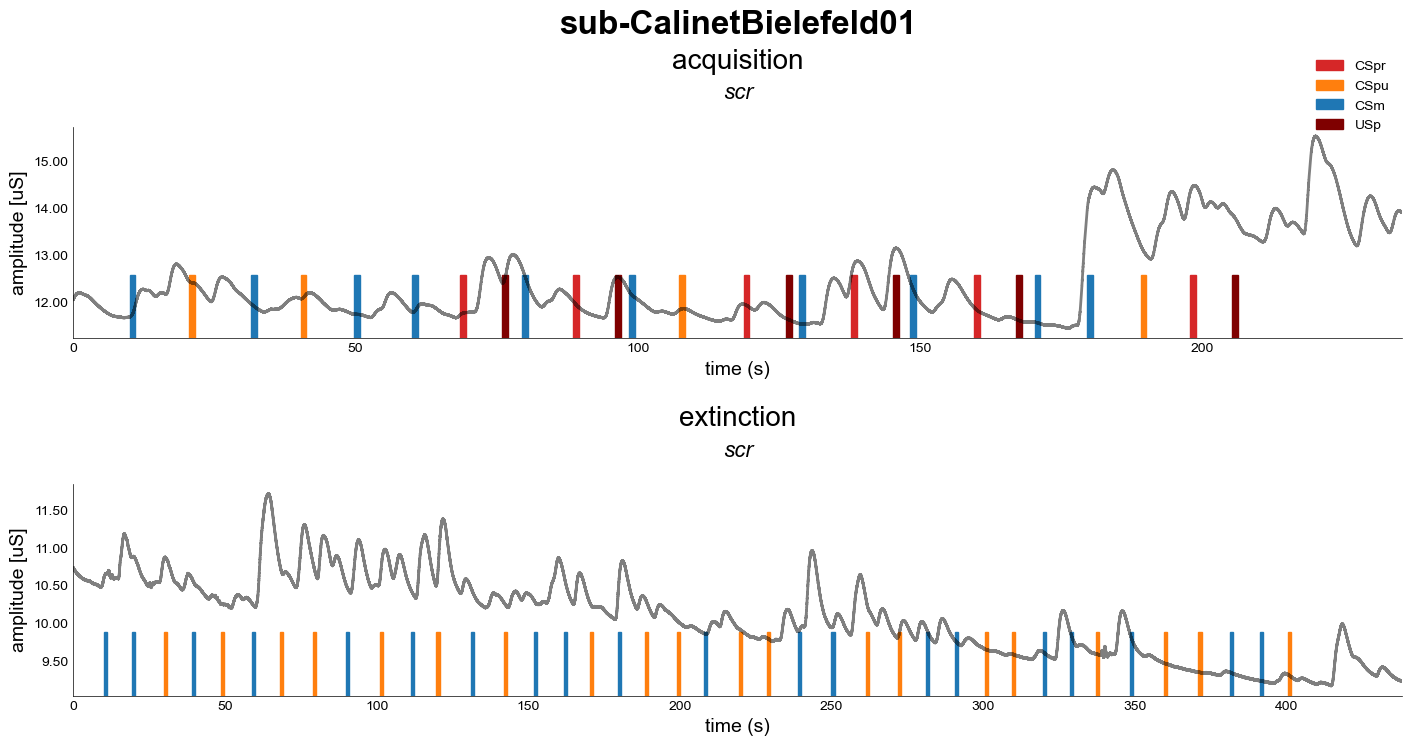

In [108]:
from calinet.plotting import plot_modalities_per_subject
lab_name = "bielefeld"
subject = "sub-CalinetBielefeld01"
f = plot_modalities_per_subject(
    lab_name,
    subject
)

### Pheno

In [119]:
from calinet.sites.bielefeld import parse_questionnaire_file, find_questionnaire_file

questionnaire_file = find_questionnaire_file(r'Z:\CALINET2\sourcedata\bielefeld')

info_df, pheno_df = parse_questionnaire_file(questionnaire_file)

#### Recorded_at

In [67]:
pheno_df["recorded_at"].head()

0    2025-03-04 15:09:23
1    2025-03-05 08:53:21
2    2025-03-05 10:23:46
3    2025-03-05 13:27:32
4    2025-03-06 15:06:28
Name: recorded_at, dtype: object

In [68]:
subset = pd.DataFrame(pheno_df.loc[:, "recorded_at"])

s = subset["recorded_at"].astype(str).str.strip()
parsed = pd.to_datetime(s, errors="coerce")
subset["recorded_at"] = parsed.dt.strftime("%Y-%m-%dT%H:%M:%S")
subset.head()


,recorded_at
0,2025-03-04T15:09:23
1,2025-03-05T08:53:21
2,2025-03-05T10:23:46
3,2025-03-05T13:27:32
4,2025-03-06T15:06:28


## Bologna tests

### Physio

In [95]:
biopac_file = "Z:\\CALINET2\\sourcedata\\bologna\\Data_Battaglia\\sub-CALINET001\\001.acq"
bio = bioread.read_file(biopac_file)
bio.channels

[Channel SCR: 1542124 samples, 1000.0 samples/sec, loaded: True,
 Channel HR: 1542124 samples, 1000.0 samples/sec, loaded: True,
 Channel CS trigger: 1542124 samples, 1000.0 samples/sec, loaded: True,
 Channel Shock trigger: 1542124 samples, 1000.0 samples/sec, loaded: True]

In [99]:

res = biopac.read_acq_file(
    biopac_file,
    channels={
        "SCR": re.compile(r"SCR", re.I),
        "ECG": re.compile(r"HR", re.I),
        "TTL": re.compile(r"CS trigger", re.I),
        "Shock": re.compile(r"Shock trigger", re.I)
    }
)

res.df

,SCR,ECG,TTL,Shock
0,1.640930,-0.052185,0.0,0.0
1,1.640930,-0.051575,0.0,0.0
2,1.640625,-0.050049,0.0,0.0
3,1.641235,-0.049133,0.0,0.0
4,1.640930,-0.047913,0.0,0.0
...,...,...,...,...
1542119,1.445007,-0.104675,0.0,0.0
1542120,1.445618,-0.104675,0.0,0.0
1542121,1.445618,-0.104675,0.0,0.0
1542122,1.445618,-0.105286,0.0,0.0


In [114]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

[2026-03-05 12:25:01] [INFO] calinet.core.events - Extracting marker data
[2026-03-05 12:25:01] [INFO] calinet.core.events - typical_ioi≈19.504s | min_rise_interval_sec=9.752s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-05 12:25:01] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-05 12:25:01] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-05 12:25:01] [INFO] calinet.core.events - Marker data successfully extracted


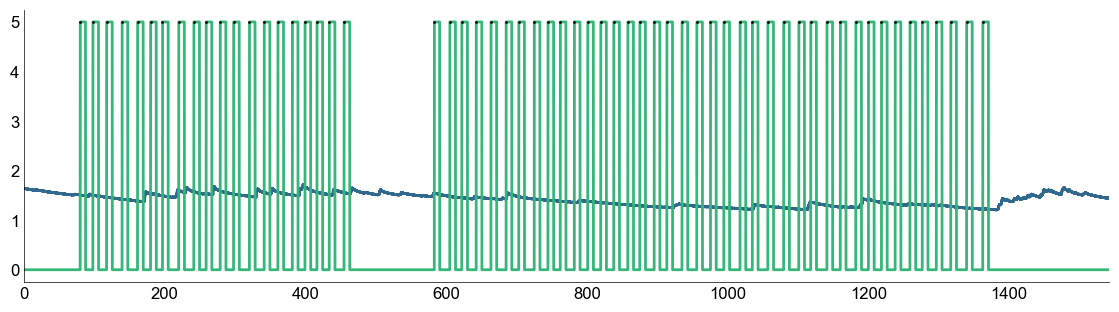

In [122]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

for i in out:
    idx = int(round(i*res.sampling_rate_hz))
    pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

### Pheno

In [140]:
from calinet.sites.bologna import parse_questionnaire_file, find_questionnaire_file

questionnaire_file = find_questionnaire_file(r'Z:\CALINET2\sourcedata\bologna')

info_df, pheno_df = parse_questionnaire_file(questionnaire_file)

[2026-03-19 14:03:53.832] [-] [INFO] calinet.utils - Fetching acquisition date from physiological files for 'recorded_at'
[2026-03-19 14:03:54.122] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:03:54.125] [-] [INFO] calinet.utils - Raw ID: sub-CALINET001 | Converted ID: sub-001 | File: Z:\CALINET2\sourcedata\bologna\Data_Battaglia\sub-CALINET001\sub-CALINET001_ses-1_task-acquisition_2024-09-03_11h29.37.812.csv | Timestamp: 2024-09-03 00:00:00
[2026-03-19 14:03:54.125] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:03:54.131] [-] [INFO] calinet.utils - Raw ID: sub-CALINET002 | Converted ID: sub-002 | File: Z:\CALINET2\sourcedata\bologna\Data_Battaglia\sub-CALINET002\sub-CALINET002_ses-1_task-acquisition_2024-09-03_12h36.51.398.csv | Timestamp: 2024-09-03 00:00:00
[2026-03-19 14:03:54.137] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:03:54.141] [-] [INFO] calinet.utils - Raw ID: sub-CALINET003 | 

In [141]:
pheno_df.head()

,participant_id,recorded_at,room_temperature,humidity,age,sex,handedness,questionnaires_language,ius_1,ius_2,...,bfi_22,bfi_23,bfi_24_r,bfi_25,bfi_26_r,bfi_27_r,bfi_28_r,bfi_29,bfi_30_r,acq_date
0,sub-001,2024-09-03T11:00:00,25,65,32,M,right,0,3,4,...,4,5,4,4,1,3,2,2,1,2024-09-03
1,sub-002,2024-09-03T12:10:00,25,65,27,F,NaN,0,1,2,...,4,5,2,3,2,4,1,4,2,2024-09-03
2,sub-003,2024-09-10T14:00:00,25,62,30,F,right,0,4,2,...,5,5,4,4,2,1,2,4,2,2024-09-10
3,sub-004,2024-09-10T15:45:00,26,64,22,M,right,0,3,4,...,4,4,3,4,3,3,2,4,2,2024-09-10
4,sub-005,2024-09-11T14:10:00,25,59,27,F,right,0,2,4,...,5,5,4,5,2,5,1,2,3,2024-09-11


## Bonn tests

[2026-03-17 16:02:29.535] [WARNING] calinet.plotting - Missing file for task='acquisition', modality='eye2': Z:\CALINET2\converted\bonn\sub-CalinetBonn27\physio\sub-CalinetBonn27_task-acquisition_recording-eye2_physio.tsv.gz. Skipping this axis.
[2026-03-17 16:02:29.594] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\bonn\sub-CalinetBonn27\physio\sub-CalinetBonn27_task-acquisition_recording-ecg_physio.json
[2026-03-17 16:02:29.629] [INFO] calinet.plotting - SamplingFrequency=2000.0
[2026-03-17 16:02:29.630] [INFO] calinet.plotting - Units for 'ecg'=mV
[2026-03-17 16:02:29.633] [INFO] calinet.plotting - Read 'ecg'/'acquisition' file: Z:\CALINET2\converted\bonn\sub-CalinetBonn27\physio\sub-CalinetBonn27_task-acquisition_recording-ecg_physio.tsv.gz
[2026-03-17 16:02:30.302] [INFO] calinet.plotting - 'ecg' channel index: -1
[2026-03-17 16:02:30.358] [INFO] calinet.plotting - Add events
[2026-03-17 16:02:30.405] [INFO] calinet.plotting - Read SamplingFrequency f

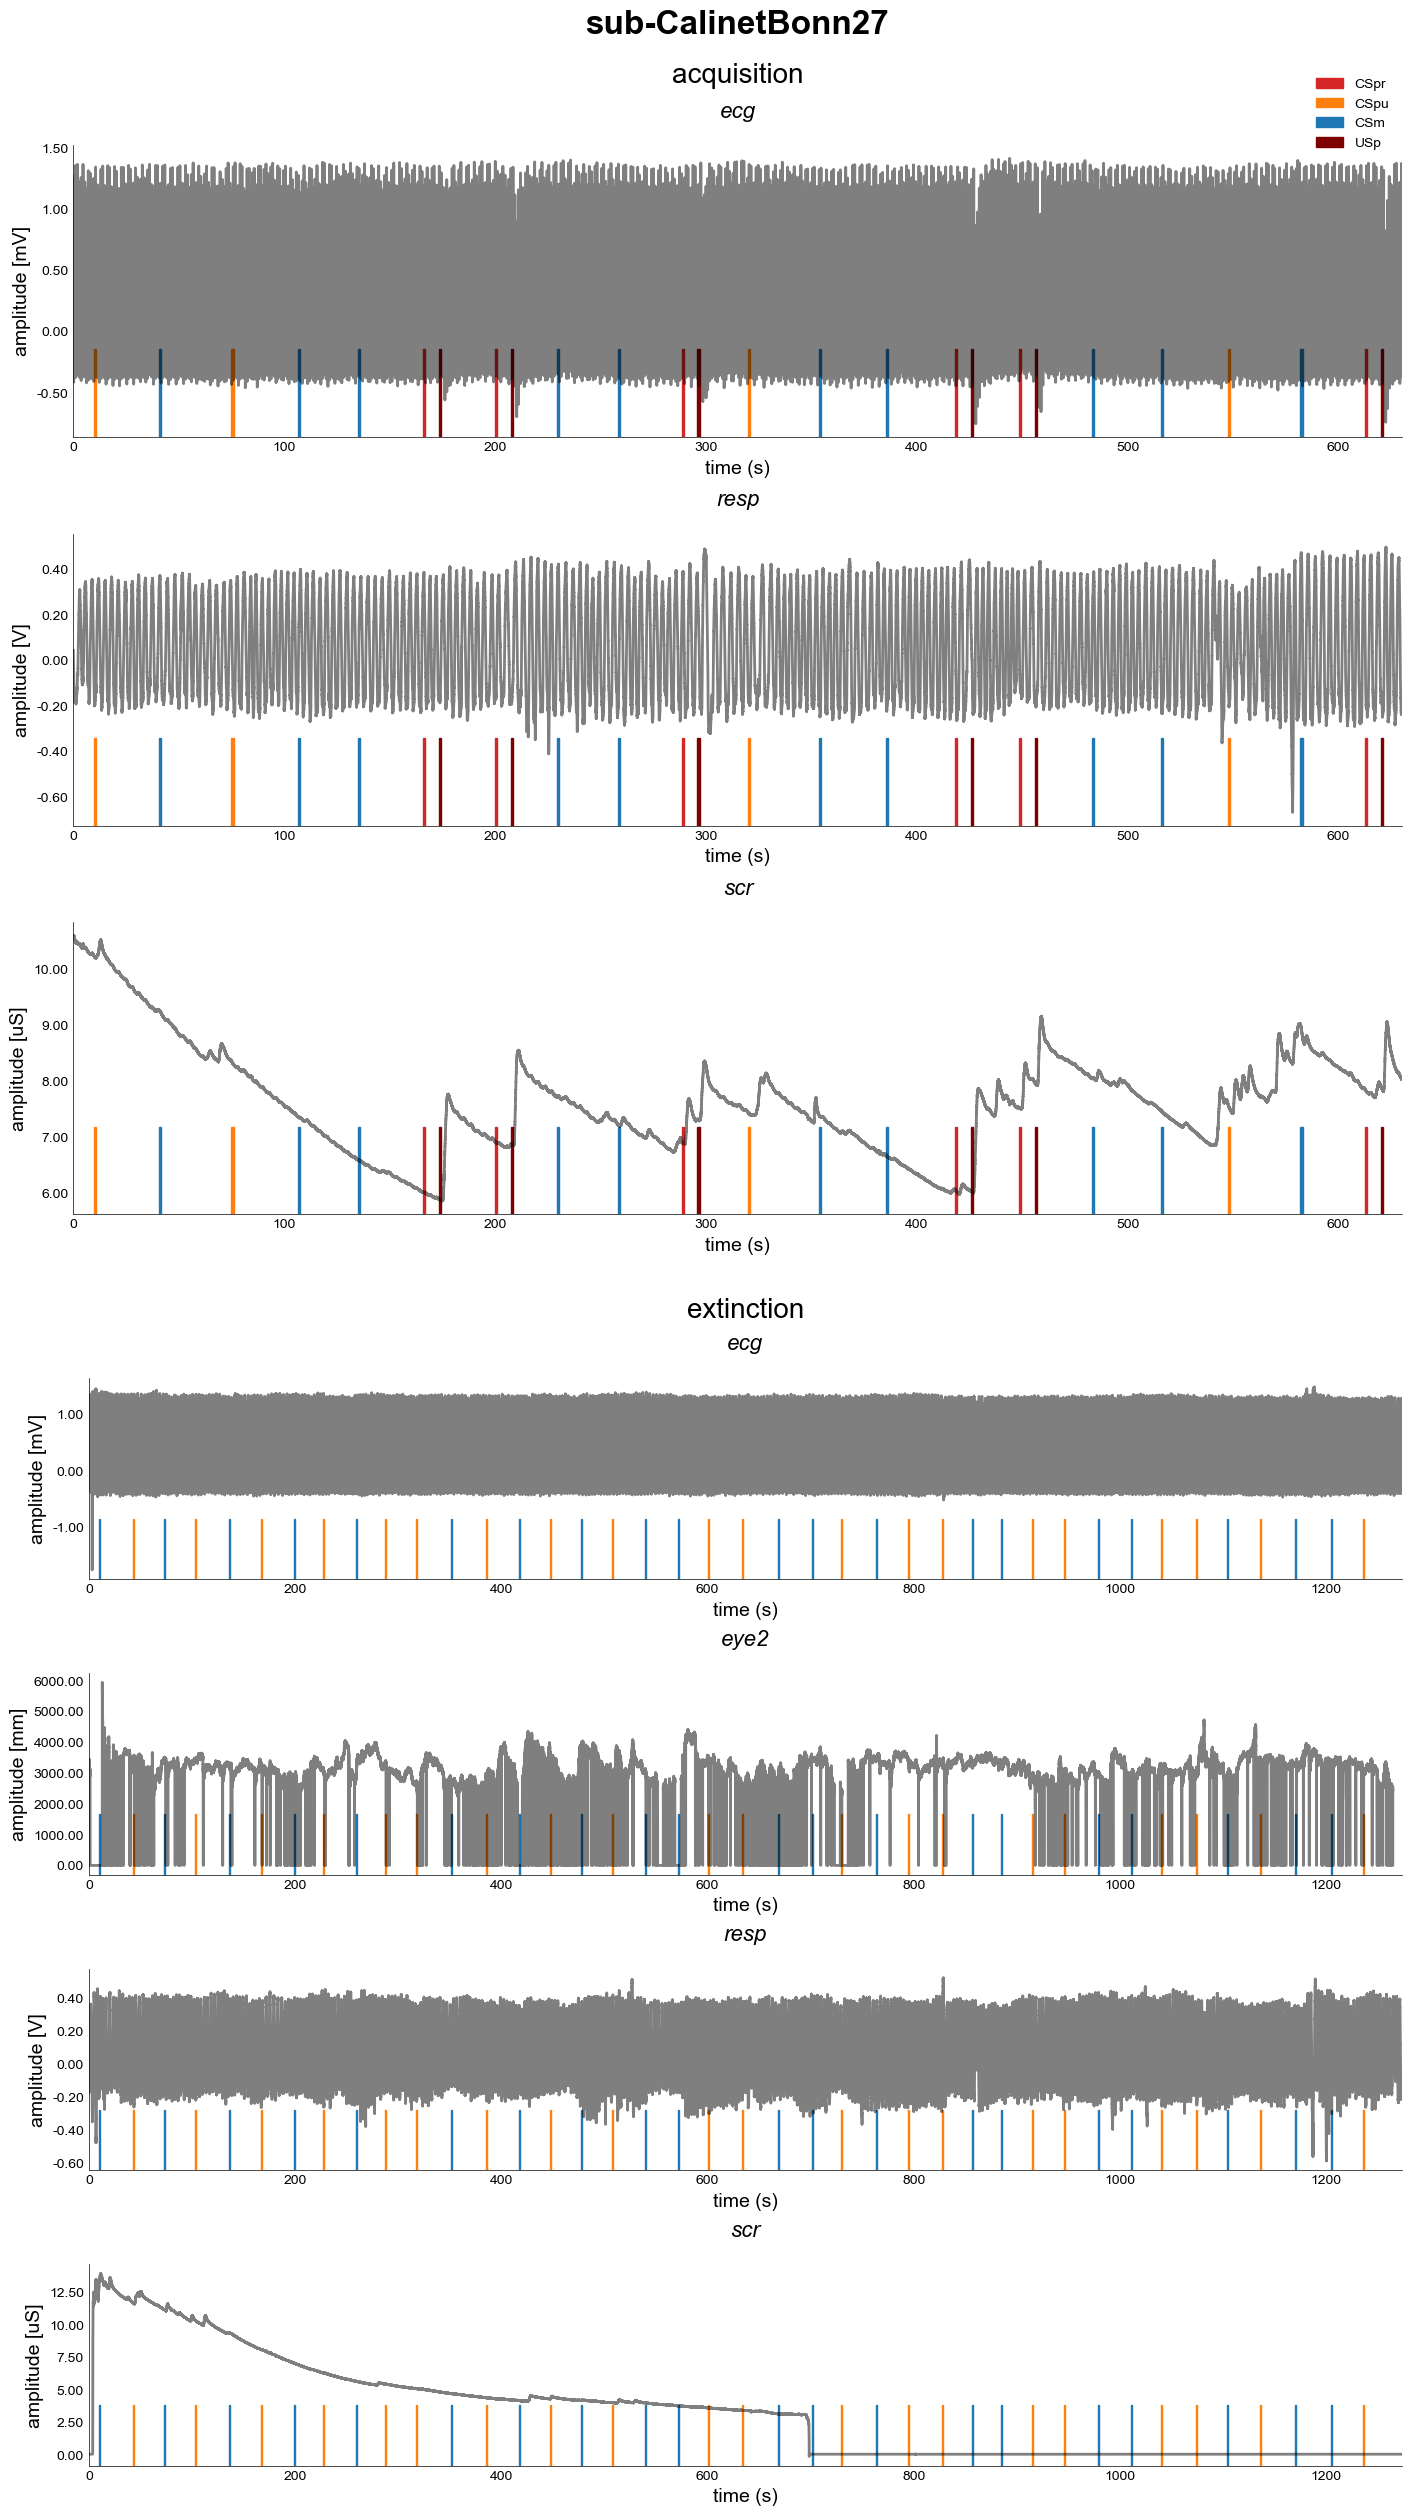

In [66]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from calinet.utils import find_available_modalities
from calinet.plotting import plot_physio_with_events, add_subject_title, plot_modalities_per_subject

lab_name = "bonn"
subject = "sub-CalinetBonn27"
f = plot_modalities_per_subject(
    lab_name,
    subject
)

In [3]:

# root_path = Path("Z:\\CALINET2\\converted")
# subj_path = root_path / lab_name / subject / "physio"
# available_mods = find_available_modalities(subj_path)
# task_names = ["acquisition", "extinction"]

# figsize = (14, (len(task_names) * len(available_mods)) * 3.54)
# fig = plt.figure(figsize=figsize, constrained_layout=True)
# subfigs = fig.subfigures(nrows=len(task_names), ncols=1)

# all_plot_axes = []
# task_title_axes = []

# for task, sf in zip(task_names, np.atleast_1d(subfigs)):
#     nmods = len(available_mods)
#     gs = sf.add_gridspec(
#         nrows=nmods + 1,
#         ncols=1,
#         height_ratios=[0.18] + [1] * nmods
#     )

#     task_ax = sf.add_subplot(gs[0, 0])
#     task_ax.axis("off")
#     task_ax.text(0.5, 0.0, task, ha="center", va="bottom", fontsize=20)
#     task_title_axes.append(task_ax)

#     axs = []
#     for i, mod in enumerate(available_mods, start=1):
#         sharex = axs[0] if axs else None
#         ax = sf.add_subplot(gs[i, 0], sharex=sharex)
#         axs.append(ax)
#         all_plot_axes.append(ax)
        
#         plot_physio_with_events(
#             lab_name,
#             subject,
#             task,
#             mod,
#             legend=False,
#             ax=ax,
#             line_width=2,
#             color="k",
#             x_label="time (s)",
#             plot_alpha=0.5,
#             stim_types=("CSpr", "CSpu", "CSm", "USp"),
#             title={"title": mod, "style": "italic"},
#             y_dec=2
#         )

# # Let constrained_layout finish first
# fig.canvas.draw()

# add_subject_title(
#     fig,
#     task_title_axes[0],
#     subject,
#     pad=0,
#     fontsize=24,
#     fontweight="bold",
# )

In [4]:
from calinet.utils import find_sub_dirs

raw_data_dir = "Z:\\CALINET2\\sourcedata\\bonn"
subj_dirs = find_sub_dirs(raw_data_dir)
print(len(subj_dirs))
subj_dirs

73


['Z:\\CALINET2\\sourcedata\\bonn\\sub-001',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-002',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-003',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-004',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-005',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-006',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-007',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-008',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-009',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-010',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-011',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-012',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-013',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-014',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-015',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-016',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-017',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-018',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-019',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-020',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-021',
 'Z:\\CALINET2\\sourcedata\\bonn\\sub-022',
 'Z:\\CALINET2\\sourcedata\\bonn

In [ ]:
biopac_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-001\\CALINET_Template001.acq"
bio = bioread.read_file(biopac_file)
bio.channels

[Channel EDA100C: 6412785 samples, 2000.0 samples/sec, loaded: True,
 Channel ECG100C: 6412785 samples, 2000.0 samples/sec, loaded: True,
 Channel RSP100C: 6412785 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 0): 6412785 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 7): 6412785 samples, 2000.0 samples/sec, loaded: True]

In [ ]:

res = biopac.read_acq_file(
    biopac_file,
    channels={
        "SCR": re.compile(r"EDA100C", re.I),
        "ECG": re.compile(r"ECG100C", re.I),
        "RESP": re.compile(r"RSP100C", re.I),
        "TTL": re.compile(r"STP Input 0", re.I),
    }
)

res.df

,SCR,ECG,RESP,TTL
0,4.795837,1.125946,0.219727,0.0
1,4.795837,1.120148,0.219116,0.0
2,4.795837,1.114197,0.218506,0.0
3,4.794311,1.108551,0.217590,0.0
4,4.794311,1.102753,0.217285,0.0
...,...,...,...,...
6412780,0.035095,0.085449,0.056152,0.0
6412781,0.035095,0.085907,0.055847,0.0
6412782,0.039673,0.086212,0.055847,0.0
6412783,0.036621,0.086517,0.055542,0.0


In [58]:
res.selected_channel_info

,index,name,units,samples_per_second,length,output_name
1,1,ECG100C,mV,2000.0,6412785,ECG
2,2,RSP100C,Volts,2000.0,6412785,RESP
0,0,EDA100C,microsiemens,2000.0,6412785,SCR
3,3,Digital (STP Input 0),Volts,2000.0,6412785,TTL


In [ ]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

[2026-03-05 13:43:20] [INFO] calinet.core.events - Extracting marker data
[2026-03-05 13:43:21] [INFO] calinet.core.events - typical_ioi≈31.000s | min_rise_interval_sec=15.500s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-05 13:43:21] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-05 13:43:21] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-05 13:43:21] [INFO] calinet.core.events - Marker data successfully extracted


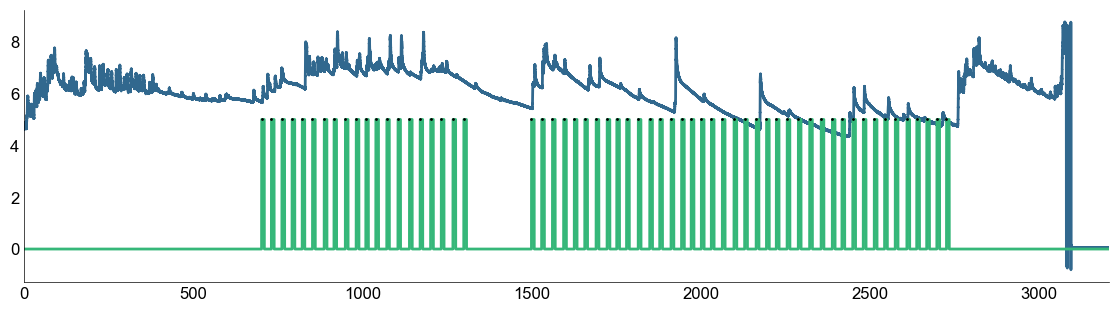

In [126]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

for i in out:
    idx = int(round(i*res.sampling_rate_hz))
    pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

### Ratings

In [424]:
from calinet.core.events import handle_events
from calinet.core.physio import split_df_into_sessions
from calinet.config import available_labs

biopac_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-039\\CALINET_Template039.acq"
res = biopac.read_acq_file(
    biopac_file,
    channels=available_labs.get("bonn").get("ChannelRegex"),
)

onsets_dict, phys_dict = split_df_into_sessions(
    physio_df=res.df,
    sr=res.sampling_rate_hz
)

[2026-03-10 08:51:16] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-10 08:51:17] [INFO] calinet.core.events - typical_ioi≈31.000s | min_rise_interval_sec=15.500s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-10 08:51:17] [INFO] calinet.core.events - Largest gap between markers: 196.379s (between markers 19 and 20)
[2026-03-10 08:51:17] [INFO] calinet.core.events - Long gap threshold=155.0s
[2026-03-10 08:51:17] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-10 08:51:17] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-10 08:51:17] [INFO] calinet.core.events - Marker data successfully extracted
[2026-03-10 08:51:17] [INFO] calinet.core.physio - Find splitting point between ['acquisition', 'extinction'] sessions
[2026-03-10 08:51:17] [INFO] calinet.core.physio - 60(20 + 40) markers found.
[2026-03-10 08:51:17] [INFO] calinet.core.physio - Session diff: 196.379
[2026-03-10 08:51:17] [INFO] calinet.cor

In [440]:
task_ratings, task_onsets = handle_events(
    raw_path=os.path.dirname(biopac_file),
    events_dict=onsets_dict,
    write_files=False
)

task_ratings

[2026-03-10 08:58:24] [INFO] calinet.core.events - Processing events data
[2026-03-10 08:58:24] [INFO] calinet.core.events - Parsing events for task='acquisition'
[2026-03-10 08:58:24] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-10 08:58:24] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\bonn\sub-039\sub-039_ses-1_task-acquisition_2025-09-29_12h07.13.421.csv
[2026-03-10 08:58:24] [WARNING] calinet.core.shock - Only 11 out of 12 scores are present in rating list; assuming first 6 are 'pre-acq', the remaining (5) items are assigned to 'post-acq'
[2026-03-10 08:58:24] [INFO] calinet.core.events - Adding 6 US trials to events
[2026-03-10 08:58:24] [INFO] calinet.core.events - Parsing events for task='extinction'
[2026-03-10 08:58:24] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-10 08:58:24] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\bonn\sub-039\sub-039_ses-1_task-extinction_2025-09-29_12h22.

{'pre_acquisition_ratings': [2, 0, 7, 1, 0, 7],
 'post_acquisition_ratings': [2, 0, 7, 1, 0, None],
 'post_extinction_ratings': [7, 1, 0, 1, 7, 1, 0, 2]}

In [511]:
task_onsets.get("acquisition")

,onset,duration,event_type,stimulus_name,HED,task_name
0,1186.7070,8.000000,CSm,square,"Sensory-event,Visual-presentation,Experimental...",habituation
1,1194.2070,0.000000,USm,square,"Experimental-condition/CS-minus,Experimental-c...",habituation
2,1215.7065,8.000000,CSpu,diamond,"Sensory-event,Visual-presentation,Experimental...",habituation
3,1223.2065,0.000000,USo,diamond,"Experimental-condition/CS-plus,Experimental-co...",habituation
4,1245.2065,8.000000,CSm,square,"Sensory-event,Visual-presentation,Experimental...",habituation
5,1252.7065,0.000000,USm,square,"Experimental-condition/CS-minus,Experimental-c...",habituation
6,1276.7065,8.000000,CSpu,diamond,"Sensory-event,Visual-presentation,Experimental...",habituation
7,1284.2065,0.000000,USo,diamond,"Experimental-condition/CS-plus,Experimental-co...",habituation
8,1307.7065,8.000000,CSpr,diamond,"Sensory-event,Visual-presentation,Experimental...",acquisition
9,1315.2065,0.425340,USp,shock,"Sensory-event,Somatosensory-stimulation,Aversi...",acquisition


In [441]:
from calinet.core.shock import accumulate_shock_ratings
aggregated_shock_ratings = {}
accumulate_shock_ratings(
    aggregated_shock_ratings,
    "sub-039",
    task_ratings
)

['participant_id', 'pre_acq_1', 'pre_acq_2', 'pre_acq_3', 'pre_acq_4', 'pre_acq_5', 'pre_acq_6']
['participant_id', 'post_acq_1', 'post_acq_2', 'post_acq_3', 'post_acq_4', 'post_acq_5', 'post_acq_6']
['participant_id', 'post_ext_1', 'post_ext_2', 'post_ext_3', 'post_ext_4', 'post_ext_5', 'post_ext_6', 'post_ext_7', 'post_ext_8']


In [442]:
aggregated_shock_ratings

{'pre_acquisition_ratings': [{'participant_id': 'sub-039',
   'pre_acq_1': 2,
   'pre_acq_2': 0,
   'pre_acq_3': 7,
   'pre_acq_4': 1,
   'pre_acq_5': 0,
   'pre_acq_6': 7}],
 'post_acquisition_ratings': [{'participant_id': 'sub-039',
   'post_acq_1': 2,
   'post_acq_2': 0,
   'post_acq_3': 7,
   'post_acq_4': 1,
   'post_acq_5': 0,
   'post_acq_6': None}],
 'post_extinction_ratings': [{'participant_id': 'sub-039',
   'post_ext_1': 7,
   'post_ext_2': 1,
   'post_ext_3': 0,
   'post_ext_4': 1,
   'post_ext_5': 7,
   'post_ext_6': 1,
   'post_ext_7': 0,
   'post_ext_8': 2}]}

### Issue with .asc-file [sub-049] -> SOLUTION: added guard against flat dataframe (no variance), exclude

### Issue with AREA to mm conversion [sub-054]

In [67]:
from calinet.imports import biopac
from calinet.config import available_labs
from calinet.core.physio import split_df_into_sessions

biopac_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-054\\CALINET_Template054.acq"
res = biopac.read_acq_file(
    biopac_file,
    channels=available_labs.get("bonn").get("ChannelRegex")
)

onsets_dict, phys_dict = split_df_into_sessions(
    physio_df=res.df,
    sr=res.sampling_rate_hz
)

onsets_dict.keys()

[2026-03-17 17:05:16.346] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-17 17:05:19.405] [INFO] calinet.core.events - typical_ioi≈31.499s | min_rise_interval_sec=15.750s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-17 17:05:19.408] [INFO] calinet.core.events - Largest gap between markers: 234.162s (between markers 19 and 20)
[2026-03-17 17:05:19.410] [INFO] calinet.core.events - Long gap threshold=157.497s (31.499499999999898*5.0)
[2026-03-17 17:05:19.410] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-17 17:05:19.412] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-17 17:05:19.412] [INFO] calinet.core.events - Marker data successfully extracted
[2026-03-17 17:05:19.415] [INFO] calinet.core.physio - Find splitting point between ['acquisition', 'extinction'] sessions
[2026-03-17 17:05:19.417] [INFO] calinet.core.physio - 60(20 + 40) markers found.
[2026-03-17 17:05:19.418] [INFO] calinet.core.phys

dict_keys(['acquisition', 'extinction'])

In [73]:
from calinet.imports.eyelink import asc_to_df
eye_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-054\\sub-054_ses-1_task-extinction_2025-11-13_14h56.33.185.asc"

eye_dict, measurement_type = asc_to_df(eye_file)

In [72]:
measurement_type

'DIAMETER'

In [76]:
for key, df in eye_dict.items():
    if df.empty:
        print(f"Dataframe is empty; setting {key} to None")
        eye_dict[key] = None
    elif df.isna().all().all():
        # all values are NaN
        print(f"All values are NaN; setting {key} to None")
        eye_dict[key] = None

Dataframe is empty; setting eye1 to None


In [79]:
df = eye_dict["eye2"]
df

,x_coordinate,y_coordinate,pupil_size
0,877.2,571.9,3246.0
1,872.3,568.4,3235.0
2,867.6,569.6,3225.0
3,866.3,566.6,3227.0
4,869.7,562.5,3240.0
...,...,...,...
2563014,1035.6,626.1,2398.0
2563015,1033.1,632.7,2425.0
2563016,1031.7,632.2,2447.0
2563017,1033.0,627.7,2450.0


In [89]:
from calinet.core.pupil import diameter_to_mm
diameter_to_mm(
    df["pupil_size"],
    screen_distance=500,
    measurement_type="DIAMETER",
    multiplier=0.119
)

(0          275.910
 1          274.975
 2          274.125
 3          274.295
 4          275.400
             ...   
 2563014    203.830
 2563015    206.125
 2563016    207.995
 2563017    208.250
 2563018    207.145
 Name: pupil_size, Length: 2563019, dtype: float64,
 {'Name': 'diameter_to_mm',
  'Formula': 'diameter_mm = multiplier * (screen_distance / reference_distance) * input',
  'Parameters': {'Multiplier': 0.119,
   'ReferenceDistance': 700,
   'ScreenDistance': 500},
  'Description': 'Converts EyeLink pupil AREA units to estimated pupil diameter in mm using PsPM-style calibration.'})

In [91]:
from calinet.core.pupil import fetch_eye_metadata, fetch_and_write_eye_data

lab_name = "Bonn"
meta_dict, stim_pres = fetch_eye_metadata(
    eye_file,
    lab_name=lab_name
)

eye_dict_mm = fetch_and_write_eye_data(
    eye_file,
    meta_dict=meta_dict,
    stim_pres=stim_pres,
    lab_name=lab_name,
    write_files=False
)

[2026-03-17 17:51:08.865] [INFO] calinet.core.pupil - Fetching metadata
[2026-03-17 17:51:08.998] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 17:51:09.010] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 17:51:09.010] [INFO] calinet.core.pupil - Reading 'sub-054_ses-1_task-extinction_2025-11-13_14h56.33.185.asc' with <function asc_to_df at 0x00000212828A3310> [mode=EyeLink]
[2026-03-17 17:51:22.775] [INFO] calinet.core.pupil - Done reading data
[2026-03-17 17:51:22.776] [INFO] calinet.core.pupil - Processing 'eye1'
[2026-03-17 17:51:22.779] [WARNING] calinet.core.pupil - Dataframe for 'eye1' is empty, assuming data was not recorded
[2026-03-17 17:51:22.781] [INFO] calinet.core.pupil - Processing 'eye2'
[2026-03-17 17:51:22.879] [INFO] calinet.core.pu

In [ ]:
meta_dict.g

dict_keys([])

In [ ]:
from calinet.core.pupil import process_eyetracker_file
process_eyetracker_file(
    eye_file,
    lab_name=lab_name,
    onsets=onsets_dict["extinction"],
    write_files=False
)

[2026-03-17 10:58:20] [INFO] calinet.core.pupil - Fetching metadata
[2026-03-17 10:58:20] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 10:58:20] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 10:58:20] [INFO] calinet.core.pupil - Generating tsv.gz-files
[2026-03-17 10:58:20] [INFO] calinet.core.pupil - Reading 'sub-049_ses-1_task-extinction_2025-10-29_15h34.01.831.asc' with <function asc_to_df at 0x00000212828A3310> [mode=EyeLink]
[2026-03-17 10:58:30] [INFO] calinet.core.pupil - Done reading data
[2026-03-17 10:58:30] [INFO] calinet.core.pupil - Processing 'eye1'
[2026-03-17 10:58:30] [WARNING] calinet.core.pupil - Dataframe for 'eye1' is empty, assuming data was not recorded
[2026-03-17 10:58:30] [INFO] calinet.core.pupil - Processing 'eye2'
[2026-

In [ ]:
from calinet.utils import find_available_modalities

In [19]:
from calinet.imports import biopac
from calinet.config import available_labs
from calinet.core.physio import split_df_into_sessions

biopac_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-049\\CALINET_Template049.acq"
res = biopac.read_acq_file(
    biopac_file,
    channels=available_labs.get("bonn").get("ChannelRegex")
)

onsets_dict, phys_dict = split_df_into_sessions(
    physio_df=res.df,
    sr=res.sampling_rate_hz
)

onsets_dict.keys()

dict_keys(['acquisition', 'extinction'])

In [ ]:
from calinet.imports.eyelink import asc_to_df
eye_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-049\\sub-049_ses-1_task-extinction_2025-10-29_15h34.01.831.asc"

eye_dict, measurement_type = asc_to_df(eye_file)

In [7]:
eye_dict

{'eye1': Empty DataFrame
 Columns: [x_coordinate, y_coordinate, pupil_size]
 Index: [],
 'eye2':          x_coordinate  y_coordinate  pupil_size
 0                 NaN           NaN         0.0
 1                 NaN           NaN         0.0
 2                 NaN           NaN         0.0
 3                 NaN           NaN         0.0
 4                 NaN           NaN         0.0
 ...               ...           ...         ...
 2561014           NaN           NaN         0.0
 2561015           NaN           NaN         0.0
 2561016           NaN           NaN         0.0
 2561017           NaN           NaN         0.0
 2561018           NaN           NaN         0.0
 
 [2561019 rows x 3 columns]}

In [8]:
for key, df in eye_dict.items():
    if df.empty:
        print(f"Dataframe is empty; setting {key} to None")
        eye_dict[key] = None
    elif df.isna().all().all():
        # all values are NaN
        print(f"All values are NaN; setting {key} to None")
        eye_dict[key] = None

Dataframe is empty; setting eye1 to None


In [43]:
from calinet.core.pupil import fetch_eye_metadata, fetch_and_write_eye_data

lab_name = "Bonn"
meta_dict, stim_pres = fetch_eye_metadata(
    eye_file,
    lab_name=lab_name
)

eye_dict_mm = fetch_and_write_eye_data(
    eye_file,
    meta_dict=meta_dict,
    stim_pres=stim_pres,
    lab_name=lab_name,
    write_files=False
)

[2026-03-17 10:53:35] [INFO] calinet.core.pupil - Fetching metadata
[2026-03-17 10:53:36] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 10:53:36] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 10:53:36] [INFO] calinet.core.pupil - Reading 'sub-049_ses-1_task-extinction_2025-10-29_15h34.01.831.asc' with <function asc_to_df at 0x00000212828A3310> [mode=EyeLink]
[2026-03-17 10:53:46] [INFO] calinet.core.pupil - Done reading data
[2026-03-17 10:53:46] [INFO] calinet.core.pupil - Processing 'eye1'
[2026-03-17 10:53:46] [WARNING] calinet.core.pupil - Dataframe for 'eye1' is empty, assuming data was not recorded
[2026-03-17 10:53:46] [INFO] calinet.core.pupil - Processing 'eye2'
[2026-03-17 10:53:46] [WARNING] calinet.core.pupil - 'eye2' has no variation (fl

In [44]:
eye_dict_mm.keys()

dict_keys([])

In [48]:
from calinet.core.pupil import process_eyetracker_file
process_eyetracker_file(
    eye_file,
    lab_name=lab_name,
    onsets=onsets_dict["extinction"],
    write_files=False
)

[2026-03-17 10:58:20] [INFO] calinet.core.pupil - Fetching metadata
[2026-03-17 10:58:20] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 10:58:20] [WARNING] calinet.imports.eyelink - Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
[2026-03-17 10:58:20] [INFO] calinet.core.pupil - Generating tsv.gz-files
[2026-03-17 10:58:20] [INFO] calinet.core.pupil - Reading 'sub-049_ses-1_task-extinction_2025-10-29_15h34.01.831.asc' with <function asc_to_df at 0x00000212828A3310> [mode=EyeLink]
[2026-03-17 10:58:30] [INFO] calinet.core.pupil - Done reading data
[2026-03-17 10:58:30] [INFO] calinet.core.pupil - Processing 'eye1'
[2026-03-17 10:58:30] [WARNING] calinet.core.pupil - Dataframe for 'eye1' is empty, assuming data was not recorded
[2026-03-17 10:58:30] [INFO] calinet.core.pupil - Processing 'eye2'
[2026-

In [ ]:
from calinet.utils import find_available_modalities

### Issue with anonymization & integers phenotype

In [120]:
from calinet.core.anonymize import get_anonymization_map, update_subject_ids
from calinet.utils import find_sub_dirs

raw_path = "Z:\\CALINET2\\sourcedata\\bonn"
subject_list = find_sub_dirs(raw_path)
sub_names = [os.path.basename(i) for i in subject_list]

sub_names_anon_mapping_dict = get_anonymization_map("bonn", sub_names)

[2026-03-18 10:28:50.002] [INFO] calinet.core.anonymize - Lab name: Bonn
[2026-03-18 10:28:50.005] [INFO] calinet.core.anonymize - Lab seed: 397


In [121]:
update_subject_ids(r'Z:\CALINET2\converted\bonn\phenotype\bfi60_german.tsv',sub_names_anon_mapping_dict)

[2026-03-18 10:30:14.600] [INFO] calinet.core.pheno - Aggregated BFI60_GERMAN data saved to: Z:\CALINET2\converted\bonn\phenotype\bfi60_german.tsv


In [122]:
update_subject_ids(r'Z:\CALINET2\converted\bonn\phenotype\participant_info.tsv',sub_names_anon_mapping_dict)

[2026-03-18 10:30:36.307] [INFO] calinet.core.pheno - Aggregated PARTICIPANT_INFO data saved to: Z:\CALINET2\converted\bonn\phenotype\participant_info.tsv


## Leuven tests

### Pheno

In [73]:
from calinet.sites.leuven import parse_questionnaire_file, find_questionnaire_file

questionnaire_file = find_questionnaire_file(r'Z:\CALINET2\sourcedata\leuven')

info_df, pheno_df = parse_questionnaire_file(questionnaire_file)

[2026-03-19 11:40:26.421] [-] [INFO] calinet.utils - Fetching acquisition date from physiological files
[2026-03-19 11:40:26.869] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINET2\sourcedata\leuven\Physiology
[2026-03-19 11:40:26.873] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINET2\sourcedata\leuven\Physiology
[2026-03-19 11:40:26.877] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINET2\sourcedata\leuven\Physiology
[2026-03-19 11:40:26.881] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINET2\sourcedata\leuven\Physiology
[2026-03-19 11:40:26.884] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINET2\sourcedata\leuven\Physiology
[2026-03-19 11:40:26.888] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINET2\sourcedata\leuven\Physiology
[2026-03-19 11:40:26.892] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINET2\sourcedata\leuven\Physiology
[2026-03-19 11:40:26.895] [-] [INFO] calinet.sites.leuven - Physio-folder: Z:\CALINE

In [72]:
pheno_df.head()

,participant_id,recorded_at,room_temperature,humidity,age,sex,handedness,us_intensity,us_rating,csplus_shape,...,bfi_22,bfi_23,bfi_24_r,bfi_25,bfi_26_r,bfi_27_r,bfi_28_r,bfi_29,bfi_30_r,acq_date
0,sub-001,2024-03-14T11:45:00,23.3,40,18,M,NaN,4.6,8,0,...,4,4,3,5,4,4,3,5,1,2024-03-14
1,sub-002,2024-03-14T14:30:00,23.7,39,18,M,left,6.0,7,1,...,5,4,4,4,3,3,4,4,4,2024-03-14
2,sub-003,2024-04-02T16:15:00,24.1,39,19,M,NaN,6.8,8,0,...,4,5,2,4,4,3,3,3,5,2024-04-02
3,sub-005,2024-03-19T11:45:00,22.8,41,19,NaN,NaN,11.1,8,1,...,5,2,1,2,4,3,2,2,2,2024-03-19
4,sub-006,2024-03-19T17:00:00,24.2,41,18,M,NaN,10.2,7,0,...,5,5,1,5,4,3,3,4,4,2024-03-19


In [8]:
pheno_df["recorded_at"].head()

0   1900-01-01 11:45:00
1   1900-01-01 14:30:00
2   1900-01-01 16:15:00
3   1900-01-01 11:45:00
4   1900-01-01 17:00:00
Name: recorded_at, dtype: datetime64[ns]

In [9]:
subset = pd.DataFrame(pheno_df.loc[:, "recorded_at"])

s = subset["recorded_at"].astype(str).str.strip()
parsed = pd.to_datetime(s, errors="coerce")
subset["recorded_at"] = parsed.dt.strftime("%Y-%m-%dT%H:%M:%S")
subset.head()


,recorded_at
0,1900-01-01T11:45:00
1,1900-01-01T14:30:00
2,1900-01-01T16:15:00
3,1900-01-01T11:45:00
4,1900-01-01T17:00:00


### Physio

In [184]:
from calinet.utils import find_sub_dirs

raw_data_dir = "Z:\\CALINET2\\sourcedata\\leuven"
subj_dirs = find_sub_dirs(raw_data_dir)
print(len(subj_dirs))
subj_dirs

32


['Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET001',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET002',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET003',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET005',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET006',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET007',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET009',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET010',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET011',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET012',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET013',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET014',
 'Z:\\CALINET2\\sourcedata\\leuven\\Fear conditioning task\\sub-CALINET016',

In [174]:
biopac_file = "Z:\\CALINET2\\sourcedata\\leuven\\Physiology\\001_CALINET_14032024.acq"
bio = bioread.read_file(biopac_file)
bio.channels

[Channel SCR: 3412924 samples, 2000.0 samples/sec, loaded: True,
 Channel ECG: 3412924 samples, 2000.0 samples/sec, loaded: True,
 Channel CS MARKER: 3412924 samples, 2000.0 samples/sec, loaded: True,
 Channel Heart Rate: 3412924 samples, 2000.0 samples/sec, loaded: True]

In [ ]:

res = biopac.read_acq_file(
    biopac_file,
    channels={
        "SCR": re.compile(r"SCR", re.I),
        "ECG": re.compile(r"Heart Rate", re.I),
        "TTL": re.compile(r"CS MARKER", re.I),
    }
)

res.df

,SCR,ECG,HR,TTL
0,10.088270,0.155792,0.000000,0.0
1,10.088270,0.155945,0.000000,0.0
2,10.088270,0.155945,0.000000,0.0
3,10.088270,0.155945,0.000000,0.0
4,10.088270,0.155945,0.000000,0.0
...,...,...,...,...
3412919,8.567041,0.063019,88.757396,0.0
3412920,8.568573,0.063324,88.757396,0.0
3412921,8.568573,0.063477,88.757396,0.0
3412922,8.568573,0.063629,88.757396,0.0


In [176]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

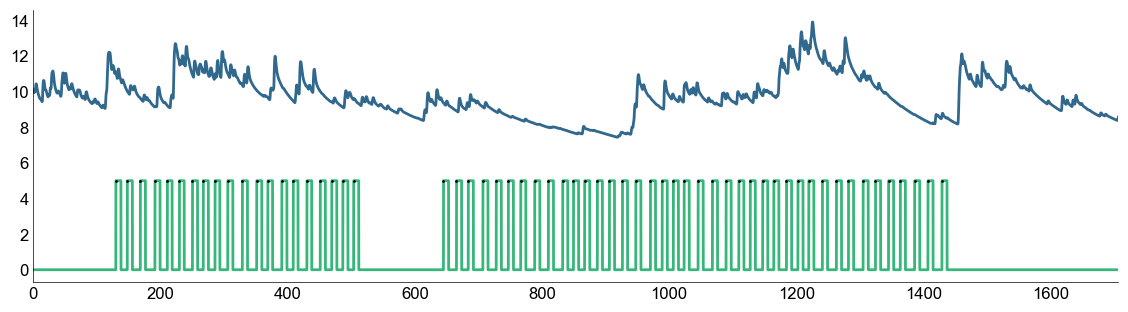

In [ ]:
from lazyfmri import plotting
import numpy as np

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

for i in out:
    idx = int(round(i*res.sampling_rate_hz))
    pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

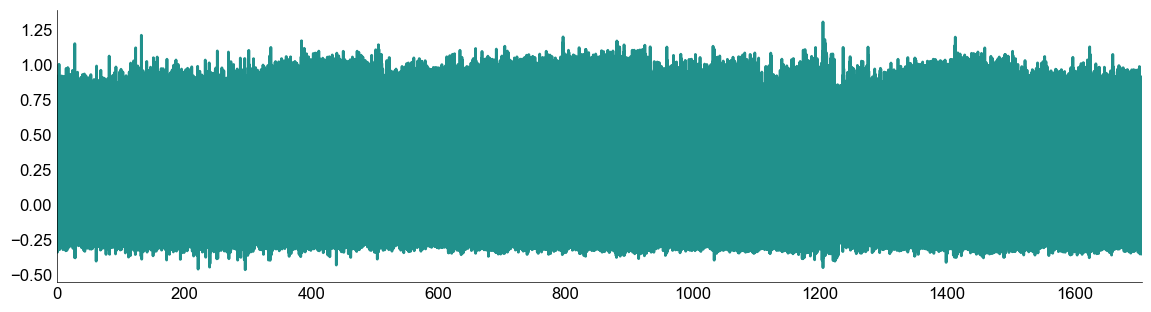

In [181]:
pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["ECG"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

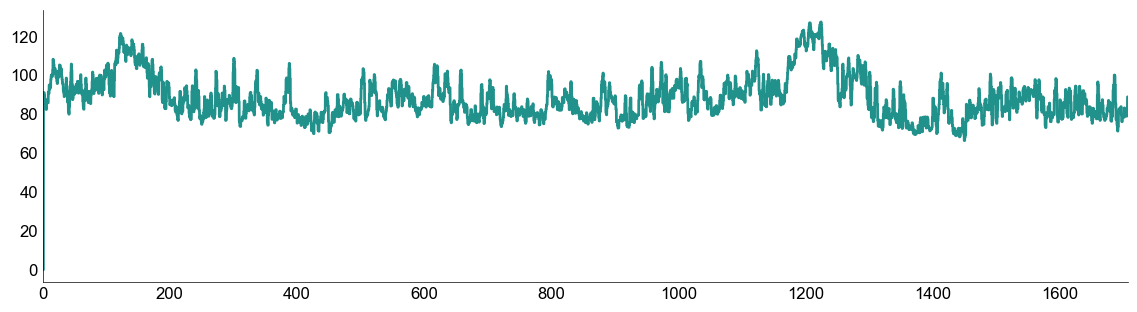

In [182]:
pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["HR"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

## London tests

### Physio

In [59]:
import os
from calinet.sites.london import find_physio_acq_file
from calinet.imports import pspm


raw_data_dir = "Z:\\CALINET2\\sourcedata\\london"
sub_name = "sub-001"
subject_raw_data_path = os.path.join(raw_data_dir, sub_name)
mat_files = find_physio_acq_file(subject_raw_data_path, sub_name)
mat_files

['Z:\\CALINET2\\sourcedata\\london\\sub-001\\pspm_P1.1.mat',
 'Z:\\CALINET2\\sourcedata\\london\\sub-001\\pspm_P1.2.mat']

In [60]:
from scipy.io import loadmat
mat = loadmat(
    mat_files[0],
    squeeze_me=True,
    struct_as_record=False
)["data"]

for i in mat:
    print(i.header.sr)
mat[0].header.__dict__

100
100
50
1


{'_fieldnames': ['chantype', 'units', 'sr', 'transfer', 'minfreq'],
 'chantype': 'scr',
 'units': 'uS',
 'sr': 100,
 'transfer': <scipy.io.matlab._mio5_params.mat_struct at 0x175eda2fdf0>,
 'minfreq': 214.1754478864749}

In [61]:
out = mat[-1].data
out

array([182.132382, 217.117516, 249.632538, 280.13241 , 313.132438,
       347.61677 , 382.617526, 412.632044, 444.132134, 475.131978,
       504.631528, 535.131576, 569.131974, 598.130764, 630.630586,
       662.630844, 696.130616, 730.614934, 761.63029 , 790.630254])

[2026-03-06 18:19:20] [INFO] calinet.sites.london - Reading .mat file(s): ['Z:\\CALINET2\\sourcedata\\london\\sub-001\\pspm_P1.1.mat', 'Z:\\CALINET2\\sourcedata\\london\\sub-001\\pspm_P1.2.mat']
[2026-03-06 18:19:20] [INFO] calinet.sites.london - Loading PsPM-file(s) successfull


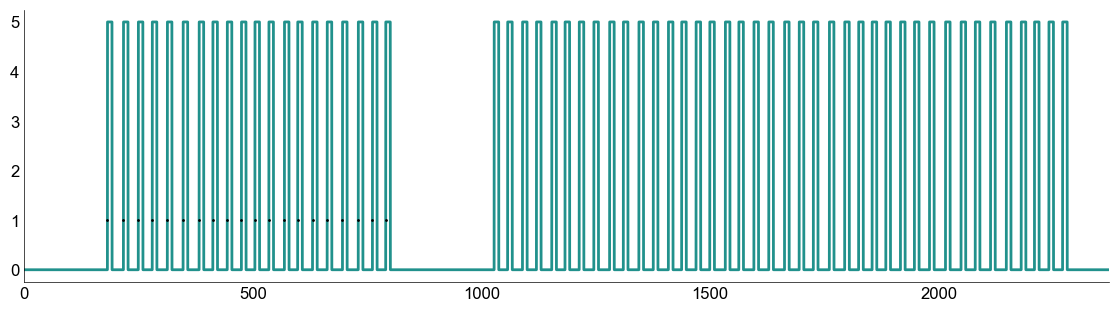

In [62]:
from calinet.sites import london
physio_df, sr, chan_info = london.read_raw_physio_file(mat_files)

from lazyfmri import plotting
import numpy as np

pl = plotting.LazyLine(
    [physio_df[i].to_numpy() for i in ["TTL"]],
    xx=np.arange(0, physio_df.shape[0])/sr,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

for i in out:
    idx = int(round(i*sr))
    pl.axs.plot(i, 1, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

In [63]:
physio_df

,SCR,PPG,RESP,TTL
0,271.867369,3107.0,15877.211741,0
1,272.841254,3105.0,17983.381439,0
2,272.978067,3124.0,15884.215363,0
3,273.001681,3135.0,14790.935505,0
4,272.921407,3137.0,15888.217433,0
...,...,...,...,...
144167,171.347718,3789.0,14691.929266,0
144168,171.461500,3749.0,15788.165686,0
144169,171.261978,3732.0,17874.934853,0
144170,171.533164,3699.0,15776.159476,0


In [41]:
from calinet.core.physio import split_df_into_sessions

sessions = ["acquisition", "extinction"]

session_onsets, session_physio_dfs = split_df_into_sessions(
    physio_df=physio_df,
    sessions=sessions,
    sr=sr
)

[2026-03-06 17:49:38] [INFO] calinet.core.events - Extracting marker data [sr=100.0]
[2026-03-06 17:49:38] [INFO] calinet.core.events - typical_ioi≈31.500s | min_rise_interval_sec=15.750s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-06 17:49:38] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-06 17:49:38] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-06 17:49:38] [INFO] calinet.core.events - Marker data successfully extracted
[2026-03-06 17:49:38] [INFO] calinet.core.physio - Find splitting point between acquisition/extinction session
[2026-03-06 17:49:38] [INFO] calinet.core.physio - 60(20 + 40) markers found.
[2026-03-06 17:49:38] [INFO] calinet.core.physio - Session diff: 487.21
[2026-03-06 17:49:38] [INFO] calinet.core.physio - Setting new start time for task-extinction: 648.049s
[2026-03-06 17:49:38] [INFO] calinet.core.physio - Splitting at t=648.049s [index=64805]


In [ ]:
# Double check that extract times from TTL are same as PsPM marker file
a = out[:20].tolist()
b = session_onsets["acquisition"]

np.allclose(a, b, atol=0.01)

True

### Phenotype

In [75]:
from calinet.sites.london import find_questionnaire_file
raw_path = "Z:\\CALINET2\sourcedata\\london"
quest_files = find_questionnaire_file(raw_path)
quest_files

['Z:\\CALINET2\\sourcedata\\london\\RedCap\\CALINETBig5_DATA_2026-03-08_1729.csv',
 'Z:\\CALINET2\\sourcedata\\london\\RedCap\\CALINETDemographics_DATA_2026-03-08_1729.csv',
 'Z:\\CALINET2\\sourcedata\\london\\RedCap\\CALINETGAD_DATA_2026-03-08_1730.csv',
 'Z:\\CALINET2\\sourcedata\\london\\RedCap\\CALINETIUS_DATA_2026-03-08_1730.csv',
 'Z:\\CALINET2\\sourcedata\\london\\RedCap\\CALINETMIDI_DATA_2026-03-08_1731.csv',
 'Z:\\CALINET2\\sourcedata\\london\\RedCap\\CALINETPHQ_DATA_2026-03-08_1731.csv',
 'Z:\\CALINET2\\sourcedata\\london\\RedCap\\CALINETSTAI_DATA_2026-03-08_1729.csv']

In [81]:
from calinet.sites.london import combine_redcap_files
pheno_df = combine_redcap_files(quest_files)
pheno_df.head()

,participant_id,record_id,redcap_survey_identifier,record_id_timestamp,record_number_bfi,record_id_complete,bfi_timestamp,bfi_1,bfi_1_rev,bfi_2,...,stai_15,stai_16,stai_16_rev,stai_17,stai_18,stai_19,stai_19_rev,stai_20,stai_total,stai_complete
0,sub-001,1,NaN,2024-07-24 14:33:35,0,2,NaN,NaN,NaN,NaN,...,1,3.0,2.0,2,3,1,4,2,54.0,2
1,sub-002,2,NaN,2024-07-24 14:36:09,0,2,2024-07-24 14:38:59,2.0,4.0,5.0,...,1,3.0,2.0,2,2,2,3,2,45.0,2
2,sub-003,3,NaN,2024-07-24 14:43:54,0,2,2024-07-24 14:44:32,1.0,5.0,1.0,...,3,NaN,NaN,3,3,3,2,3,NaN,2
3,sub-004,4,NaN,2024-07-24 14:45:59,0,2,[not completed],1.0,5.0,1.0,...,2,3.0,2.0,3,3,3,2,4,45.0,2
4,sub-005,5,NaN,2024-08-09 13:51:32,0,2,2024-08-09 13:53:18,3.0,3.0,4.0,...,3,2.0,3.0,2,2,3,2,2,48.0,2


In [132]:
from calinet.sites.london import parse_questionnaire_file
info_df, pheno_df = parse_questionnaire_file(quest_files)
pheno_df.head()

,participant_id,record_id,redcap_survey_identifier,recorded_at,record_number_bfi,record_id_complete,bfi_timestamp,bfi_1,bfi_1_rev,bfi_2,...,stai_15,stai_16,stai_16_rev,stai_17,stai_18,stai_19,stai_19_rev,stai_20,stai_total,stai_complete
0,sub-001,1,NaN,2024-07-24 14:33:35,0,2,NaN,NaN,NaN,NaN,...,1,3.0,2.0,2,3,1,4,2,54.0,2
1,sub-002,2,NaN,2024-07-24 14:36:09,0,2,2024-07-24 14:38:59,2.0,4.0,5.0,...,1,3.0,2.0,2,2,2,3,2,45.0,2
2,sub-003,3,NaN,2024-07-24 14:43:54,0,2,2024-07-24 14:44:32,1.0,5.0,1.0,...,3,NaN,NaN,3,3,3,2,3,NaN,2
3,sub-004,4,NaN,2024-07-24 14:45:59,0,2,[not completed],1.0,5.0,1.0,...,2,3.0,2.0,3,3,3,2,4,45.0,2
4,sub-005,5,NaN,2024-08-09 13:51:32,0,2,2024-08-09 13:53:18,3.0,3.0,4.0,...,3,2.0,3.0,2,2,3,2,2,48.0,2


In [123]:
from calinet.sites.london import *
aggr_stai_data(pheno_df, None).head()

,participant_id,stai20_1_rev,stai20_2,stai20_3,stai20_4,stai20_5,stai20_6_rev,stai20_7_rev,stai20_8,stai20_9,...,stai20_11,stai20_12,stai20_13_rev,stai20_14,stai20_15,stai20_16_rev,stai20_17,stai20_18,stai20_19_rev,stai20_20
0,sub-001,3,3,1,2,3,2,3,1,4,...,4,4,4,3,1,2,2,3,4,2
1,sub-002,3,3,1,2,1,3,3,1,4,...,2,3,3,2,1,2,2,2,3,2
2,sub-003,3,3,1,3,3,2,2,3,3,...,3,3,2,3,3,<NA>,3,3,2,3
3,sub-004,2,3,1,2,3,3,2,1,2,...,3,1,2,2,2,2,3,3,2,4
4,sub-005,2,3,2,2,2,3,3,2,2,...,3,1,3,3,3,3,2,2,2,2


## New York tests

### Physio

In [130]:
# NY has 'scored' or 'unscored' .acq files, but they have different channel names; souble check if the new biopac importer can deal with list-candidates of regexes

biopac_file = "Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET039\\39_C2_100124.acq"
bio = bioread.read_file(biopac_file)
bio.channels

[Channel EDA100C: 4327839 samples, 2000.0 samples/sec, loaded: True,
 Channel CBLCFMA - Current Feedback Monitor, HLT: 4327839 samples, 2000.0 samples/sec, loaded: True,
 Channel Stimulus: 4327839 samples, 2000.0 samples/sec, loaded: True,
 Channel Stimulation: 4327839 samples, 2000.0 samples/sec, loaded: True]

In [ ]:
res = biopac.read_acq_file(
    biopac_file,
    channels={
        "SCR": re.compile(r"EDA100C", re.I),
        "TTL": [
            re.compile(r"Stimulus", re.I),
            re.compile(r"Room", re.I),
        ]
    } 
)

from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

[2026-03-08 09:46:11] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-08 09:46:12] [INFO] calinet.core.events - typical_ioi≈20.000s | min_rise_interval_sec=10.000s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-08 09:46:12] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-08 09:46:12] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-08 09:46:12] [INFO] calinet.core.events - Marker data successfully extracted


In [153]:
biopac_file = "Z:\\CALINET2\\sourcedata\\newyork\\\sub-CALINET001\\c2_1_032924_scored.acq"
bio = bioread.read_file(biopac_file)
bio.channels

[Channel EDA100C: 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel CBLCFMA - Current Feedback Monitor, HLT: 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel Room: 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel CS Minus: 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel CSP1(reinforced): 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel CSP1 (non-reinforced): 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel CSP2 (reinforced): 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel Digital input: 6197366 samples, 2000.0 samples/sec, loaded: True,
 Channel Stimulation: 6197366 samples, 2000.0 samples/sec, loaded: True]

In [ ]:

res = biopac.read_acq_file(
biopac_file,
channels={
        "SCR": re.compile(r"EDA100C", re.I),
        "TTL": [
            re.compile(r"Stimulus", re.I),
            re.compile(r"Room", re.I)
        ],
    } 
)

from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

[2026-03-08 09:46:38] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-08 09:46:39] [INFO] calinet.core.events - typical_ioi≈20.000s | min_rise_interval_sec=10.000s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-08 09:46:39] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-08 09:46:39] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-08 09:46:39] [INFO] calinet.core.events - Marker data successfully extracted


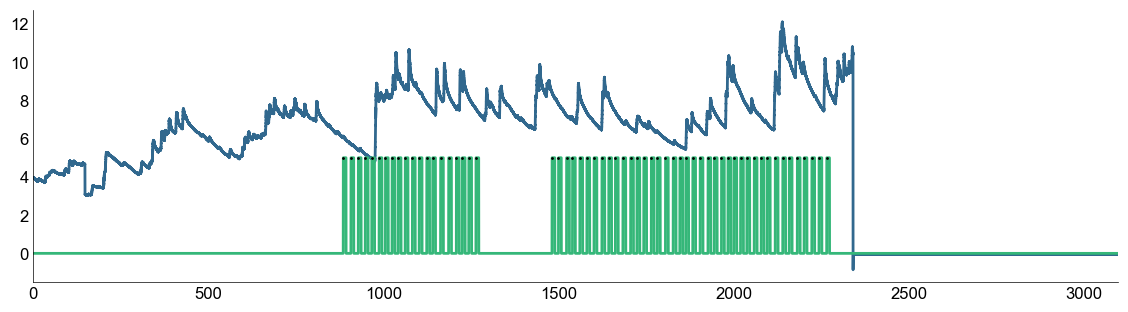

In [156]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

for i in out:
    idx = int(round(i*res.sampling_rate_hz))
    pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

In [174]:
# test trimming function
from calinet.data import pspm_trim

trim = pspm_trim(
    res.df,
    out,
    from_=-10,
    to=60,
    fs=res.sampling_rate_hz
)

[2026-03-08 10:12:18] [INFO] calinet.data - Starting PsPM-style trimming
[2026-03-08 10:12:18] [INFO] calinet.data - Timestamp column not found, generating using sampling rate [fs=2000.0]
[2026-03-08 10:12:18] [INFO] calinet.data - Trimming parameters: from=-10, to=60, reference=marker
[2026-03-08 10:12:18] [INFO] calinet.data - Start=874.8725s, end=2325.6245s
[2026-03-08 10:12:19] [INFO] calinet.data - Trimming complete


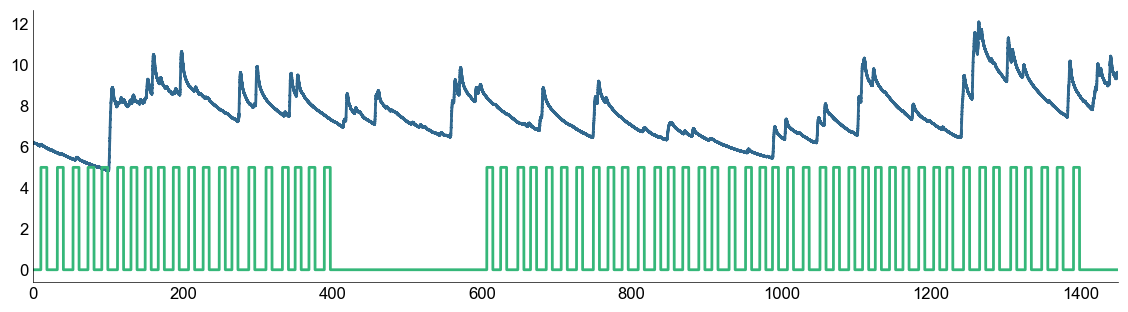

In [166]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [trim.data[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=trim.data["timestamp"].to_numpy(),
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

# for i in res.events["onset"].to_numpy():
#     idx = int(round(i*res.sampling_rate_hz))
#     pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

In [175]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    trim.data,
    res.sampling_rate_hz
)

[2026-03-08 10:13:01] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-08 10:13:01] [INFO] calinet.core.events - typical_ioi≈20.000s | min_rise_interval_sec=10.000s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-08 10:13:01] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-08 10:13:01] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-08 10:13:01] [INFO] calinet.core.events - Marker data successfully extracted


### Test plot

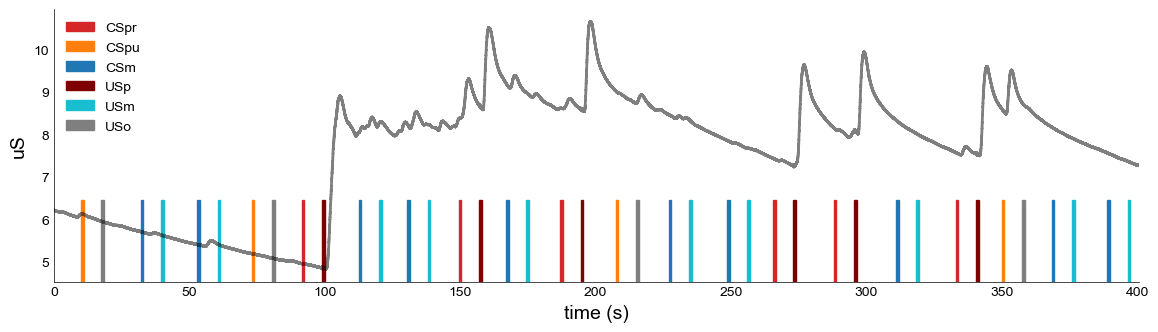

In [ ]:
from calinet.plotting import plot_physio_with_events
import matplotlib.pyplot as plt

ax = plot_physio_with_events(
    "newyork",
    "sub-001",
    "acquisition",
    "scr",
    line_width=2,
    color="k",
    x_label="time (s)",
    y_label="uS",
    plot_alpha=0.5,
    stim_types=("CSpr", "CSpu", "CSm", "USp")
)

Text(0.5, 0.98, 'sub-001')

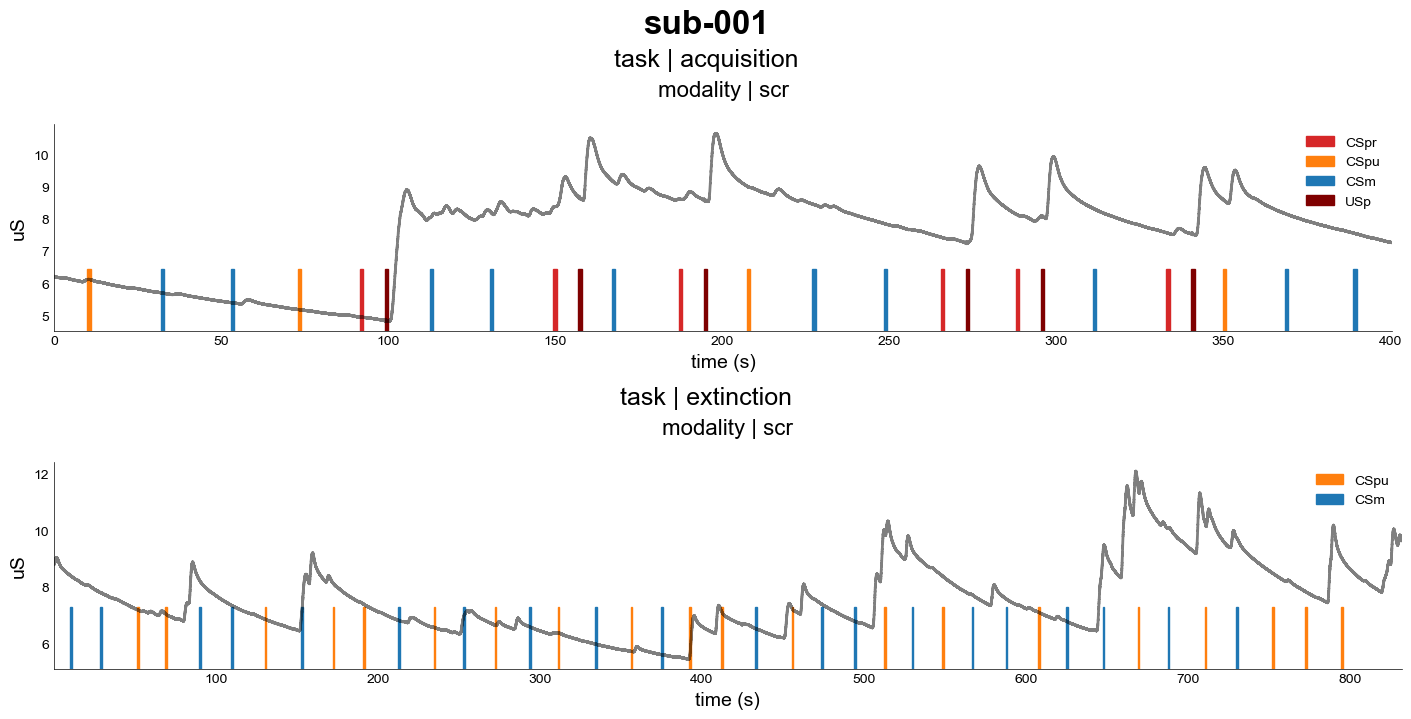

In [255]:
from calinet.utils import find_available_modalities
from pathlib import Path
lab_name = "newyork"
subject = "sub-001"

root_path = Path("Z:\\CALINET2\\converted")
subj_path = root_path / lab_name / subject / "physio"
available_mods = find_available_modalities(subj_path)
task_names = ["acquisition", "extinction"]

figsize = (14, (len(task_names)*len(available_mods))*3.54)
fig = plt.figure(figsize=figsize, constrained_layout=True)
sfs = fig.subfigures(nrows=len(task_names))

for ix, (task, sf) in enumerate(zip(task_names, sfs)):

    axs = sf.subplots(nrows=len(available_mods))
    axs = np.atleast_1d(axs)
    for ax, mod in zip(axs, available_mods):
        ax = plot_physio_with_events(
            lab_name,
            subject,
            task,
            mod,
            ax=ax,
            line_width=2,
            color="k",
            x_label="time (s)",
            y_label="uS",
            plot_alpha=0.5,
            stim_types=("CSpr", "CSpu", "CSm", "USp"),
            title=f"modality | {mod}"
        )


    sf.suptitle(f"task | {task}", fontsize=18)
fig.suptitle(subject, fontsize=24, fontweight="bold")


In [258]:
df = cio.read_physio_tsv_headerless("Z:\\CALINET2\\converted\\newyork\\sub-001\\physio\\sub-001_task-acquisition_recording-scr_physio.tsv.gz")
df

,0,1
0,0.0000,6.217956
1,0.0005,6.216430
2,0.0010,6.214904
3,0.0015,6.214904
4,0.0020,6.217956
...,...,...
801402,400.7010,7.261657
801403,400.7015,7.261657
801404,400.7020,7.264709
801405,400.7025,7.260131


### Rating issue

In [140]:
from calinet.core.events import find_events_file_csv

csv_file = "Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET019\\sub-CALINET019\\sub-CALINET019_ses-1_task-acquisition_2024-09-10_10h59.38.496.csv"

find_events_file_csv(os.path.dirname(csv_file), "acquisition")

[2026-03-07 17:38:09] [INFO] calinet.core.events - Found 3 matching CSV file(s)
[2026-03-07 17:38:09] [INFO] calinet.core.events - Selected largest CSV file: Z:\CALINET2\sourcedata\newyork\sub-CALINET019\sub-CALINET019\sub-CALINET019_ses-1_task-acquisition_2024-09-10_11h00.47.047.csv (0.02 MB)


'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET019\\sub-CALINET019\\sub-CALINET019_ses-1_task-acquisition_2024-09-10_11h00.47.047.csv'

In [138]:
os.path.dirname(csv_file)

'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET019\\sub-CALINET019'

### Phenotype

In [101]:
from calinet.sites.newyork import parse_questionnaire_file, parse_subject_questionnaire

df_info, df_pheno = parse_questionnaire_file("Z:\\CALINET2\\sourcedata\\newyork")

[2026-03-19 12:09:38.791] [-] [INFO] calinet.sites.newyork - Fetching participant info for New York
[2026-03-19 12:09:45.313] [-] [INFO] calinet.sites.newyork - Reading master data: Z:\CALINET2\sourcedata\newyork\Copy of CALINET2_MASTER_DATA.xlsx
[2026-03-19 12:09:46.853] [-] [INFO] calinet.sites.newyork - Reading subject-specific questionnaire data
[2026-03-19 12:09:47.521] [-] [INFO] calinet.sites.newyork - Found 31 subjects in Z:\CALINET2\sourcedata\newyork
[2026-03-19 12:09:47.523] [-] [WARNING] calinet.sites.newyork - No SOC/BFI data for sub-CALINET001; returning NaNs
[2026-03-19 12:09:47.525] [-] [WARNING] calinet.sites.newyork - No GAD/PHQ data for sub-CALINET001; returning NaNs
[2026-03-19 12:09:47.527] [-] [WARNING] calinet.sites.newyork - No IUS/STAI data for sub-CALINET001; returning NaNs
[2026-03-19 12:09:47.529] [-] [WARNING] calinet.sites.newyork - No SOC/BFI data for sub-CALINET002; returning NaNs
[2026-03-19 12:09:47.530] [-] [WARNING] calinet.sites.newyork - No GAD/PHQ

In [99]:
df_pheno.shape, df_info.shape

((31, 106), (32, 4))

In [105]:
from calinet.core.dataset import handle_participant_info
(_, df_pheno) = handle_participant_info(
    input_dir="Z:\\CALINET2\\sourcedata\\newyork",
    lab_name="newyork",
    write_file=False
)

[2026-03-07 15:23:27] [INFO] calinet.sites.newyork - Fetching participant info for New York
[2026-03-07 15:23:28] [INFO] calinet.sites.newyork - Reading master data: Z:\CALINET2\sourcedata\newyork\Copy of CALINET2_MASTER_DATA.xlsx
[2026-03-07 15:23:29] [INFO] calinet.sites.newyork - Reading subject-specific questionnaire data
[2026-03-07 15:23:30] [INFO] calinet.sites.newyork - Found 31 subjects in Z:\CALINET2\sourcedata\newyork
[2026-03-07 15:23:30] [WARNING] calinet.sites.newyork - No SOC/MIDI data for sub-CALINET001; returning NaNs
[2026-03-07 15:23:30] [WARNING] calinet.sites.newyork - No GAD/PHQ data for sub-CALINET001; returning NaNs
[2026-03-07 15:23:30] [WARNING] calinet.sites.newyork - No IUS/STAI data for sub-CALINET001; returning NaNs
[2026-03-07 15:23:30] [WARNING] calinet.sites.newyork - No SOC/MIDI data for sub-CALINET002; returning NaNs
[2026-03-07 15:23:30] [WARNING] calinet.sites.newyork - No GAD/PHQ data for sub-CALINET002; returning NaNs
[2026-03-07 15:23:30] [WARNIN

In [106]:
df_pheno.head()

,master_number,participant_id,order,hab_csm_1,hab_csm_2,hab_csp_1,hab_csp_2,acq_csm_1,acq_csm_2,acq_csm_3,...,stai20_11,stai20_12,stai20_13,stai20_14,stai20_15,stai20_16,stai20_17,stai20_18,stai20_19,stai20_20
0,582,sub-001,A1,0.000000,0.176471,0.000000,0.000000,0.254471,0.315993,0.271846,...,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a
1,583,sub-002,R1,0.294086,0.000000,0.275092,0.000000,0.567712,0.637775,0.464991,...,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a
2,585,sub-004,R3,0.000000,0.000000,0.410007,0.176012,0.368930,0.000000,0.659347,...,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a
3,586,sub-005,A1,0.374668,0.000000,0.000000,0.000000,0.532196,0.086280,0.593298,...,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a
4,587,sub-006,A2,0.338380,0.000000,0.000000,0.000000,0.000000,0.000000,0.452827,...,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a


In [108]:
columns_to_keep = [
    "participant_id",
    "room_temperature",
    "age",
    "sex",
    "handedness",
]

df_pheno[columns_to_keep].head()

,participant_id,room_temperature,age,sex,handedness
0,sub-001,25.6,22.0,female,right
1,sub-002,26.1,24.0,female,right
2,sub-004,25.6,24.0,female,right
3,sub-005,25.6,22.0,female,right
4,sub-006,25.6,19.0,female,right


### Issue with conversion [sub-012] -> SOLUTION: duplicated child/parent directory -> missing .acq file

In [97]:
from calinet.sites.newyork import find_physio_acq_file
from calinet.utils import find_sub_dirs

raw_data_dir = r'Z:\CALINET2\sourcedata\newyork'

subject_dirs = find_sub_dirs(raw_data_dir)
subject_dirs


['Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET001',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET002',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET004',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET005',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET006',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET008',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET009',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET012',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET013',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET014',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET015',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET016',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET017',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET019',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET021',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET023',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET024',
 'Z:\\CALINET2\\sourcedata\\newyork\\sub-CALINET025',
 'Z:\\CALINET2\\sourcedata\\

In [ ]:

biopac_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-054\\CALINET_Template054.acq"
res = biopac.read_acq_file(
    biopac_file,
    channels=available_labs.get("bonn").get("ChannelRegex")
)

onsets_dict, phys_dict = split_df_into_sessions(
    physio_df=res.df,
    sr=res.sampling_rate_hz
)

onsets_dict.keys()

## Reading tests

### Phenotype

In [74]:
from calinet.sites.reading import *
raw_data_dir = "Z:\\CALINET2\\sourcedata\\reading"
df = parse_all_quest_txt_files(raw_data_dir)

[2026-03-19 11:41:01.255] [-] [INFO] calinet.sites.reading - Extracted subject 16 from header in Z:\CALINET2\sourcedata\reading\exclude\sub-CALINET016\quest1-016-1.txt
[2026-03-19 11:41:01.327] [-] [INFO] calinet.sites.reading - Extracted subject 23 from header in Z:\CALINET2\sourcedata\reading\exclude\sub-CALINET023\quest1-023-1.txt
[2026-03-19 11:41:01.412] [-] [INFO] calinet.sites.reading - Extracted subject 23 from header in Z:\CALINET2\sourcedata\reading\exclude\sub-CALINET023\quest2-023-1.txt
[2026-03-19 11:41:01.494] [-] [INFO] calinet.sites.reading - Extracted subject 1 from header in Z:\CALINET2\sourcedata\reading\sub-CALINET001\quest1-001-1.txt
[2026-03-19 11:41:01.566] [-] [INFO] calinet.sites.reading - Extracted subject 1 from header in Z:\CALINET2\sourcedata\reading\sub-CALINET001\quest2-001-1.txt
[2026-03-19 11:41:01.643] [-] [INFO] calinet.sites.reading - Extracted subject 2 from header in Z:\CALINET2\sourcedata\reading\sub-CALINET002\quest1-002-1.txt
[2026-03-19 11:41:0

In [134]:
from calinet.sites.reading import parse_questionnaire_file
pheno_df = read_participant_file(raw_data_dir)

[2026-03-19 14:00:15.072] [-] [INFO] calinet.sites.reading - Reading room conditions file: Z:\CALINET2\sourcedata\reading\Calinet_Hormonal questionnaire_roomconditions.xlsx
[2026-03-19 14:00:15.146] [-] [INFO] calinet.utils - Fetching acquisition date from physiological files for 'recorded_at'
[2026-03-19 14:00:15.400] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:00:15.402] [-] [INFO] calinet.utils - Raw ID: sub-CALINET001 | Converted ID: sub-001 | File: Z:\CALINET2\sourcedata\reading\sub-CALINET001\sub-CALINET001_ses-1_task-acquisition_2025-03-10_11h41.31.149.csv | Timestamp: 2025-03-10 00:00:00
[2026-03-19 14:00:15.404] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:00:15.406] [-] [INFO] calinet.utils - Raw ID: sub-CALINET002 | Converted ID: sub-002 | File: Z:\CALINET2\sourcedata\reading\sub-CALINET002\sub-CALINET002_ses-1_task-acquisition_2025-03-13_13h48.45.355.csv | Timestamp: 2025-03-13 00:00:00
[2026-03-19 14:00:15.40

In [126]:
from calinet.utils import extract_subject_id
extract_subject_id("sub-CALINET030")

'030'

In [131]:
from calinet.utils import creation_date
creation_date(r"Z:\CALINET2\sourcedata\reading\sub-CALINET001\sub-CALINET001_ses-1_task-acquisition_2025-03-10_11h41.31.149.csv")

Timestamp('2025-03-10 00:00:00')

In [123]:
pheno_df.tail()

,participant_id,recorded_at,room_temperature,humidity,age,sex,Have you already had your menopause,Do you use hormonal contraceptives,When was the last tiime you took hormonal contraceptives?,When are you next going to take hormonal contraceptives?,date of last period?,date of next periods?,cycle length?,acq_date
29,sub-030,2025-08-08T12:30:00,24.4,41.0,29.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-08
30,sub-031,2025-08-08T14:00:00,25.2,42.0,31.0,Feamle,no,no,NaN,NaN,20.07.25,21.08.25,33,2025-08-08
31,sub-032,1900-01-01T10:00:00,24.4,45.0,20.0,Female,no,no,NaN,NaN,03.08.2025,02.09.2025,29,1900-01-01
32,sub-033,1900-01-01T11:20:00,25.4,46.0,20.0,Female,no,no,NaN,NaN,28.07.2025,13.09.2025,48,1900-01-01
33,sub-034,1900-01-01T15:20:00,25.3,44.0,24.0,Female,no,no,1.10.2022,NaN,12.07.2025,11.08.2025,30,1900-01-01


In [12]:
pheno_df["recorded_at"].head()

0    11:01:00
1    13:07:00
2    10:05:00
3    10:35:00
4    14:00:00
Name: recorded_at, dtype: object

In [13]:
# enfore consistent timestamp
pheno_df["recorded_at"] = (
    pd.to_datetime(pheno_df["recorded_at"], format="%H:%M:%S", errors="coerce")
    .dt.strftime("%Y-%m-%dT%H:%M:%S")
)

pheno_df["recorded_at"]

0     1900-01-01T11:01:00
1     1900-01-01T13:07:00
2     1900-01-01T10:05:00
3     1900-01-01T10:35:00
4     1900-01-01T14:00:00
5     1900-01-01T16:00:00
6     1900-01-01T10:40:00
7     1900-01-01T12:57:00
8     1900-01-01T09:05:00
9     1900-01-01T11:05:00
10    1900-01-01T13:00:00
11    1900-01-01T15:05:00
12    1900-01-01T09:30:00
13    1900-01-01T13:40:00
14    1900-01-01T15:00:00
15    1900-01-01T09:30:00
16    1900-01-01T15:15:00
17    1900-01-01T13:30:00
18    1900-01-01T15:20:00
19    1900-01-01T03:30:00
20    1900-01-01T09:30:00
21    1900-01-01T15:05:00
22    1900-01-01T09:15:00
23    1900-01-01T11:25:00
24    1900-01-01T09:30:00
25    1900-01-01T09:40:00
26    1900-01-01T11:00:00
27    1900-01-01T12:30:00
28    1900-01-01T14:00:00
29    1900-01-01T10:00:00
30    1900-01-01T11:20:00
31    1900-01-01T15:20:00
Name: recorded_at, dtype: object

In [125]:
df[df.columns[df.columns.str.contains("stai")]]

,stai_1,stai_2,stai_3,stai_4,stai_5,stai_6,stai_7,stai_8,stai_9,stai_10,stai_11,stai_12,stai_13,stai_14,stai_15,stai_16,stai_17,stai_18,stai_19,stai_20
0,3,3,1,1,2,2,3,1,3,3,2,3,3,1,2,3,3,2,3,1
1,4,2,2,2,2,2,2,1,2,4,2,2,2,1,1,4,2,2,1,2
2,3,3,2,3,3,2,2,2,2,3,2,2,2,3,2,2,3,2,3,2
3,3,4,2,2,2,2,2,2,3,2,2,3,2,4,2,2,3,3,1,2
4,3,3,1,2,2,2,3,2,2,2,3,1,3,4,3,2,2,1,3,1
5,2,2,2,4,2,1,2,3,2,1,3,4,1,2,4,1,1,3,2,1
6,2,4,1,3,2,1,2,2,4,2,2,3,2,4,1,1,4,4,2,4
7,2,4,2,4,3,1,2,2,3,2,3,2,2,4,1,2,4,4,2,4
8,3,2,1,2,4,2,4,1,4,3,2,3,4,4,1,2,3,2,3,2
9,2,2,3,4,3,2,2,3,4,2,3,4,2,3,3,2,3,4,3,3


In [283]:

df.head()["handedness"]

0    right
1    right
2    right
3    right
4    right
Name: handedness, dtype: object

In [ ]:
from calinet.sites.reading import parse_questionnaire_file
df_info, df_pheno = parse_questionnaire_file(raw_data_dir)

[2026-03-10 10:59:08] [INFO] root - Extracted subject 16 from header in Z:\CALINET2\sourcedata\reading\exclude\sub-CALINET016\quest1-016-1.txt
[2026-03-10 10:59:08] [INFO] root - Extracted subject 23 from header in Z:\CALINET2\sourcedata\reading\exclude\sub-CALINET023\quest1-023-1.txt
[2026-03-10 10:59:08] [INFO] root - Extracted subject 23 from header in Z:\CALINET2\sourcedata\reading\exclude\sub-CALINET023\quest2-023-1.txt
[2026-03-10 10:59:08] [INFO] root - Extracted subject 1 from header in Z:\CALINET2\sourcedata\reading\sub-CALINET001\quest1-001-1.txt
[2026-03-10 10:59:08] [INFO] root - Extracted subject 1 from header in Z:\CALINET2\sourcedata\reading\sub-CALINET001\quest2-001-1.txt
[2026-03-10 10:59:08] [INFO] root - Extracted subject 2 from header in Z:\CALINET2\sourcedata\reading\sub-CALINET002\quest1-002-1.txt
[2026-03-10 10:59:08] [INFO] root - Extracted subject 2 from header in Z:\CALINET2\sourcedata\reading\sub-CALINET002\quest2-002-1.txt
[2026-03-10 10:59:08] [INFO] root -

In [461]:
# pre-define columns
cols = ["participant_id"] + [c for c in df_pheno.columns if "stai_" in c]

# check if they exist
available_cols = [col for col in cols if col in df_pheno.columns]
len(available_cols)

21

### Physio

In [160]:
txt_file = "Z:\\CALINET2\\sourcedata\\reading\\sub-CALINET001\\Calinet_AcqExt_PhysioData_001.txt"
os.path.splitext(txt_file)[0]

'Z:\\CALINET2\\sourcedata\\reading\\sub-CALINET001\\Calinet_AcqExt_PhysioData_001'

In [161]:
from calinet.imports import biopac
res = biopac.read_txt_file(
    txt_file,
    channels={
        "Time": "Time",
        "SCR": "SCR",
        "Pulse": "Pulse",
        "TTL": "TTL",
    },
)
res.df

,Time,SCR,Pulse,TTL
0,0.000,-1.005832,51.531250,0
1,0.001,-1.005832,80.359380,0
2,0.002,-1.005832,79.375000,0
3,0.003,-1.005832,78.453130,0
4,0.004,-1.005832,77.703130,0
...,...,...,...,...
2053039,856.245,-9.078728,8.484375,0
2053040,856.246,-9.078728,10.546880,0
2053041,856.247,-9.078728,12.734380,0
2053042,856.248,-9.078728,15.046880,0


In [162]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz,
    gap_factor=2
)

[2026-03-19 15:25:33.545] [-] [INFO] calinet.core.events - Extracting marker data [sr=1000.0]
[2026-03-19 15:25:36.378] [-] [INFO] calinet.core.events - typical_ioi≈19.501s | min_rise_interval_sec=9.750s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-19 15:25:36.380] [-] [INFO] calinet.core.events - Largest gap between markers: 65.801s (between markers 19 and 20)
[2026-03-19 15:25:36.381] [-] [INFO] calinet.core.events - Long gap threshold=39.002s (19.501*2)
[2026-03-19 15:25:36.382] [-] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-19 15:25:36.382] [-] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-19 15:25:36.382] [-] [INFO] calinet.core.events - Marker data successfully extracted


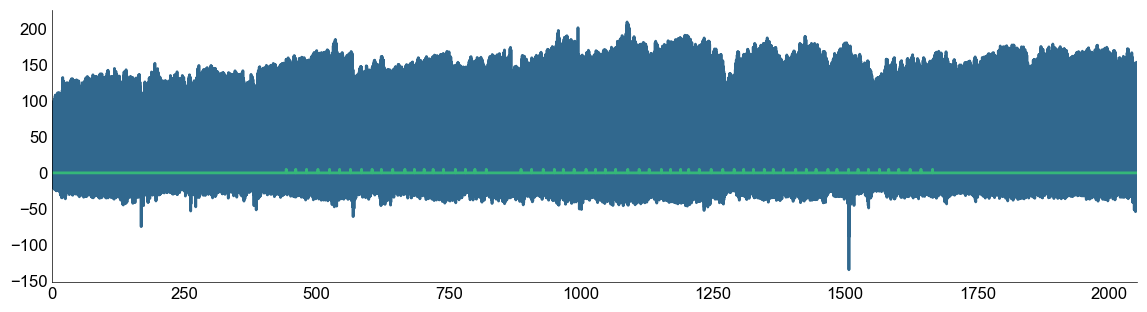

In [163]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["Pulse", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

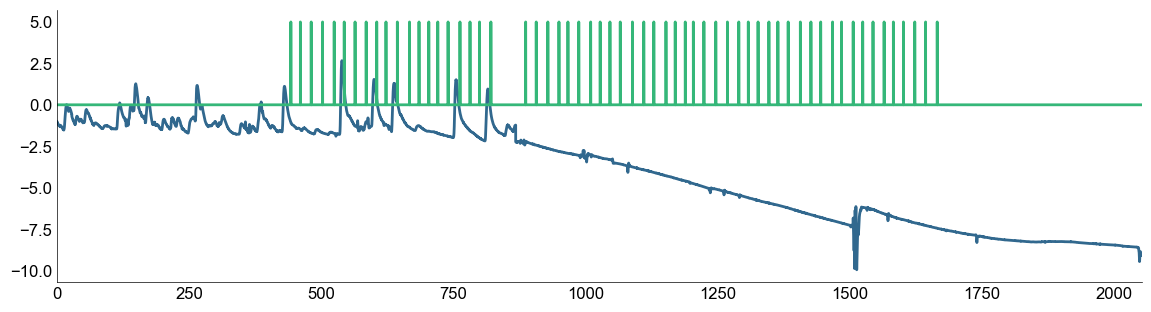

In [332]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

# for i in res.events["onset"].to_numpy():
#     idx = int(round(i*res.sampling_rate_hz))
#     pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

Text(0.5, 0.98, 'sub-001')

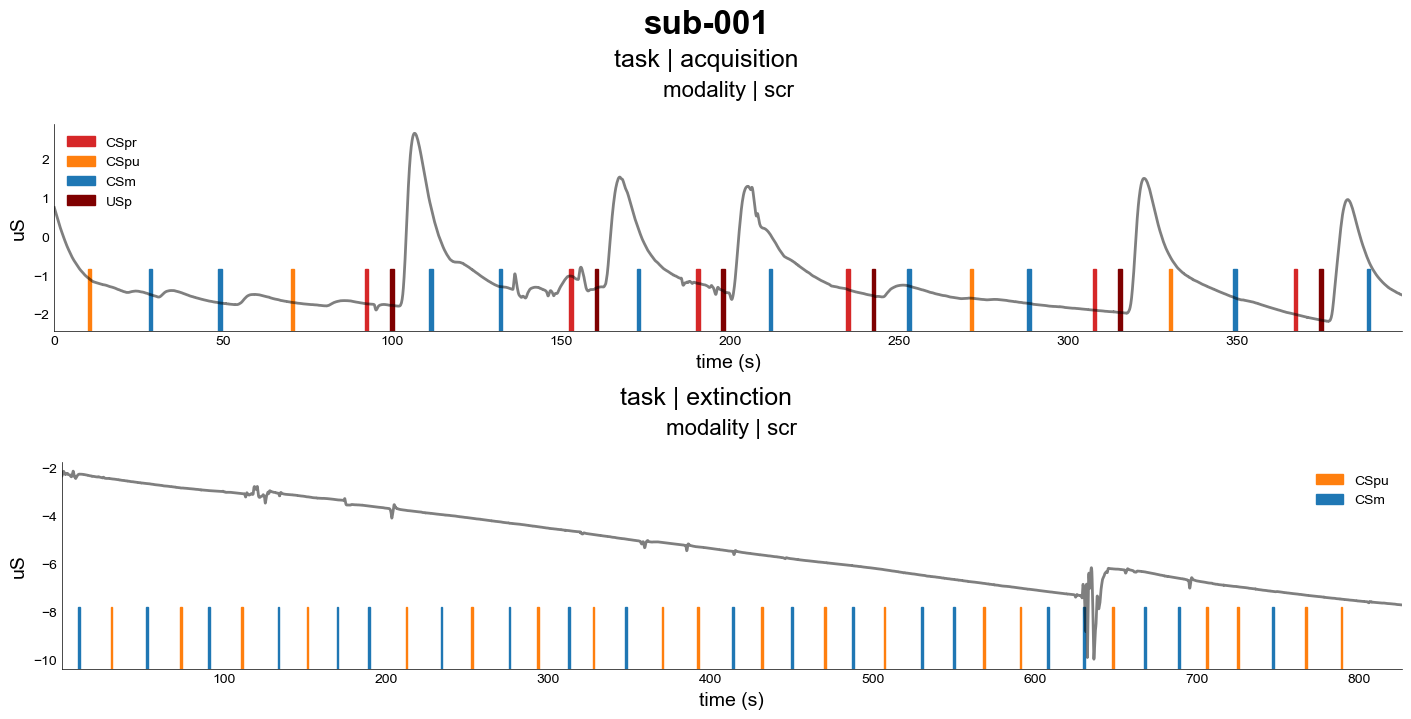

In [358]:
from calinet.utils import find_available_modalities
from pathlib import Path
lab_name = "reading"
subject = "sub-001"

root_path = Path("Z:\\CALINET2\\converted")
subj_path = root_path / lab_name / subject / "physio"
available_mods = find_available_modalities(subj_path)
task_names = ["acquisition", "extinction"]

figsize = (14, (len(task_names)*len(available_mods))*3.54)
fig = plt.figure(figsize=figsize, constrained_layout=True)
sfs = fig.subfigures(nrows=len(task_names))

for ix, (task, sf) in enumerate(zip(task_names, sfs)):

    axs = sf.subplots(nrows=len(available_mods))
    axs = np.atleast_1d(axs)
    for ax, mod in zip(axs, available_mods):
        ax = plot_physio_with_events(
            lab_name,
            subject,
            task,
            mod,
            ax=ax,
            line_width=2,
            color="k",
            x_label="time (s)",
            y_label="uS",
            plot_alpha=0.5,
            stim_types=("CSpr", "CSpu", "CSm", "USp"),
            title=f"modality | {mod}"
        )


    sf.suptitle(f"task | {task}", fontsize=18)
fig.suptitle(subject, fontsize=24, fontweight="bold")


### Missing ratings

In [359]:
from calinet.core.events import handle_events

txt_file = "Z:\\CALINET2\\sourcedata\\reading\\sub-CALINET034\\Calinet_AcqExt_PhysioData_034.txt"
res = biopac.read_txt_file(
    biopac_file,
    channels={
        "SCR": "SCR",
        "TTL": "TTL",
    },
)

onsets_dict, phys_dict = split_df_into_sessions(
    physio_df=res.df,
    sr=res.sampling_rate_hz
)

[2026-03-09 20:49:20] [INFO] calinet.core.events - Extracting marker data [sr=1000.0]
[2026-03-09 20:49:23] [INFO] calinet.core.events - typical_ioi≈19.501s | min_rise_interval_sec=9.750s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-09 20:49:23] [INFO] calinet.core.events - Largest gap between markers: 65.801s (between markers 19 and 20)
[2026-03-09 20:49:23] [INFO] calinet.core.events - Long gap threshold=97.505s
[2026-03-09 20:49:23] [INFO] calinet.core.events - 60 markers found in a single cluster. No long gaps.
[2026-03-09 20:49:23] [INFO] calinet.core.physio - Find splitting point between ['acquisition', 'extinction'] sessions
[2026-03-09 20:49:23] [INFO] calinet.core.physio - 60(20 + 40) markers found.
[2026-03-09 20:49:23] [INFO] calinet.core.physio - Session diff: 65.801
[2026-03-09 20:49:23] [INFO] calinet.core.physio - Setting new start time for task-extinction: 831.377s
[2026-03-09 20:49:23] [INFO] calinet.core.physio - Splitting at t=831.377s [index=831377]


In [502]:
onsets_dict

{'acquisition': [1186.707,
  1215.7065,
  1245.2065,
  1276.7065,
  1307.7065,
  1341.7065,
  1373.7065,
  1408.1905,
  1441.7065,
  1471.2065,
  1504.2065,
  1536.706,
  1566.7065,
  1598.2065,
  1627.206,
  1655.706,
  1686.206,
  1714.706,
  1747.706,
  1776.706],
 'extinction': [179.27800000000002,
  213.27800000000002,
  242.77800000000002,
  272.778,
  306.278,
  335.278,
  363.778,
  396.778,
  428.7774999999999,
  459.7774999999999,
  492.278,
  526.762,
  557.2785000000001,
  585.778,
  617.2774999999999,
  647.278,
  676.7774999999999,
  711.262,
  740.2774999999999,
  772.2774999999999,
  805.2774999999999,
  835.7940000000001,
  869.7940000000001,
  900.7940000000001,
  934.2940000000001,
  966.7940000000001,
  1000.7940000000001,
  1033.294,
  1061.794,
  1091.794,
  1123.794,
  1157.294,
  1186.294,
  1216.7935,
  1247.794,
  1279.2935,
  1312.2935,
  1341.7935,
  1376.2775,
  1410.7775]}

In [ ]:
task_ratings, task_onsets = handle_events(
    raw_path="Z:\\CALINET2\\sourcedata\\reading\\sub-CALINET034",
    events_dict=onsets_dict,
    write_files=False
)

[2026-03-09 20:50:06] [INFO] calinet.core.events - Processing events data
[2026-03-09 20:50:06] [INFO] calinet.core.events - Parsing events for task='acquisition'
[2026-03-09 20:50:06] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-09 20:50:06] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\reading\sub-CALINET034\sub-CALINET034_ses-1_task-acquisition_2025-08-08_15h37.36.854.csv
[2026-03-09 20:50:06] [INFO] calinet.core.events - Adding 6 US trials to events
[2026-03-09 20:50:06] [INFO] calinet.core.events - Parsing events for task='extinction'
[2026-03-09 20:50:06] [INFO] calinet.core.events - Found 3 matching CSV file(s)
[2026-03-09 20:50:06] [INFO] calinet.core.events - Selected largest CSV file of 0.02 MB
[2026-03-09 20:50:06] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\reading\sub-CALINET034\sub-CALINET034_ses-1_task-extinction_2025-08-08_15h49.25.760.csv
[2026-03-09 20:50:06] [WARNING] calinet.core.shock - Onl

In [369]:
from calinet.core.shock import accumulate_shock_ratings, write_aggregated_shock_ratings
aggregated_shock_ratings = {}
accumulate_shock_ratings(
    aggregated_shock_ratings,
    "sub-034",
    task_ratings
)

write_aggregated_shock_ratings(
    aggregated_shock_ratings,
    os.getcwd(),
    language="english"
)

In [368]:
aggregated_shock_ratings

{'pre_acquisition_ratings': [{'participant_id': 'sub-034',
   'pre_acq_1': 5,
   'pre_acq_2': 1,
   'pre_acq_3': 2,
   'pre_acq_4': 5,
   'pre_acq_5': 2,
   'pre_acq_6': 1}],
 'post_acquisition_ratings': [{'participant_id': 'sub-034',
   'post_acq_1': 4,
   'post_acq_2': 1,
   'post_acq_3': 2,
   'post_acq_4': 4,
   'post_acq_5': 2,
   'post_acq_6': 2}],
 'post_extinction_ratings': [{'participant_id': 'sub-034',
   'post_ext_1': 1,
   'post_ext_2': 1,
   'post_ext_3': 4,
   'post_ext_4': 1,
   'post_ext_5': 1,
   'post_ext_6': 1,
   'post_ext_7': 4,
   'post_ext_8': 'n/a'}]}

## Southampton tests

### Phenotype

In [14]:
from calinet.sites.southampton import *
raw_data_dir = "Z:\\CALINET2\\sourcedata\\southampton"
df = parse_all_quest_txt_files(raw_data_dir)

[2026-03-19 10:56:25.628] [-] [INFO] calinet.sites.southampton - Extracted subject 1 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-1-1.txt
[2026-03-19 10:56:25.694] [-] [INFO] calinet.sites.southampton - Extracted subject 10 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-10-1.txt
[2026-03-19 10:56:25.756] [-] [INFO] calinet.sites.southampton - Extracted subject 11 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-11-1.txt
[2026-03-19 10:56:25.826] [-] [INFO] calinet.sites.southampton - Extracted subject 12 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-12-1.txt
[2026-03-19 10:56:25.857] [-] [INFO] calinet.sites.southampton - Extracted subject 13 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-13-1.txt
[2026-03-19 10:56:25.921] [-] [INFO] calinet.sites.southampton - Extracted subject 14 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-14-1.txt
[2026-

In [15]:
# pre-define columns
cols = ["participant_id"] + [c for c in df.columns if "stai_" in c]

# check if they exist
available_cols = [col for col in cols if col in df.columns]
len(available_cols)

19

In [16]:
from calinet.sites.southampton import read_participant_file
df_part = read_participant_file(raw_data_dir)
df_part.head()

,participant_id,date,time,sex,age,handedness,Have you already had your menopause,"If yes, at which age did you have your last period",Do you use hormonal contraceptives,which type of contraceptive,When was the last time you took hormonal contaceptives (date),When was the last time you took hormonal contaceptives (time),When are you next going to take hormonal contaceptives (date),When are you next going to take hormonal contaceptives (time),Can you specifiy the date when you started your last period,Can you specifiy the date when you will start your next period,Cycle length,recorded_at
0,sub-001,2024-02-16,09:00:00,female,19,right,no,NaN,no,NaN,NaT,NaN,NaN,NaN,2024-02-11 00:00:00,2024-03-15,33-36,2024-02-16 00:00:00 09:00:00
1,sub-002,2024-02-16,10:23:00,female,21,right,no,NaN,no,NaN,2020-12-01,NaN,NaN,NaN,2023-12-12 00:00:00,NaT,25,2024-02-16 00:00:00 10:23:00
2,sub-003,2024-02-16,11:30:00,female,19,right,no,NaN,no,NaN,NaT,NaN,NaN,NaN,2024-02-09 00:00:00,2024-03-05,24,2024-02-16 00:00:00 11:30:00
3,sub-004,2024-02-16,12:55:00,female,19,right,no,NaN,no,NaN,NaT,NaN,NaN,NaN,2024-01-21 00:00:00,2024-02-18,22,2024-02-16 00:00:00 12:55:00
4,sub-005,2024-02-16,14:00:00,female,18,right,no,NaN,no,NaN,NaT,NaN,NaN,NaN,2024-01-22 00:00:00,2024-02-22,28,2024-02-16 00:00:00 14:00:00


In [133]:
df_part = df_part.drop(
    columns=df.columns.intersection(df_part.columns).drop("participant_id")
)


pheno_df = pd.merge(
    df,
    df_part,
    on="participant_id",
    how="inner",
    indicator=True
)
pheno_df.head()

,participant_id,age,sex,ethnicity,nationality,english_language_fluency,sexual_orientation,ius_1,ius_2,ius_3,...,which type of contraceptive,When was the last time you took hormonal contaceptives (date),When was the last time you took hormonal contaceptives (time),When are you next going to take hormonal contaceptives (date),When are you next going to take hormonal contaceptives (time),Can you specifiy the date when you started your last period,Can you specifiy the date when you will start your next period,Cycle length,recorded_at,_merge
0,sub-001,19,female,white,english,only,bisexual,3,3,2,...,NaN,NaT,NaN,NaN,NaN,2024-02-11 00:00:00,2024-03-15,33-36,2024-02-16 00:00:00 09:00:00,both
1,sub-002,21,Female,White,British,Native,Bisexual,2,4,1,...,NaN,2020-12-01,NaN,NaN,NaN,2023-12-12 00:00:00,NaT,25,2024-02-16 00:00:00 10:23:00,both
2,sub-003,19,female,white,british,fluent,heterosexual,3,4,3,...,NaN,NaT,NaN,NaN,NaN,2024-02-09 00:00:00,2024-03-05,24,2024-02-16 00:00:00 11:30:00,both
3,sub-004,19,female,white,british,fluent,heterosexual,2,3,4,...,NaN,NaT,NaN,NaN,NaN,2024-01-21 00:00:00,2024-02-18,22,2024-02-16 00:00:00 12:55:00,both
4,sub-005,18,Female,White,British,Fluent,Heterosexual,3,4,2,...,NaN,NaT,NaN,NaN,NaN,2024-01-22 00:00:00,2024-02-22,28,2024-02-16 00:00:00 14:00:00,both


In [136]:
from calinet.sites.southampton import parse_questionnaire_file
info_df, pheno_df = parse_questionnaire_file(raw_data_dir)

[2026-03-18 14:39:28.711] [INFO] calinet.sites.southampton - Extracted subject 1 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-1-1.txt
[2026-03-18 14:39:28.740] [INFO] calinet.sites.southampton - Extracted subject 10 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-10-1.txt
[2026-03-18 14:39:28.764] [INFO] calinet.sites.southampton - Extracted subject 11 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-11-1.txt
[2026-03-18 14:39:28.786] [INFO] calinet.sites.southampton - Extracted subject 12 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-12-1.txt
[2026-03-18 14:39:28.814] [INFO] calinet.sites.southampton - Extracted subject 13 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-13-1.txt
[2026-03-18 14:39:28.849] [INFO] calinet.sites.southampton - Extracted subject 14 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-14-1.txt
[2026-03-18 14:39:28.897] [INF

In [137]:
pheno_df["humidity"]

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10    None
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
20    None
21    None
22    None
23    None
24    None
25    None
26    None
27    None
28    None
Name: humidity, dtype: object

In [402]:
df.columns.tolist()

['participant_id',
 'age',
 'sex',
 'ethnicity',
 'nationality',
 'english_language_fluency',
 'sexual_orientation',
 'ius_1',
 'ius_2',
 'ius_3',
 'ius_4',
 'ius_5',
 'ius_6',
 'ius_7',
 'ius_8',
 'ius_9',
 'ius_10',
 'ius_11',
 'ius_12',
 'stai_1',
 'stai_2',
 'stai_3',
 'stai_4',
 'stai_5',
 'stai_6',
 'stai_7',
 'stai_8',
 'stai_9',
 'stai_10',
 'stai_11',
 'stai_12',
 'stai_13',
 'stai_14',
 'stai_15',
 'stai_16',
 'stai_17',
 'stai_18',
 'gad_1',
 'gad_2',
 'gad_3',
 'gad_4',
 'gad_5',
 'gad_6',
 'gad_7',
 'phq_1',
 'phq_2',
 'phq_3',
 'phq_4',
 'phq_5',
 'phq_6',
 'phq_7',
 'phq_8',
 'phq_9',
 'midi_1',
 'midi_2',
 'midi_3',
 'midi_4',
 'midi_5',
 'midi_6',
 'midi_7',
 'midi_8',
 'midi_9',
 'midi_10',
 'midi_11',
 'midi_12',
 'bfi_1',
 'bfi_2',
 'bfi_3',
 'bfi_4',
 'bfi_5',
 'bfi_6',
 'bfi_7',
 'bfi_8',
 'bfi_9',
 'bfi_10',
 'bfi_11',
 'bfi_12',
 'bfi_13',
 'bfi_14',
 'bfi_15',
 'bfi_16',
 'bfi_17',
 'bfi_18',
 'bfi_19',
 'bfi_20',
 'bfi_21',
 'bfi_22',
 'bfi_23',
 'bfi_24',
 'b

In [397]:
from calinet.sites.southampton import parse_questionnaire_file
df_info, df_pheno = parse_questionnaire_file(raw_data_dir)

[2026-03-09 23:41:45] [INFO] root - Extracted subject 1 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-1-1.txt
[2026-03-09 23:41:45] [INFO] root - Extracted subject 10 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-10-1.txt
[2026-03-09 23:41:45] [INFO] root - Extracted subject 11 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-11-1.txt
[2026-03-09 23:41:45] [INFO] root - Extracted subject 12 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-12-1.txt
[2026-03-09 23:41:46] [INFO] root - Extracted subject 13 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-13-1.txt
[2026-03-09 23:41:46] [INFO] root - Extracted subject 14 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-14-1.txt
[2026-03-09 23:41:46] [INFO] root - Extracted subject 15 from header in Z:\CALINET2\sourcedata\southampton\quests\quest1\quest1-15-1.txt
[2026-03-09 23:41:46] [INFO] root - Extract

In [399]:
df_info.head()

,participant_id,age,sex,handedness
0,sub-001,19,female,right
1,sub-002,21,Female,right
2,sub-003,19,female,right
3,sub-004,19,female,right
4,sub-005,18,Female,right


In [400]:
df_pheno.head()

,participant_id,date,time,handedness,Have you already had your menopause,"If yes, at which age did you have your last period",Do you use hormonal contraceptives,which type of contraceptive,When was the last time you took hormonal contaceptives (date),When was the last time you took hormonal contaceptives (time),...,bfi_22,bfi_23,bfi_24,bfi_25,bfi_26,bfi_27,bfi_28,bfi_29,bfi_30,_merge
0,sub-001,2024-02-16,09:00:00,right,no,NaN,no,NaN,NaT,NaN,...,5,4,4,5,2,2,1,3,2,both
1,sub-002,2024-02-16,10:23:00,right,no,NaN,no,NaN,2020-12-01,NaN,...,5,4,5,5,1,1,1,1,4,both
2,sub-003,2024-02-16,11:30:00,right,no,NaN,no,NaN,NaT,NaN,...,4,4,4,4,3,2,2,1,1,both
3,sub-004,2024-02-16,12:55:00,right,no,NaN,no,NaN,NaT,NaN,...,5,4,4,5,5,4,4,2,4,both
4,sub-005,2024-02-16,14:00:00,right,no,NaN,no,NaN,NaT,NaN,...,4,5,4,4,4,2,2,5,1,both


### Physio

In [403]:
biopac_file = "Z:\\CALINET2\\sourcedata\\southampton\\physio\\physio\\Task_PhysioData\\Task_PhysioData_sub01.acq"
bio = bioread.read_file(biopac_file)
bio.channels

[Channel GSR - GSR100C: 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel STM200 - Reference Out - STM200 - Refer: 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel CBLCFMA - Current Feedback Monitor - CB: 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 0): 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 1): 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 2): 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 3): 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 4): 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 5): 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 6): 1596277 samples, 1000.0 samples/sec, loaded: True,
 Channel Digital (STP Input 7): 1596277 samples, 1000.0 samples/sec, loaded: True]

In [418]:

res = biopac.read_acq_file(
    biopac_file,
    channels={
        "SCR": re.compile(r"GSR - GSR100C", re.I),
        "TTL": re.compile(r"STP Input 0", re.I),
    }
)

from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

[2026-03-10 08:31:06] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-10 08:31:07] [INFO] calinet.core.events - typical_ioi≈9.750s | min_rise_interval_sec=4.875s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-10 08:31:07] [INFO] calinet.core.events - Largest gap between markers: 60.092s (between markers 19 and 20)
[2026-03-10 08:31:07] [INFO] calinet.core.events - Long gap threshold=48.75s
[2026-03-10 08:31:07] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-10 08:31:07] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-10 08:31:07] [INFO] calinet.core.events - Marker data successfully extracted


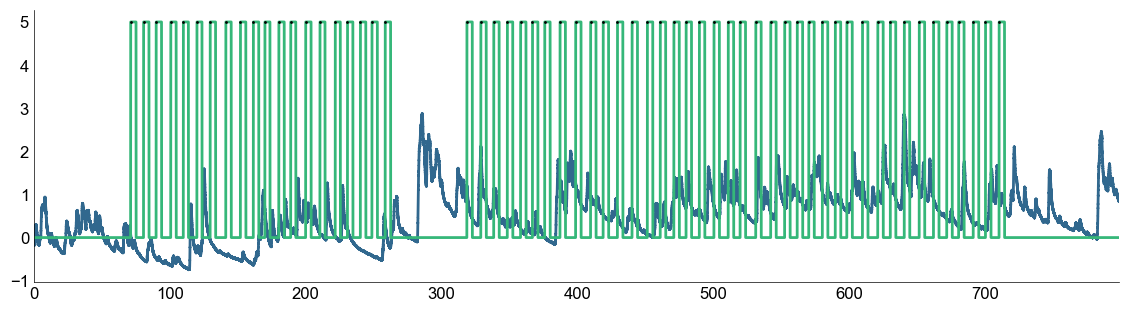

In [419]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

for i in out:
    idx = int(round(i*res.sampling_rate_hz))
    pl.axs.plot(i, 5, marker=".", markersize=2, markerfacecolor="k", markeredgecolor="k")

## Stockholm tests

### Pheno

In [143]:
from calinet.sites.stockholm import parse_questionnaire_file, find_questionnaire_file
from calinet.utils import find_sub_dirs

raw_path = r'Z:\CALINET2\sourcedata\stockholm'
subj_dirs = find_sub_dirs(raw_path)
subj_dirs[:5]

['Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET001',
 'Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET002',
 'Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET003',
 'Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET004',
 'Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET005']

In [144]:
questionnaire_file = find_questionnaire_file(raw_path)
info_df, pheno_df = parse_questionnaire_file(questionnaire_file)

[2026-03-19 14:04:38.303] [-] [INFO] calinet.utils - Fetching acquisition date from physiological files for 'recorded_at'
[2026-03-19 14:04:38.350] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:04:38.354] [-] [INFO] calinet.utils - Raw ID: sub-CALINET001 | Converted ID: sub-001 | File: Z:\CALINET2\sourcedata\stockholm\sub-CALINET001\sub-CALINET001_ses-1_task-acquisition_2024-09-24_10h43.11.813.csv | Timestamp: 2024-09-24 00:00:00
[2026-03-19 14:04:38.357] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:04:38.360] [-] [INFO] calinet.utils - Raw ID: sub-CALINET002 | Converted ID: sub-002 | File: Z:\CALINET2\sourcedata\stockholm\sub-CALINET002\sub-CALINET002_ses-1_task-acquisition_2024-09-25_09h25.04.781.csv | Timestamp: 2024-09-25 00:00:00
[2026-03-19 14:04:38.363] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-19 14:04:38.367] [-] [INFO] calinet.utils - Raw ID: sub-CALINET003 | Converted ID: sub-003 | Fi

In [52]:
pheno_df.head()

,ppn,recorded_at,room_temperature,humidity,age,sex,handedness,questionnaires_language,ius_total,stai_t_total,...,ders_9,ders_10,ders_11,ders_12,ders_13,ders_14,ders_15,ders_16,participant_id,acq_date
0,1.0,2024-09-24T10:21:00,22.2,50.0,30.0,M,right,0.0,32.0,45.0,...,2.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,sub-001,2024-09-24
1,2.0,2024-09-25T09:03:00,19.9,62.0,25.0,F,right,0.0,27.0,43.0,...,3.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0,sub-002,2024-09-25
2,3.0,2024-09-25T14:34:00,21.1,52.0,30.0,M,right,0.0,19.0,26.0,...,2.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,sub-003,2024-09-25
3,4.0,2024-09-25T18:21:00,21.8,45.0,39.0,M,left,0.0,20.0,22.0,...,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,sub-004,2024-09-25
4,5.0,2024-09-26T12:06:00,20.5,43.0,36.0,M,right,0.0,32.0,37.0,...,1.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,sub-005,2024-09-26


In [28]:
subset = pd.DataFrame(pheno_df.loc[:, "recorded_at"])

s = subset["recorded_at"].astype(str).str.strip()
parsed = pd.to_datetime(s, errors="coerce")
subset["recorded_at"] = parsed.dt.strftime("%Y-%m-%dT%H:%M:%S")
subset.head()

,recorded_at
0,1900-01-01T10:21:00
1,1900-01-01T09:03:00
2,1900-01-01T14:34:00
3,1900-01-01T18:21:00
4,1900-01-01T12:06:00


### Eyetracking files

In [17]:
from calinet.core.io import find_smi_txt_files
from calinet.utils import get_session_and_task_name
raw_path = "Z:\\CALINET2\\sourcedata\\stockholm\\P_001(ND)"

smi_files = find_smi_txt_files(raw_path)

for i in smi_files:
    ses, task = get_session_and_task_name(i)
    print(f"{task}: {i}")

extinction: Z:\CALINET2\sourcedata\stockholm\P_001(ND)\eyetracking_Extinction_sub-CALINET001 Samples.txt
acquisition: Z:\CALINET2\sourcedata\stockholm\P_001(ND)\eyetracking_HabituationAcquisition_sub-CALINET001 Samples.txt


In [18]:
from calinet.imports import smi

EYE_JSON_TEMPLATE = {
    "Description": "Eye-tracking recording (gaze position and pupil size) collected during the fear conditioning task",
    "Columns": [
        "timestamp",
        "x_coordinate",
        "y_coordinate",
        "pupil_size"
    ],
    "PhysioType": "eyetrack",
    "StartTime": 0,
    "SampleCoordinateSystem": "gaze-on-screen",
    "timestamp": {
        "LongName": "Time",
        "Description": "a continuously increasing identifier of the sampling time registered by the device",
        "Origin": "System startup",
        "Units": "s"
    },    
    "x_coordinate": {
        "LongName": "Gaze position (x)",
        "Description": "Gaze position x-coordinate of the recorded eye",
        "Units": "pixel",
    },
    "y_coordinate": {
        "LongName": "Gaze position (y)",
        "Description": "Gaze position y-coordinate of the recorded eye",
        "Units": "pixel",
    },
    "pupil_size": {
        "Description": "Pupil diameter",
        "Units": "mm"
    }
}

smi_file = "Z:\\CALINET2\\sourcedata\\stockholm\\P_001(ND)\\eyetracking_HabituationAcquisition_sub-CALINET001 Samples.txt"

info, stim_pres = smi.get_eyetracker_setup_info(
    smi_file,
    "LEFT",
    EYE_JSON_TEMPLATE,
    "Stockholm"
    )

stim_pres


{'StimulusPresentation': {'ScreenDistance': 700.0,
  'ScreenOrigin': ['top', 'left'],
  'ScreenRefreshRate': 60,
  'ScreenResolution': [1920, 1080],
  'ScreenSize': [536.0, 300.0]}}

In [160]:
from calinet.core.pupil import fetch_and_write_eye_data, fetch_and_write_eye_meta

meta_dict, stim_pres = fetch_and_write_eye_meta(
    smi_file,
    "Stockholm",
    write_files=False,
)

eye_dict_mm = fetch_and_write_eye_data(
    smi_file,
    meta_dict=meta_dict,
    stim_pres=stim_pres,
    write_files=False
)

Mismatch in screen dimensions between file [536.0, 300.0] and submitted metadata [565.0, 342.7]. Using screen size from metadata-file
Mismatch in screen dimensions between file [536.0, 300.0] and submitted metadata [565.0, 342.7]. Using screen size from metadata-file


In [161]:
eye_dict_mm.keys()

dict_keys(['eye1', 'eye2'])

In [162]:
meta_dict["eye1"].get("GazeRange")

{'xmin': 0, 'ymin': 0, 'xmax': 565.0, 'ymax': 342.7}

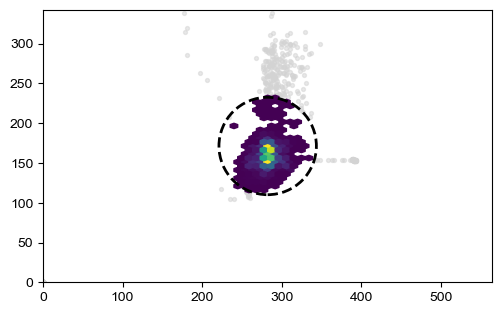

In [163]:
from calinet.plotting import plot_gaze_hexbin_with_dva_circle
screen_mm = stim_pres.get("StimulusPresentation").get("ScreenSize")
# screen_mm = [565, 342.7]
screen_dist_mm = stim_pres.get("StimulusPresentation").get("ScreenDistance")

fig, ax = plot_gaze_hexbin_with_dva_circle(
    eye_dict_mm["eye1"],
    screen_mm=screen_mm,
    viewing_distance_mm=screen_dist_mm,
    dva=5,
    figsize=(7.01, 3.54)
)

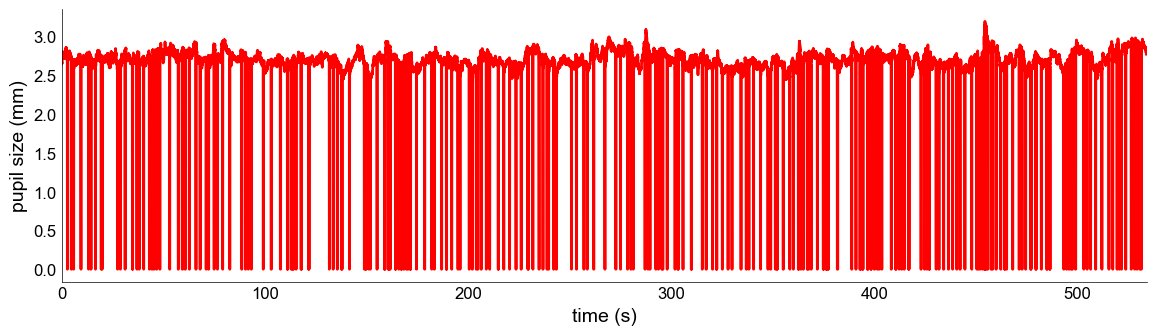

In [164]:
from lazyfmri.plotting import LazyLine
pl = LazyLine(
    eye_dict_mm["eye1"]["pupil_size"].to_numpy(),
    xx=eye_dict_mm["eye1"]["timestamp"].to_numpy(),
    color="r",
    line_width=2,
    figsize=(14,3.54),
    label_size=12,
    x_label="time (s)",
    y_label="pupil size (mm)",
    fontname="Arial"
)

In [156]:
from calinet.imports.smi import smi_txt_to_df
parsed = smi_txt_to_df(smi_file, return_full=True)
df_all = parsed["raw"]

msgs = df_all[df_all["Type"].astype(str).eq("MSG")].copy()
print(msgs.columns.tolist())
print(msgs.head(3).T)

['Time', 'Type', 'Trial', 'L Mapped Diameter [mm]', 'R Mapped Diameter [mm]', 'L POR X [px]', 'L POR Y [px]', 'R POR X [px]', 'R POR Y [px]', 'Aux1']
                             5254        7255        12256
Time                    4863649558  4871650104  4891648671
Type                           MSG         MSG         MSG
Trial                            1           1           1
L Mapped Diameter [mm]         NaN         NaN         NaN
R Mapped Diameter [mm]         NaN         NaN         NaN
L POR X [px]                   NaN         NaN         NaN
L POR Y [px]                   NaN         NaN         NaN
R POR X [px]                   NaN         NaN         NaN
R POR Y [px]                   NaN         NaN         NaN
Aux1                           NaN         NaN         NaN


In [165]:
from calinet.imports.smi import fetch_physioevents
events = fetch_physioevents(
    df=eye_dict_mm["eye1"],
    raw_file=smi_file,
)

events

,onset,duration,trial_type,blink,message
0,0.048,0.216,fixation,0,n/a
1,0.268,0.02,saccade,0,n/a
2,0.312,0.128,fixation,0,n/a
3,0.444,0.012,saccade,0,n/a
4,0.460,0.7,fixation,0,n/a
...,...,...,...,...,...
1833,533.176,0.252,fixation,0,n/a
1834,533.432,0.012,saccade,0,n/a
1835,533.456,0.292,fixation,0,n/a
1836,533.752,0.016,saccade,0,n/a


In [94]:
# vel_thresh_mm_s=300
events["trial_type"].value_counts(dropna=False)
events.groupby("trial_type")["duration"].describe()

,count,unique,top,freq
trial_type,,,,
blink,232.0,130.0,0.188,9.0
fixation,1065.0,556.0,0.164,12.0
n/a,40,1,n/a,40
saccade,501.0,128.0,0.012,139.0


In [166]:
eye_file = "Z:\\CALINET2\\sourcedata\\bonn\\sub-001\\sub-001_ses-1_task-acquisition_2025-04-24_15h16.30.583.asc"

meta_dict, stim_pres = fetch_and_write_eye_meta(
    eye_file,
    "Bonn",
    write_files=False,
)


eye_dict_mm = fetch_and_write_eye_data(
    eye_file,
    meta_dict=meta_dict,
    stim_pres=stim_pres,
    write_files=False
)

Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
Updating GazeRange with specified screen size: [476.0, 268.0]; was {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080}
Dataframe for 'eye1' is empty, assuming data was not recorded


In [149]:
from calinet.core.pupil import create_physioevents_files
event_dict = create_physioevents_files(
    eye_file,
    eye_mm=eye_dict_mm,
    write_files=False
)

event_dict["right"]

,onset,duration,trial_type,blink,message
0,-0.001,n/a,n/a,n/a,RECCFG CR 1000 2 0 R
1,-0.001,n/a,n/a,n/a,ELCLCFG BTABLER
2,-0.001,n/a,n/a,n/a,GAZE_COORDS 0.00 0.00 1920.00 1080.00
3,-0.001,n/a,n/a,n/a,THRESHOLDS R 70 213
4,-0.001,n/a,n/a,n/a,ELCL_WINDOW_SIZES 176 188 0 0
...,...,...,...,...,...
3245,646.727,0.009,saccade,0,NaN
3246,646.736,0.065,fixation,0,NaN
3247,646.801,0.202,saccade,0,NaN
3248,646.853,0.109,blink,1,NaN


In [145]:
from calinet.imports.eyelink import get_eyetracker_setup_info

info, stim_pres = get_eyetracker_setup_info(eye_file)
info

Cannot set 'RecordedEye' without eye_name
Cannot determine general metadata without lab_name


{'GazeRange': {'xmin': 0, 'ymin': 0, 'xmax': 1920, 'ymax': 1080},
 'PupilFitMethod': 'ELLIPSE',
 'MeasurementType': 'AREA',
 'SamplingFrequency': 1000}

In [137]:
from calinet.imports.eyelink import asc_to_df
print(eye_file)
eye_dict = asc_to_df(eye_file)
eye_dict["right"]

Z:\CALINET2\sourcedata\bonn\sub-001\sub-001_ses-1_task-acquisition_2025-04-24_15h16.30.583.asc


,x_coordinate,y_coordinate,pupil_size
0,1219.4,418.8,43.919903
1,1219.4,419.2,43.919903
2,1219.2,420.0,43.919903
3,1219.0,420.0,43.919903
4,1218.9,419.3,43.919903
...,...,...,...
647512,917.3,601.8,29.207371
647513,917.0,601.6,29.229159
647514,916.9,601.2,29.229159
647515,917.1,601.5,29.207371


In [ ]:
from calinet.core.pupil import first_event_in_physioevents
txt_file = 'Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET016\\eyetracking_HabituationAcquisition_sub-CALINET016 Samples.txt'
t = first_event_in_physioevents(txt_file)

### Physio

In [4]:
# NY has 'scored' or 'unscored' .acq files, but they have different channel names; souble check if the new biopac importer can deal with list-candidates of regexes

biopac_file = "Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET016\\CALINET_016_A4.acq"
bio = bioread.read_file(biopac_file)
bio.channels


[Channel SCR: 6051883 samples, 2000.0 samples/sec, loaded: True,
 Channel ECG: 6051883 samples, 2000.0 samples/sec, loaded: True,
 Channel SHOCKS: 6051883 samples, 2000.0 samples/sec, loaded: True,
 Channel CS MARKER: 6051883 samples, 2000.0 samples/sec, loaded: True]

In [5]:
from calinet.config import available_labs
res = biopac.read_acq_file(
    biopac_file,
    channels=available_labs.get("stockholm").get("ChannelRegex")
)

from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

[2026-03-11 06:49:54] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-11 06:49:55] [INFO] calinet.core.events - typical_ioi≈25.001s | min_rise_interval_sec=12.500s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-11 06:49:55] [INFO] calinet.core.events - Largest gap between markers: 233.999s (between markers 19 and 20)
[2026-03-11 06:49:55] [INFO] calinet.core.events - Long gap threshold=125.005s
[2026-03-11 06:49:55] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-11 06:49:55] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-11 06:49:55] [INFO] calinet.core.events - Marker data successfully extracted


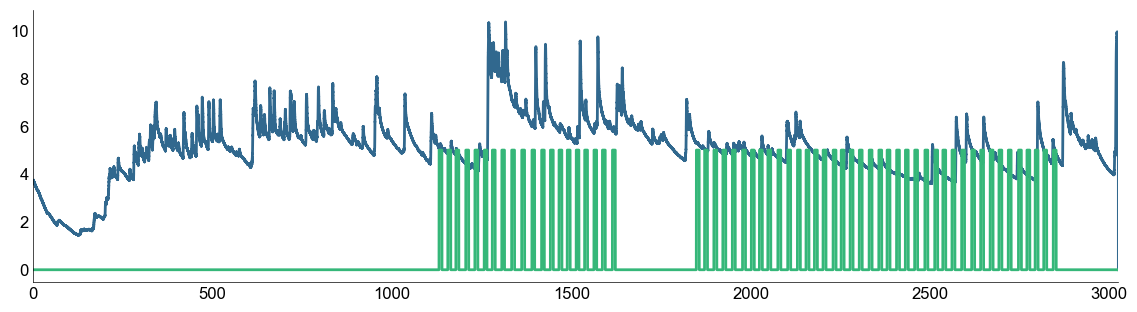

In [7]:
from lazyfmri import plotting
import numpy as np

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

In [567]:
# parse smi 
from calinet.imports.smi import smi_txt_to_df

ddict = smi_txt_to_df("Z:\\CALINET2\\sourcedata\\stockholm\\P_001(ND)\eyetracking_HabituationAcquisition_sub-CALINET001 Samples.txt")

ddict = smi_txt_to_df("Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET016\\eyetracking_HabituationAcquisition_sub-CALINET016 Samples.txt")


ddict.keys()

dict_keys(['eye1', 'eye2'])

In [568]:
ddict["eye1"]

,x_coordinate,y_coordinate,pupil_size
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
...,...,...,...
49655,0.0,0.0,0.0
49656,0.0,0.0,0.0
49657,0.0,0.0,0.0
49658,0.0,0.0,0.0


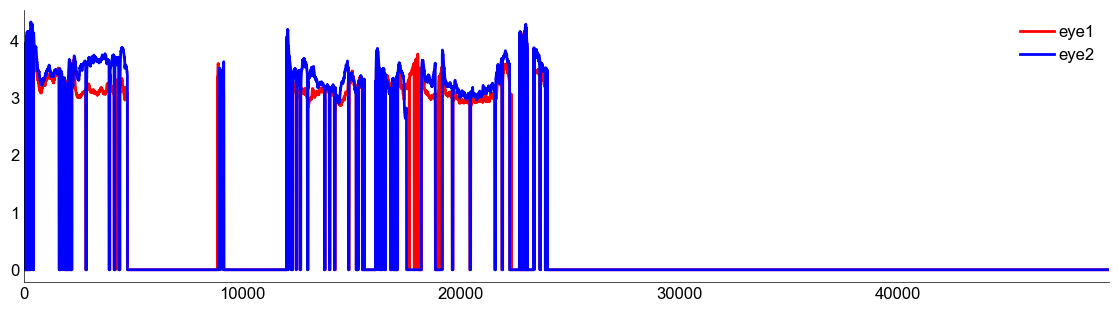

In [569]:
pl = plotting.LazyLine(
    [val["pupil_size"].to_numpy() for key, val in ddict.items()],
    # xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    color=["r", "b"],
    fontname="Arial",
    labels=list(ddict.keys()),
    figsize=(14, 3.54),
    label_size=12
)

In [490]:
from calinet.core.io import read_physio_tsv_headerless
# align eyetracking based on physio
phys_file = "Z:\\CALINET2\\converted\\stockholm\\sub-001\\physio\\sub-001_task-acquisition_recording-eye1_physioevents.tsv.gz"
phys_evs = read_physio_tsv_headerless(phys_file)
phys_evs

,0,1,2,3,4
0,0.048,0.216,fixation,0.0,NaN
1,0.268,0.020,saccade,0.0,NaN
2,0.312,0.128,fixation,0.0,NaN
3,0.444,0.012,saccade,0.0,NaN
4,0.460,0.700,fixation,0.0,NaN
...,...,...,...,...,...
1833,533.176,0.252,fixation,0.0,NaN
1834,533.432,0.012,saccade,0.0,NaN
1835,533.456,0.292,fixation,0.0,NaN
1836,533.752,0.016,saccade,0.0,NaN


In [496]:
bonn_phys = read_physio_tsv_headerless("Z:\\CALINET2\\converted\\bonn\\sub-001\\physio\\sub-001_task-acquisition_recording-eye2_physioevents.tsv.gz")
bonn_phys

,0,1,2,3,4
0,0.007,0.338,fixation,0.0,NaN
1,0.345,0.054,saccade,0.0,NaN
2,0.399,0.311,fixation,0.0,NaN
3,0.710,0.037,saccade,0.0,NaN
4,0.747,0.488,fixation,0.0,NaN
...,...,...,...,...,...
3217,643.595,0.324,fixation,0.0,NaN
3218,643.919,0.036,saccade,0.0,NaN
3219,643.955,0.193,fixation,0.0,NaN
3220,644.148,0.021,saccade,0.0,NaN


In [ ]:
sub16 = read_physio_tsv_headerless("Z:\\CALINET2\\converted\\stockholm\\sub-001\\physio\\sub-001_task-acquisition_recording-eye2_physioevents.tsv.gz")
bonn_phys

In [70]:
from calinet.imports.smi import smi_txt_to_df

txt_file = "Z:\\CALINET2\\sourcedata\\stockholm\\sub-CALINET016\\eyetracking_Extinction_sub-CALINET016 Samples.txt"

df_dict = smi_txt_to_df(txt_file, sr=250, return_full=True)
df = df_dict["eye1"]
df

,timestamp,x_coordinate,y_coordinate,pupil_size
0,0.000,1043.8069,565.7097,3.7195
1,0.004,1043.7437,564.8147,3.7250
2,0.008,1044.4521,565.0093,3.7327
3,0.012,1044.9154,564.8365,3.7368
4,0.016,1044.5654,565.1811,3.7432
...,...,...,...,...
260339,1041.036,936.7075,515.3113,3.3883
260340,1041.040,936.7686,514.4065,3.3930
260341,1041.044,937.7544,513.6890,3.3934
260342,1041.048,937.5137,513.3343,3.3929


In [71]:
from calinet.imports.smi import simple_smi_read
df_all, meta, text_for_table, enc, lines, header_line_index = simple_smi_read(txt_file)
df_all

,Time,Type,Trial,L Mapped Diameter [mm],R Mapped Diameter [mm],L POR X [px],L POR Y [px],R POR X [px],R POR Y [px],Aux1
0,16116757435,SMP,1,3.7195,3.5172,1043.8069,565.7097,1073.7307,544.6436,NaN
1,16116761429,SMP,1,3.7250,3.5182,1043.7437,564.8147,1073.3858,545.8956,NaN
2,16116765423,SMP,1,3.7327,3.5196,1044.4521,565.0093,1073.7814,546.0434,NaN
3,16116769417,SMP,1,3.7368,3.5246,1044.9154,564.8365,1073.4658,545.8763,NaN
4,16116773411,SMP,1,3.7432,3.5216,1044.5654,565.1811,1074.2013,545.5420,NaN
...,...,...,...,...,...,...,...,...,...,...
260339,17157720036,SMP,1,3.3883,3.2807,936.7075,515.3113,964.2624,547.4940,NaN
260340,17157724036,SMP,1,3.3930,3.2791,936.7686,514.4065,963.7519,547.1600,NaN
260341,17157728037,SMP,1,3.3934,3.2762,937.7544,513.6890,964.0750,547.9163,NaN
260342,17157732037,SMP,1,3.3929,3.2785,937.5137,513.3343,964.2474,547.9290,NaN


In [72]:
from calinet.imports.smi import _extract_msg_rows_from_decoded_lines
df_msg = _extract_msg_rows_from_decoded_lines(lines, header_line_index)
df_msg.head()

,Time,message
0,1.613925e+10,EXT started here at: {'CS_Start_time': 22.5164...
1,1.614727e+10,"EXT ended here: CS OFFSET 30.532899018919125, ..."
2,1.616225e+10,EXT started here at: {'CS_Start_time': 45.5165...
3,1.617025e+10,"EXT ended here: CS OFFSET 53.51643808768404, C..."
4,1.618825e+10,EXT started here at: {'CS_Start_time': 71.5169...


In [54]:
from calinet.imports.smi import fetch_msg_events_from_txt
df_msg = fetch_msg_events_from_txt(
    raw_file=txt_file,
    timestamps=df["timestamp"],
)

df_msg

[2026-03-11 12:49:20] [WARNING] calinet.imports.smi - No MSG rows found in raw file.


,onset,duration,trial_type,blink,message


In [52]:
from calinet.imports.smi import fetch_physioevents 
msgs, settings = fetch_physioevents(df=df, raw_file=txt_file)
msgs

[2026-03-11 12:48:24] [INFO] calinet.imports.smi - Detecting blinks | max_blink_gap_samples=2 | blink_threshold=0.15
[2026-03-11 12:48:24] [INFO] calinet.imports.smi - Calculating saccades/blinks from dataframe: vel_thresh_mm_s=80.0 | min. fixation (s)=0.06 | min. saccade (s)=0.01
[2026-03-11 12:48:24] [INFO] calinet.imports.smi - Loading MSGs from Z:\CALINET2\sourcedata\stockholm\sub-CALINET016\eyetracking_HabituationAcquisition_sub-CALINET016 Samples.txt
[2026-03-11 12:48:24] [WARNING] calinet.imports.smi - No MSG rows found in raw file.
[2026-03-11 12:48:24] [ERROR] calinet.imports.smi - No valid MSG events found; this means event-markers are not propagated to eye-tracking files. We cannot know when an event happened now!


,onset,duration,trial_type,blink,message
0,0.000,0.248,blink,1,n/a
1,0.252,0.07600000000000001,saccade,0,n/a
2,0.284,0.10400000000000004,blink,1,n/a
3,0.352,0.392,saccade,0,n/a
4,0.528,0.132,blink,1,n/a
...,...,...,...,...,...
418,95.216,0.036000000000001364,saccade,0,n/a
419,95.272,0.3119999999999976,saccade,0,n/a
420,95.592,0.055999999999997385,saccade,0,n/a
421,95.656,0.03999999999999204,saccade,0,n/a


In [505]:
from calinet.core.pupil import first_event_in_physioevents
print(first_event_in_physioevents(bonn_phys))
print(first_event_in_physioevents(phys_evs))

21.027
21.016430853189377


In [ ]:
arr = bonn_phys.iloc[:, -1].to_numpy()
idx = np.where([isinstance(x, str) and "CS" in x for x in arr])[0][0]
first_value = arr[idx]

print(idx)
print(first_value)

74
CS


In [501]:
float(bonn_phys.iloc[idx,0])

21.027

In [513]:
from calinet.data import run_pspm_trim_directory

window = [-10, 30]
_ = run_pspm_trim_directory(
    root_dir="Z:\\CALINET2\\converted\\stockholm\\sub-001\\physio",
    from_=window[0],
    to=window[1],
    reference="marker",
    event_time_col="onset",
    overwrite=False
)

[2026-03-10 16:31:31] [INFO] calinet.data - Scanning directory for physio files: Z:\CALINET2\converted\stockholm\sub-001\physio
[2026-03-10 16:31:31] [INFO] calinet.data - Found 10 physio file(s)
[2026-03-10 16:31:31] [INFO] calinet.data - Processing physio file: Z:\CALINET2\converted\stockholm\sub-001\physio\sub-001_task-acquisition_recording-eye1_physio.tsv.gz
[2026-03-10 16:31:31] [INFO] calinet.data - Starting PsPM-style trimming
[2026-03-10 16:31:31] [INFO] calinet.data - Timestamp column not found, generating using sampling rate [fs=250]
[2026-03-10 16:31:31] [INFO] calinet.data - Trimming parameters: from=-10, to=30, reference=marker
[2026-03-10 16:31:31] [INFO] calinet.data - StartTime=1099s, subtracting this from onset times to align channels
[2026-03-10 16:31:31] [WARNING] calinet.data - End time outside file bounds, clipping to file end
[2026-03-10 16:31:31] [INFO] calinet.data - Start=11.016s, end=534.04s
[2026-03-10 16:31:31] [INFO] calinet.data - Trimming complete
[2026-0

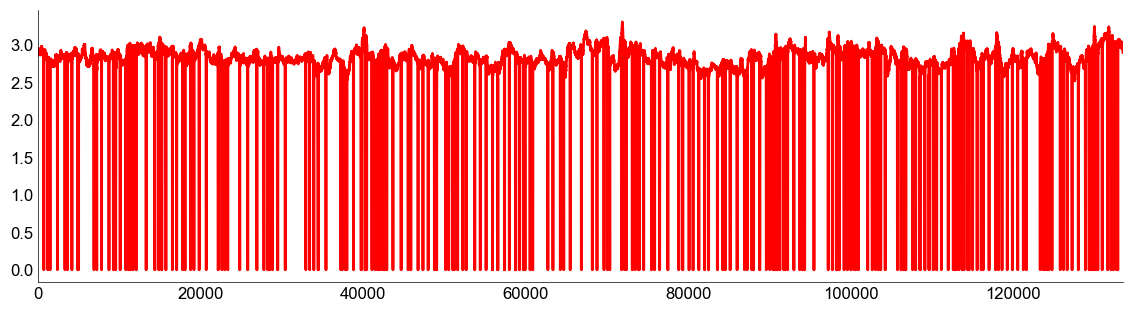

In [541]:
from calinet.core.io import read_physio_tsv_headerless
test = read_physio_tsv_headerless("Z:\\CALINET2\\converted\\stockholm\\sub-001\\physio\\sub-001_task-acquisition_recording-eye2_physio.tsv.gz")

pl = plotting.LazyLine(
    test.iloc[:, -1].to_numpy(),
    # xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    color="r",
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

[2026-03-10 19:19:12] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\stockholm\sub-001\physio\sub-001_task-acquisition_recording-eye1_physio.json
[2026-03-10 19:19:12] [INFO] calinet.plotting - SamplingFrequency=250
[2026-03-10 19:19:12] [INFO] calinet.plotting - Units for 'eye1'=mm
[2026-03-10 19:19:12] [INFO] calinet.plotting - Read 'eye1'/'acquisition' file: Z:\CALINET2\converted\stockholm\sub-001\physio\sub-001_task-acquisition_recording-eye1_physio.tsv.gz
[2026-03-10 19:19:12] [INFO] calinet.plotting - 'eye1' channel index: -1
[2026-03-10 19:19:12] [INFO] calinet.plotting - Add events
[2026-03-10 19:19:12] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\stockholm\sub-001\physio\sub-001_task-acquisition_recording-eye2_physio.json
[2026-03-10 19:19:12] [INFO] calinet.plotting - SamplingFrequency=250
[2026-03-10 19:19:12] [INFO] calinet.plotting - Units for 'eye2'=mm
[2026-03-10 19:19:12] [INFO] calinet.plotting - Read 'eye2'/'

Text(0.5, 0.98, 'sub-001')

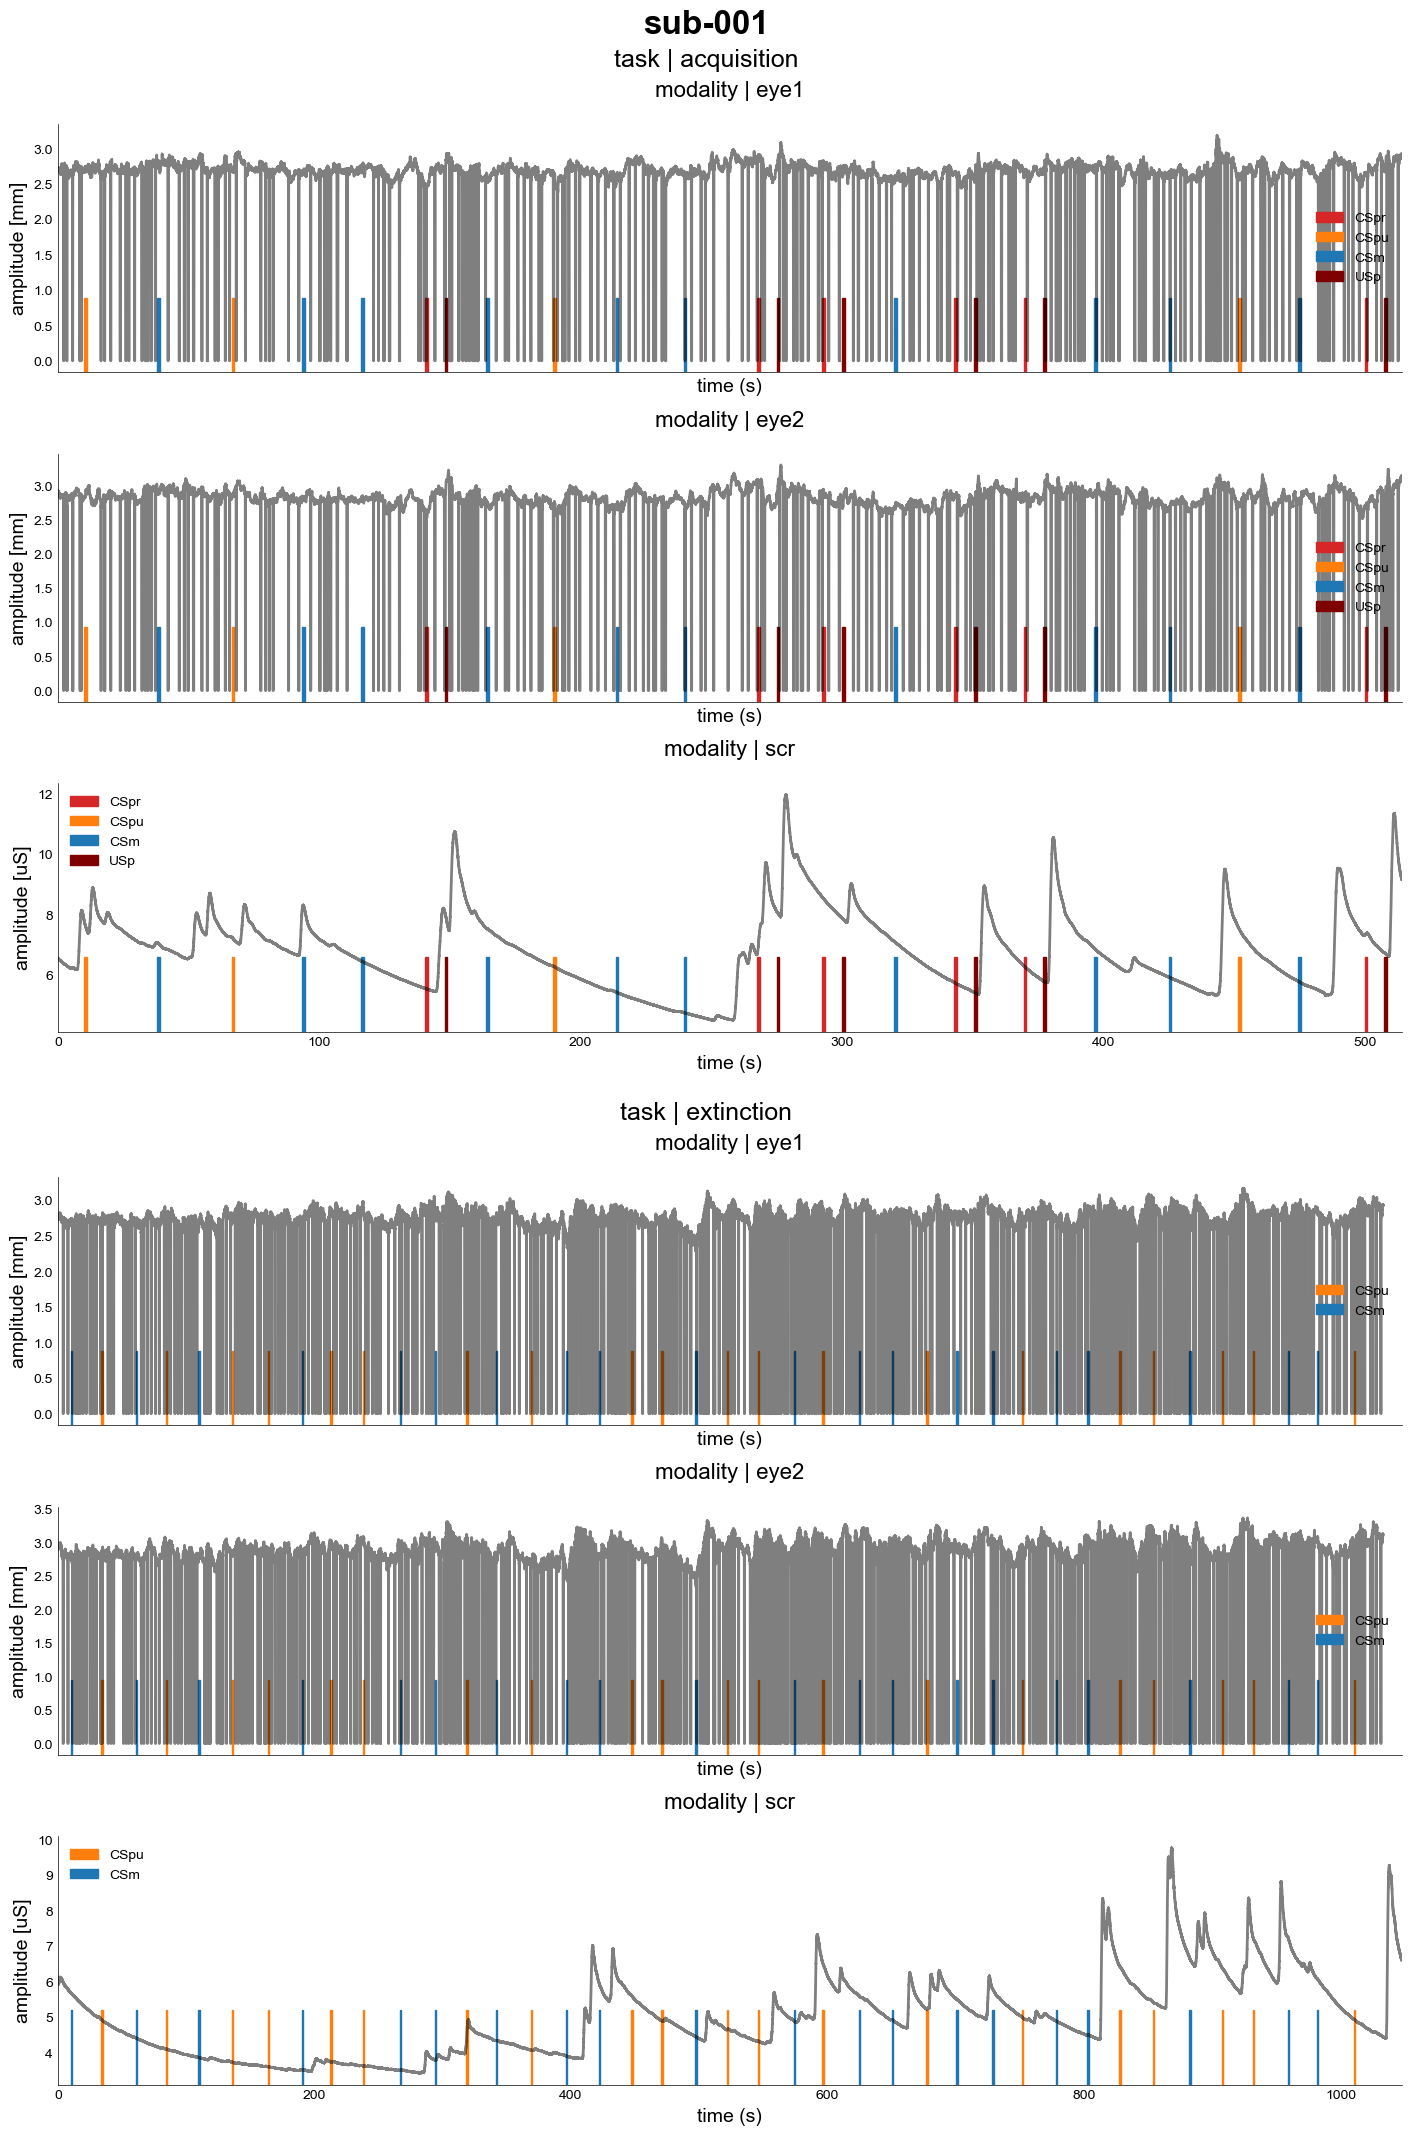

In [548]:
from calinet.utils import find_available_modalities
from pathlib import Path
lab_name = "stockholm"
subject = "sub-001"

root_path = Path("Z:\\CALINET2\\converted")
subj_path = root_path / lab_name / subject / "physio"
available_mods = find_available_modalities(subj_path)
task_names = ["acquisition", "extinction"]

figsize = (14, (len(task_names)*len(available_mods))*3.54)
fig = plt.figure(figsize=figsize, constrained_layout=True)
sfs = fig.subfigures(nrows=len(task_names))

for ix, (task, sf) in enumerate(zip(task_names, sfs)):

    axs = sf.subplots(nrows=len(available_mods), sharex=True)
    axs = np.atleast_1d(axs)
    for ax, mod in zip(axs, available_mods):
        ax = plot_physio_with_events(
            lab_name,
            subject,
            task,
            mod,
            ax=ax,
            line_width=2,
            color="k",
            x_label="time (s)",
            plot_alpha=0.5,
            stim_types=("CSpr", "CSpu", "CSm", "USp"),
            title=f"modality | {mod}"
        )


    sf.suptitle(f"task | {task}", fontsize=18)
fig.suptitle(subject, fontsize=24, fontweight="bold")


### Issue with events [sub-036]

In [9]:
from calinet.core.events import handle_events
from calinet.sites.stockholm import read_raw_physio_file
from calinet.core.physio import split_df_into_sessions

txt_file = r'Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\CALINET_036_A3.acq'
df, sr, chan_info = read_raw_physio_file(txt_file)

onsets_dict, phys_dict = split_df_into_sessions(
    physio_df=df,
    sr=sr
)

[2026-03-18 16:14:42.704] [-] [INFO] calinet.sites.stockholm - Reading .acq file: Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\CALINET_036_A3.acq
[2026-03-18 16:14:43.666] [-] [INFO] calinet.sites.stockholm - Loading acq-file successfull
[2026-03-18 16:14:43.670] [-] [INFO] calinet.core.events - Extracting marker data [sr=2000.0]
[2026-03-18 16:14:44.689] [-] [INFO] calinet.core.events - typical_ioi≈25.015s | min_rise_interval_sec=12.508s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-18 16:14:44.690] [-] [INFO] calinet.core.events - Largest gap between markers: 229.285s (between markers 19 and 20)
[2026-03-18 16:14:44.693] [-] [INFO] calinet.core.events - Long gap threshold=125.077s (25.015*5.0)
[2026-03-18 16:14:44.695] [-] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-18 16:14:44.697] [-] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-18 16:14:44.698] [-] [INFO] calinet.core.events - Marker data successfully extracte

In [10]:
task_ratings, task_onsets = handle_events(
    raw_path=os.path.dirname(txt_file),
    events_dict=onsets_dict,
    write_files=False
)

[2026-03-18 16:14:47.925] [-] [INFO] calinet.core.events - Processing events data
[2026-03-18 16:14:47.927] [-] [INFO] calinet.core.events - Parsing events for task='acquisition'
[2026-03-18 16:14:47.932] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-18 16:14:47.935] [-] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\sub-CALINET036_ses-1_task-acquisition_2024-10-10_15h55.29.623.csv
[2026-03-18 16:14:47.986] [-] [INFO] calinet.core.events - Adding 6 US trials to events
[2026-03-18 16:14:48.008] [-] [INFO] calinet.core.events - Parsing events for task='extinction'
[2026-03-18 16:14:48.011] [-] [INFO] calinet.core.events - Found 4 matching CSV file(s)
[2026-03-18 16:14:48.013] [-] [INFO] calinet.core.events - Selected largest CSV file of 0.03 MB
[2026-03-18 16:14:48.015] [-] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\sub-CALINET036_ses-1_task-extinction_2024-10-

ParserError: Error tokenizing data. C error: Expected 114 fields in line 52, saw 115


In [15]:
csv_file = r'Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\sub-CALINET036_ses-1_task-extinction_2024-10-10_16h10.05.509.csv'

df = pd.read_csv(
    csv_file,
    engine="python",     # <-- key fix
    # sep=",",
    # quotechar='"'
)

df

ParserError: ',' expected after '"'

In [19]:
import pandas as pd
from io import StringIO
import csv

corrupt_file = r'Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\sub-CALINET036_ses-1_task-ExtCORRUPT_2024-10-10_16h10.05.509.csv'

csv_file = r'Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\sub-CALINET036_ses-1_task-extinction_2024-10-10_16h10.05.509.csv'

with open(corrupt_file, 'r', encoding='utf-8', errors='replace') as f:
    raw = f.read()

fixed = raw.replace('select "none" ', 'select ""none"" ')
fixed = fixed.replace('was "straight" gave', 'was ""straight"" gave')

df = pd.read_csv(StringIO(fixed), engine='python')
df.to_csv(
    csv_file,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,   # safe default
    quotechar='"',
    doublequote=True             # ensures inner quotes become ""
)

In [20]:
# now retry
task_ratings, task_onsets = handle_events(
    raw_path=os.path.dirname(txt_file),
    events_dict=onsets_dict,
    write_files=False
)

[2026-03-18 16:25:27.333] [-] [INFO] calinet.core.events - Processing events data
[2026-03-18 16:25:27.335] [-] [INFO] calinet.core.events - Parsing events for task='acquisition'
[2026-03-18 16:25:27.339] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-18 16:25:27.340] [-] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\sub-CALINET036_ses-1_task-acquisition_2024-10-10_15h55.29.623.csv
[2026-03-18 16:25:27.372] [-] [INFO] calinet.core.events - Adding 6 US trials to events
[2026-03-18 16:25:27.388] [-] [INFO] calinet.core.events - Parsing events for task='extinction'
[2026-03-18 16:25:27.388] [-] [INFO] calinet.core.events - Found 4 matching CSV file(s)
[2026-03-18 16:25:27.388] [-] [INFO] calinet.core.events - Selected largest CSV file of 0.03 MB
[2026-03-18 16:25:27.388] [-] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\stockholm\sub-CALINET036\sub-CALINET036_ses-1_task-extinction_2024-10-

In [21]:
task_onsets

{'acquisition':         onset  duration event_type stimulus_name  \
 0    958.8410  8.000000        CSm       diamond   
 1    966.3410  0.000000        USm       diamond   
 2    987.3250  8.000000       CSpu        square   
 3    994.8250  0.000000        USo        square   
 4   1014.8410  8.000000       CSpu        square   
 5   1022.3410  0.000000        USo        square   
 6   1038.8410  8.000000        CSm       diamond   
 7   1046.3410  0.000000        USm       diamond   
 8   1063.3410  8.000000       CSpr        square   
 9   1070.8410  0.445141        USp         shock   
 10  1085.8410  8.000000       CSpr        square   
 11  1093.3410  0.425483        USp         shock   
 12  1112.3410  8.000000        CSm       diamond   
 13  1119.8410  0.000000        USm       diamond   
 14  1139.3410  8.000000       CSpr        square   
 15  1146.8410  0.425490        USp         shock   
 16  1162.3410  8.000000        CSm       diamond   
 17  1169.8410  0.000000       

## Wuerzburg tests

### Pheno

In [109]:
from calinet.sites.wuerzburg import parse_questionnaire_file, find_questionnaire_file

questionnaire_file = find_questionnaire_file(r'Z:\CALINET2\sourcedata\wuerzburg')

info_df, pheno_df = parse_questionnaire_file(questionnaire_file)

In [110]:
pheno_df.head()

,participant_id,recorded_at,room_temperature,humidity,age,sex,handedness,questionnaires_language,ius,stai_t,...,bfi_21,bfi_22,bfi_23,bfi_24,bfi_25,bfi_26,bfi_27,bfi_28,bfi_29,bfi_30
0,sub-001,2024-04-29 11:36:05,21.4,49,23,F,left,german,55,36,...,2,5,4,2,5,5,3,4,4,5
1,sub-002,2024-05-06 07:49:24,22.1,55,41,F,right,german,37,28,...,5,5,5,1,2,3,3,5,2,3
2,sub-003,2024-05-06 09:29:31,23.9,54,21,F,right,german,63,51,...,1,5,4,4,4,2,4,2,4,4
3,sub-004,2024-05-06 10:56:26,24.2,53,20,F,right,german,75,62,...,5,4,3,5,2,3,2,1,2,5
4,sub-005,2024-05-13 07:44:32,22.1,51,23,F,right,german,34,39,...,2,5,4,1,5,5,4,5,2,4


### Physio (headerless txt-file)

In [585]:
from calinet.config import available_labs
biopac_txt = "Z:\\CALINET2\\sourcedata\\wuerzburg\\sub-Wue_001\\001.txt"
res = biopac.read_biopac_txt_noheader(
    biopac_txt,
    sampling_rate_hz=1000,
    column_names=["SCR", "RESP", "ECG", "TTL"]
)

In [586]:
res.df

,SCR,RESP,ECG,TTL
0,0.004577,0.003357,0.536194,0
1,0.003051,0.004578,0.537109,0
2,0.004577,0.005798,0.536804,0
3,0.006103,0.006256,0.536499,0
4,0.007629,0.006714,0.537415,0
...,...,...,...,...
2696481,11.213700,-0.082397,0.440063,0
2696482,11.212200,-0.083771,0.439758,0
2696483,11.216700,-0.085449,0.440369,0
2696484,11.215200,-0.087585,0.440674,0


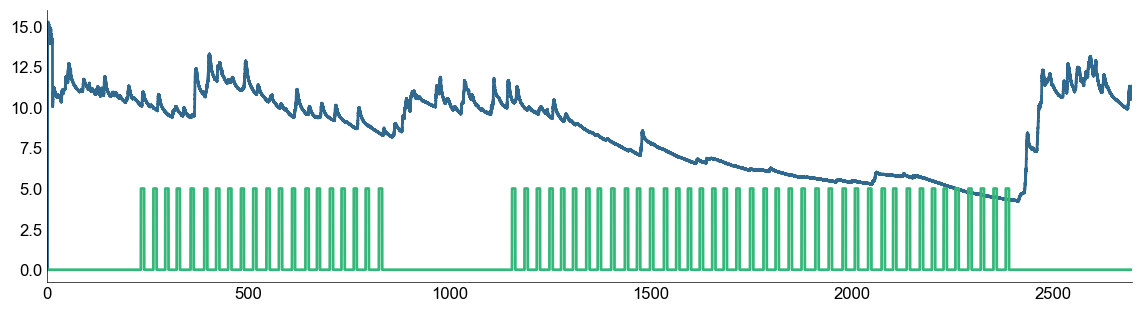

In [587]:
from lazyfmri import plotting

pl = plotting.LazyLine(
    [res.df[i].to_numpy() for i in ["SCR", "TTL"]],
    xx=np.arange(0, res.df.shape[0])/res.sampling_rate_hz,
    line_width=2,
    # color=["r"],
    fontname="Arial",
    figsize=(14, 3.54),
    label_size=12
)

In [588]:
from calinet.core.events import extract_onsets_from_ttl
out = extract_onsets_from_ttl(
    res.df,
    res.sampling_rate_hz
)

[2026-03-10 21:23:15] [INFO] calinet.core.events - Extracting marker data [sr=1000.0]
[2026-03-10 21:23:19] [INFO] calinet.core.events - typical_ioi≈30.998s | min_rise_interval_sec=15.499s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-10 21:23:19] [INFO] calinet.core.events - Largest gap between markers: 330.862s (between markers 19 and 20)
[2026-03-10 21:23:19] [INFO] calinet.core.events - Long gap threshold=154.99s
[2026-03-10 21:23:19] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-10 21:23:19] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40], dropping: []
[2026-03-10 21:23:19] [INFO] calinet.core.events - Marker data successfully extracted


### Issue with events [sub-036]

In [7]:
from calinet.core.events import handle_events
from calinet.sites.wuerzburg import read_raw_physio_file
from calinet.core.physio import split_df_into_sessions

txt_file = r'Z:\CALINET2\sourcedata\wuerzburg\sub-Wue_036\036.txt'
df, sr, chan_info = read_raw_physio_file(txt_file)

onsets_dict, phys_dict = split_df_into_sessions(
    physio_df=df,
    sr=sr
)

[2026-03-18 16:12:23.001] [-] [INFO] calinet.sites.wuerzburg - Reading .acq file: Z:\CALINET2\sourcedata\wuerzburg\sub-Wue_036\036.txt
[2026-03-18 16:12:23.003] [-] [INFO] calinet.sites.wuerzburg - Reading SamplingFrequency from wuerzburg's metadata: 1000
[2026-03-18 16:12:24.350] [-] [INFO] calinet.sites.wuerzburg - Loading acq-file successfull
[2026-03-18 16:12:24.356] [-] [INFO] calinet.core.events - Extracting marker data [sr=1000.0]
[2026-03-18 16:12:27.813] [-] [INFO] calinet.core.events - typical_ioi≈31.503s | min_rise_interval_sec=15.752s | min_gap_sec=30.0 | min_cluster_size=20
[2026-03-18 16:12:27.813] [-] [INFO] calinet.core.events - Largest gap between markers: 351.396s (between markers 19 and 20)
[2026-03-18 16:12:27.813] [-] [INFO] calinet.core.events - Long gap threshold=157.515s (31.503*5.0)
[2026-03-18 16:12:27.813] [-] [INFO] calinet.core.events - 60 markers found (20+40).
[2026-03-18 16:12:27.813] [-] [INFO] calinet.core.events - Keeping clusters with sizes: [20, 40]

In [8]:
task_ratings, task_onsets = handle_events(
    raw_path=os.path.dirname(txt_file),
    events_dict=onsets_dict,
    write_files=False
)

[2026-03-18 16:12:31.452] [-] [INFO] calinet.core.events - Processing events data
[2026-03-18 16:12:31.456] [-] [INFO] calinet.core.events - Parsing events for task='acquisition'
[2026-03-18 16:12:31.458] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-18 16:12:31.464] [-] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\wuerzburg\sub-Wue_036\sub-Wue_036_ses-1_task-acquisition_2024-07-29_14h06.39.398.csv
[2026-03-18 16:12:31.522] [-] [INFO] calinet.core.events - Adding 6 US trials to events
[2026-03-18 16:12:31.536] [-] [INFO] calinet.core.events - Parsing events for task='extinction'
[2026-03-18 16:12:31.536] [-] [INFO] calinet.core.events - Found 1 matching CSV file(s)
[2026-03-18 16:12:31.536] [-] [INFO] calinet.core.events - Reading events from Z:\CALINET2\sourcedata\wuerzburg\sub-Wue_036\sub-Wue_036_ses-1_task-extinction_2024-07-29_14h25.22.871.csv


## Check integrity participants_info.tsv

In [94]:
import numpy as np
import pandas as pd
from lazyfmri import utils

In [155]:
from pathlib import Path

raw_path = Path(r'Z:\CALINET2\converted')
labs = os.listdir(raw_path)

dfs = []

for lab in labs:
    pheno_file = raw_path / lab / "phenotype" / "participant_info.tsv"
    df = pd.read_csv(
        pheno_file,
        delimiter="\t",
        na_values=["n/a"]
    )

    df["site"] = lab

    dfs.append(df)

df_sample = pd.concat(dfs)
df_sample.head()

,participant_id,recorded_at,room_temperature,humidity,age,sex,handedness,site
0,sub-CalinetAustin01,2025-03-20T12:09:21,NaN,NaN,26.0,F,NaN,austin
1,sub-CalinetAustin02,2025-03-25T15:40:55,NaN,NaN,19.0,M,NaN,austin
2,sub-CalinetAustin03,2025-09-23T16:21:14,NaN,NaN,18.0,F,NaN,austin
3,sub-CalinetAustin04,2025-06-26T12:58:14,NaN,NaN,18.0,F,NaN,austin
4,sub-CalinetAustin05,2025-06-13T12:07:45,NaN,NaN,19.0,F,NaN,austin


In [156]:
from pupilfear.helper_functions import manuscript_demographics_summary
manuscript_demographics_summary(
    df_sample
)

{'dataset': None,
 'N_total': 389,
 'N_age': 384,
 'age_mean': 24.916666666666668,
 'age_sd': 6.624847076087808,
 'age_mean_sd_str': '24.9 ± 6.6',
 'N_sex': 374,
 'N_female': 219,
 'N_male': 155,
 'N_other_unknown': 0,
 'N_FM_str': '389 (219/155)',
 'table_row_str': '389 (219/155)\t24.9 ± 6.6',
 'narrative_str': 'N=389 (F/M=219/155), age 24.9 ± 6.6 years.'}

In [116]:
from calinet.core.metadata import available_labs, get_modalities

for lab in labs:
    mods = get_modalities(available_labs.get(lab))
    print(f"{lab}: {mods}")


austin: ['SCR']
bielefeld: ['SCR']
bologna: ['ECG', 'SCR']
bonn: ['ECG', 'RESP', 'SCR', 'eyetracking']
leuven: ['ECG', 'SCR']
london: ['PPG', 'RESP', 'SCR']
newyork: ['SCR']
reading: ['SCR']
southampton: ['SCR']
stockholm: ['SCR', 'eyetracking']
wuerzburg: ['ECG', 'RESP', 'SCR', 'eyetracking']


In [149]:
dfs = []
for file in part_files:
    df = pd.read_csv(
        file,
        delimiter="\t",
        na_values=["n/a"]
    )

    dfs.append(df)


In [151]:
from calinet.core.pheno import common_write_tsv
df_full = pd.concat(dfs)

df_ = common_write_tsv(
    df_full,
    id_key="sample",
    language="",
    phenotype_dir=r'Z:\CALINET2\code\calinet-main\calinet\misc'
)

[2026-03-19 14:37:13.942] [-] [INFO] calinet.core.pheno - Aggregated SAMPLE data saved to: Z:\CALINET2\code\calinet-main\calinet\misc\sample.tsv
